## Stress test model to find best performing regions

In [1]:
import torch
import torch.nn as nn
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import sys
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc)
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import copy

In [2]:
# --- 1. SETUP ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [3]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [4]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:207: FutureWarning: `to

In [5]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [6]:
# --- 2. CONFIGURATION (EDIT THIS) ---
class NotebookArgs:
    # PATHS
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    # CONFIGS
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml" 
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    # WEIGHTS
    checkpoint_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/vicreg/best_vicreg_msgmona.pkl"       # The Encoder Weights
    binary_model_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/alignuniform/best_focal_model_msgmona.pth" # The Full Model Weights (MLP+Physics)
    
    # OUTPUT
    output_dir = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
    
    # SETTINGS
    batch_size = 32
    gpu_id = 0

args = NotebookArgs()
os.makedirs(args.output_dir, exist_ok=True)
device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")

In [7]:
# --- 3. HELPER FUNCTIONS ---

def get_mass_regime(diff):
    if pd.isna(diff): return "Unknown"
    if diff < 0.01: return "0. Exact Isomers (<0.01 Da)"
    elif diff < 1.0: return "1. Isobaric (<1 Da)"
    elif diff < 10.0: return "2. Tiny (1-10 Da)"
    elif diff < 50.0: return "3. Medium (10-50 Da)"
    elif diff < 100.0: return "4. Large (50-100 Da)"
    else: return "5. Huge (>100 Da)"

In [8]:
def calculate_advanced_metrics(df_sub):
    """
    Calculates robust metrics, handling cases with only 1 class.
    """
    y_true = df_sub['label'].values
    y_prob = df_sub['prob'].values
    y_pred = df_sub['pred'].values
    
    # Basic
    metrics = {
        'Count': len(df_sub),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    # Advanced (Requires both classes to exist)
    if len(np.unique(y_true)) > 1:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_prob)
        metrics['PR-AUC'] = average_precision_score(y_true, y_prob)
    else:
        metrics['ROC-AUC'] = np.nan # Undefined if only 1 class exists
        metrics['PR-AUC'] = np.nan
        
    return pd.Series(metrics)

In [9]:
def load_and_enrich_data(pairs_path, spec_meta_df):
    """
    Loads pairs, cleans metadata, merges to get precursor masses, 
    and calculates mass difference.
    ROBUST FIX: Handles duplicate columns and indices in spec_meta_df.
    """
    print(f"Loading pairs from: {pairs_path}")
    df_pairs = pd.read_feather(pairs_path)
    
    # --- 1. CLEAN METADATA ---
    # Create a clean copy to avoid modifying the original
    meta_clean = spec_meta_df.copy()
    
    # Ensure spec_id is a column
    if 'spec_id' not in meta_clean.columns:
        # Check if it's in the index
        if meta_clean.index.name == 'spec_id':
            meta_clean = meta_clean.reset_index()
        else:
            # Fallback: Create a column from the index assuming it is spec_id
            meta_clean['spec_id'] = meta_clean.index

    # Identify Mass Column
    mz_col = 'precursor_mz' if 'precursor_mz' in meta_clean.columns else 'prec_mz'
    print(f"Using metadata column: '{mz_col}'")
    
    # CRITICAL FIX: Select only needed columns and drop duplicates
    # This prevents the "DataFrame vs Series" error
    try:
        meta_lookup = meta_clean[['spec_id', mz_col]].copy()
        
        # Remove duplicate columns (if any exist with same name)
        meta_lookup = meta_lookup.loc[:, ~meta_lookup.columns.duplicated()]
        
        # Remove duplicate rows (keep first occurrence of each spec_id)
        meta_lookup = meta_lookup.drop_duplicates(subset=['spec_id'])
        
    except KeyError:
        raise ValueError(f"Column '{mz_col}' not found in metadata. Available: {list(meta_clean.columns)}")

    # --- 2. MERGE MOLECULE A ---
    print("Merging metadata for Molecule A...")
    df_enriched = df_pairs.merge(
        meta_lookup, 
        left_on='name_main', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={mz_col: 'prec_mz_main'}).drop(columns=['spec_id'])
    
    # --- 3. MERGE MOLECULE B ---
    print("Merging metadata for Molecule B...")
    df_enriched = df_enriched.merge(
        meta_lookup, 
        left_on='name_sub', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={mz_col: 'prec_mz_sub'}).drop(columns=['spec_id'])

    print(df_enriched.head())
    
    # --- 4. CALCULATE MASS DIFF ---
    # Now guaranteed to be Series subtraction
    df_enriched['mass_difference'] = (df_enriched['prec_mz_main'] - df_enriched['prec_mz_sub']).abs()
    
    # Handle NaN values (fill with 0 or drop, depending on preference)
    # Here we just warn
    missing = df_enriched['mass_difference'].isna().sum()
    if missing > 0:
        print(f"WARNING: {missing} records have missing mass info (NaN).")
        
    return df_enriched

In [10]:
# --- 4. MAIN EXECUTION ---
def run_evaluation_in_notebook(args):
    print(f"--- STARTING ADVANCED EVALUATION ---")
    
    # A. LOAD DATA
    spec_df_raw = pd.read_pickle(args.spec_data_path)
    spec_df = spec_df_raw.set_index('spec_id')
    mol_df = pd.read_pickle(args.mol_data_path).set_index('mol_id')
    
    # Pre-calculate Mass Diffs
    df_meta = load_and_enrich_data(args.test_pairs_path, spec_df_raw)
    
    # Load Torch Dataset
    test_dataset = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    if len(test_dataset) != len(df_meta): df_meta = df_meta.iloc[:len(test_dataset)]

    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=4)
    
    # B. INITIALIZE MODEL
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)
    
    spec_meta_dim = test_dataset[0][2].shape[1]
    
    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    print(f"Loading Full Weights: {os.path.basename(args.binary_model_path)}")
    state_dict = torch.load(args.binary_model_path, map_location=device)
    if 'best_model_sd' in state_dict: state_dict = state_dict['best_model_sd']
    elif 'state_dict' in state_dict: state_dict = state_dict['state_dict']
    model.load_state_dict(state_dict)
    model.eval()

    # C. INFERENCE
    print("Running Inference...")
    results = []
    
    with torch.no_grad():
        for batch_idx, (batch_A, batch_B, batch_meta, mass_diffs_tensor, labels) in enumerate(tqdm(test_loader)):
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            for k in batch_B: batch_B[k] = batch_B[k].to(device)
            batch_meta = batch_meta.to(device)
            mass_diffs_tensor = mass_diffs_tensor.to(device)
            
            logits = model(batch_A, batch_B, batch_meta, mass_diffs_tensor).view(-1)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(float)
            labels = labels.numpy()
            
            start_idx = batch_idx * args.batch_size
            for i in range(len(probs)):
                global_idx = start_idx + i
                if global_idx >= len(df_meta): break
                
                row = df_meta.iloc[global_idx]
                mass_diff = row['mass_difference']
                
                results.append({
                    'prob': probs[i],
                    'pred': preds[i],
                    'label': labels[i],
                    'mass_diff': mass_diff
                })

    df_res = pd.DataFrame(results)
    
    # D. ADVANCED METRICS & PLOTTING
    print("\n" + "="*40)
    print("      MASS REGIME METRICS      ")
    print("="*40)

    # 1. METRICS TABLE
    df_res['mass_regime'] = df_res['mass_diff'].apply(get_mass_regime)
    mass_stats = df_res.groupby('mass_regime', observed=False).apply(calculate_advanced_metrics)
    print("\n[1] Metrics by Mass Difference:")
    print(mass_stats[['Count', 'ROC-AUC', 'PR-AUC', 'Accuracy']])

    # 2. PLOTTING ROC AND PR CURVES
    plt.figure(figsize=(20, 8)) # Wider figure for side-by-side plots

    # --- PLOT A: ROC CURVES ---
    plt.subplot(1, 2, 1)
    for regime in sorted(df_res['mass_regime'].unique()):
        subset = df_res[df_res['mass_regime'] == regime]
        if len(subset['label'].unique()) > 1:
            fpr, tpr, _ = roc_curve(subset['label'], subset['prob'])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{regime} (AUC = {roc_auc:.2f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves by Mass Regime')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # --- PLOT B: PRECISION-RECALL CURVES (NEW!) ---
    plt.subplot(1, 2, 2)
    for regime in sorted(df_res['mass_regime'].unique()):
        subset = df_res[df_res['mass_regime'] == regime]
        if len(subset['label'].unique()) > 1:
            precision, recall, _ = precision_recall_curve(subset['label'], subset['prob'])
            pr_auc = average_precision_score(subset['label'], subset['prob'])
            
            # Baseline (Random Guessing) is P / (P + N)
            baseline = subset['label'].mean()
            
            plt.plot(recall, precision, label=f'{regime} (AP = {pr_auc:.2f})', linewidth=2)
    
    # Plot baseline for total dataset average
    total_baseline = df_res['label'].mean()
    plt.axhline(y=total_baseline, color='k', linestyle='--', label=f'Random ({total_baseline:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves by Mass Regime')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    

    # Save
    save_path = os.path.join(args.output_dir, "mass_regime_metrics.csv")
    df_res.to_csv(save_path, index=False)
    print(f"Results saved to {save_path}")

--- STARTING ADVANCED EVALUATION ---
Loading pairs from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather
Using metadata column: 'prec_mz'
Merging metadata for Molecule A...
Merging metadata for Molecule B...
              name_main              name_sub  tanimoto  cosine_similarity  \
0  MassSpecGymID0003031  MassSpecGymID0049401  0.432432           0.706041   
1  MassSpecGymID0223776  MassSpecGymID0237961  0.175676           0.648690   
2  MassSpecGymID0224062  MassSpecGymID0234208  0.089109           0.122628   
3  MassSpecGymID0003081  MassSpecGymID0060725  0.439024           0.773729   
4  MassSpecGymID0148794  MassSpecGymID0159098  0.403846           0.449861   

   label  prec_mz_main  prec_mz_sub  
0    1.0     495.26590    411.17200  
1    0.0     534.08809    280.14444  
2    0.0     412.21185    483.20134  
3    1.0     363.17200    293.09370  
4    0.0     245.11720    259.09650  
Loading binary pairs from /data/n

/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Loading Full Weights: best_focal_model_msgmona.pth


/tmp/ipykernel_526072/1318097729.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.binary_model_path, map_location=device)


Running Inference...


100%|██████████| 152/152 [00:11<00:00, 13.14it/s]



      MASS REGIME METRICS      

[1] Metrics by Mass Difference:
                              Count   ROC-AUC    PR-AUC  Accuracy
mass_regime                                                      
0. Exact Isomers (<0.01 Da)   567.0  0.647534  0.946925  0.890653
1. Isobaric (<1 Da)            36.0  0.635417  0.619623  0.472222
2. Tiny (1-10 Da)             353.0  0.785857  0.746442  0.739377
3. Medium (10-50 Da)         1757.0  0.829997  0.834548  0.783153
4. Large (50-100 Da)         1026.0  0.840801  0.764178  0.765107
5. Huge (>100 Da)            1119.0  0.803652  0.596311  0.798034


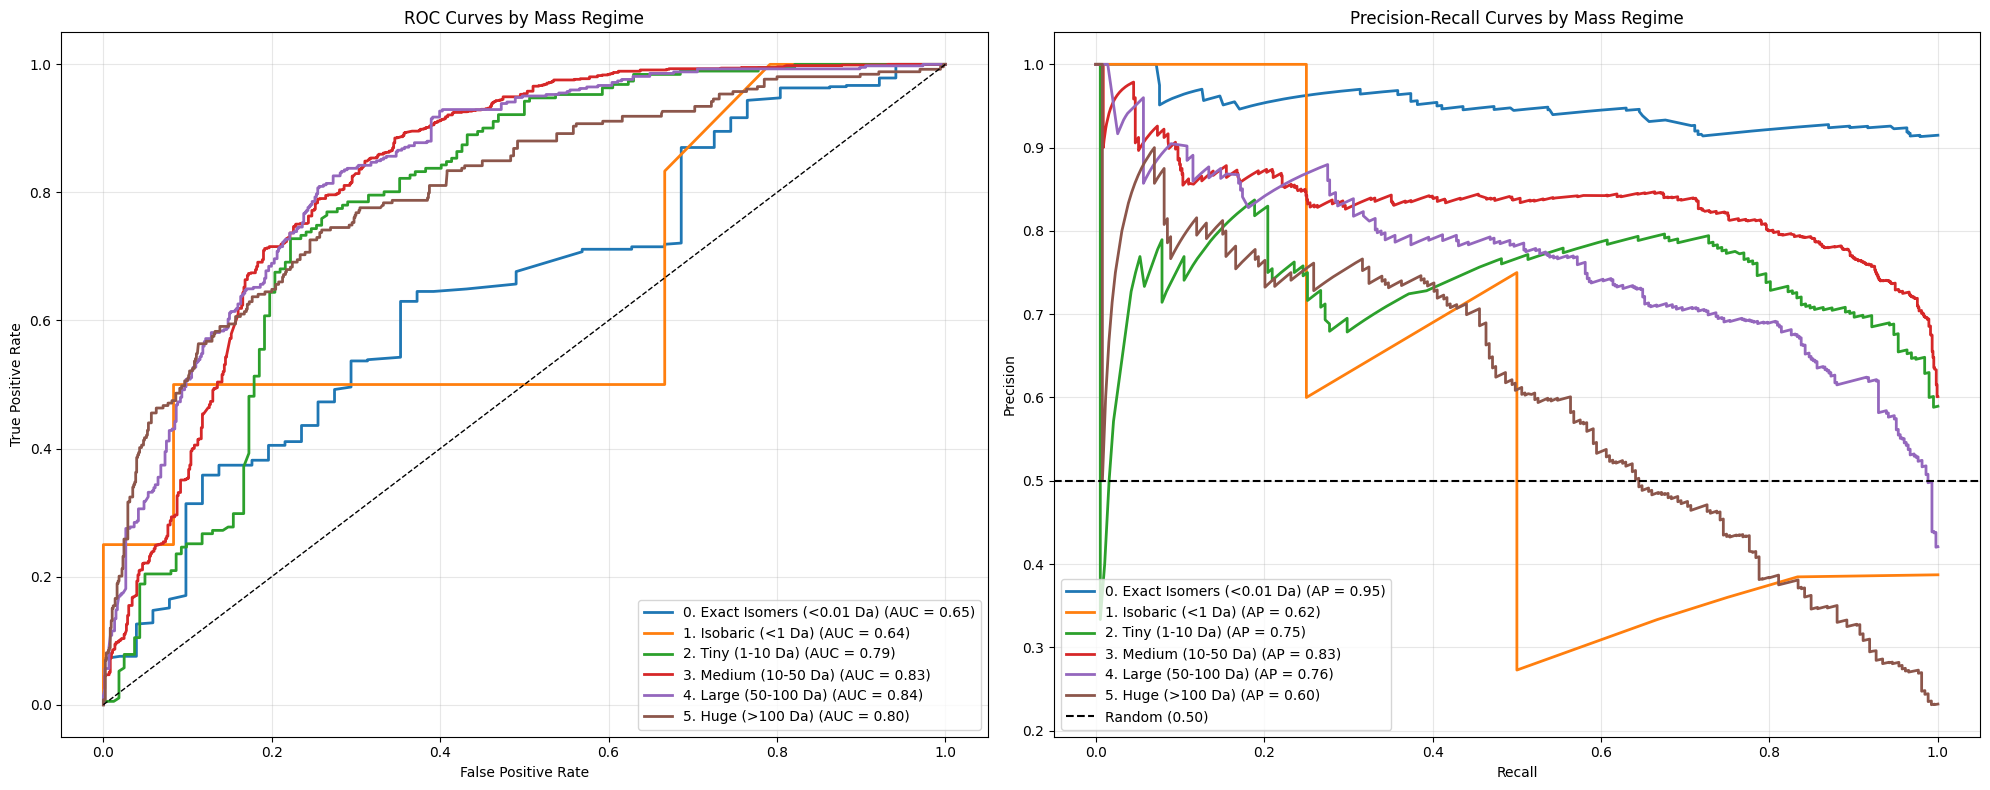

Results saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/mass_regime_metrics.csv


In [11]:
# --- 5. RUN IT ---
run_evaluation_in_notebook(args)

## Stress test model performance across cosine similarity

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [13]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv"
TEST_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [14]:
def analyze_similarity_spectrum():
    print("--- PERFORMANCE VS. SPECTRAL SIMILARITY ---")
    
    # 1. Load Results directly (No external metadata needed!)
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find file at {RESULTS_PATH}")
        return

    print(f"Loading results from {RESULTS_PATH}...")
    df_analysis = pd.read_csv(RESULTS_PATH)
    
    # 2. Binning the Ground Truth Similarity
    # We use the 'cosine_similarity' column from your CSV
    # Bins: 0.0-0.1, 0.1-0.2, ... 0.9-1.0
    bins = np.linspace(0, 1.0, 11)
    labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)]
    
    df_analysis['sim_bin'] = pd.cut(
        df_analysis['cosine_similarity'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )
    
    # 3. Calculate Metrics per Bin
    print("Calculating metrics per bin...")
    
    # Helper to calculate metrics safely (handling empty bins)
    def calc_metrics(x):
        if len(x) == 0:
            return pd.Series({'Count': 0, 'Accuracy': np.nan, 'Avg_Conf': np.nan, 'Pos_Rate': 0})
            
        return pd.Series({
            'Count': len(x),
            'Accuracy': accuracy_score(x['true_label'], x['predicted_label']),
            'Precision': precision_score(x['true_label'], x['predicted_label'], zero_division=0),
            'Recall': recall_score(x['true_label'], x['predicted_label'], zero_division=0),
            'Avg_Conf': x['prob_similarity'].mean(),
            'Pos_Rate': x['true_label'].mean() # How many are actually Positive in this bin?
        })

    spectrum_stats = df_analysis.groupby('sim_bin', observed=False).apply(calc_metrics)
    
    print("\nSpectrum Performance Table:")
    print(spectrum_stats[['Count', 'Accuracy', 'Precision', 'Recall', 'Pos_Rate']])
    
    # 4. VISUALIZATION
    plt.figure(figsize=(14, 7))
    
    # Plot 1: Accuracy Line (Primary Axis)
    ax1 = plt.gca()
    sns.lineplot(data=spectrum_stats, x=spectrum_stats.index, y='Accuracy', 
                 marker='o', color='tab:blue', linewidth=3, label='Model Accuracy', ax=ax1)
    
    # Plot 2: Sample Count Bar (Secondary Axis)
    ax2 = ax1.twinx()
    sns.barplot(data=spectrum_stats, x=spectrum_stats.index, y='Count', 
                color='gray', alpha=0.2, ax=ax2, label='Sample Count')
    
    # Formatting
    ax1.set_ylabel('Accuracy', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel("Ground Truth Cosine Similarity", fontsize=12)
    ax1.grid(alpha=0.3)
    
    ax2.set_ylabel('Number of Pairs', color='gray', fontsize=12)
    ax2.grid(False) # Turn off grid for secondary axis to avoid clutter
    
    # Add Threshold Line
    plt.axvline(x=6.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.7)')
    
    # Combined Legend
    lines, labels1 = ax1.get_legend_handles_labels()
    bars, labels2 = ax2.get_legend_handles_labels()
    # Manually adding the red line to legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='red', linestyle='--', lw=2)]
    
    ax1.legend(lines + bars + custom_lines, labels1 + labels2 + ['Decision Boundary'], loc='upper left')
    
    plt.title("Model Accuracy across Ground Truth Similarity Spectrum", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 5. Show and Save
    plt.show() # 
    
    save_csv_path = os.path.join(OUTPUT_DIR, "spectrum_metrics.csv")
    spectrum_stats.to_csv(save_csv_path)
    print(f"Detailed metrics saved to {save_csv_path}")

--- PERFORMANCE VS. SPECTRAL SIMILARITY ---
Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv...
Calculating metrics per bin...

Spectrum Performance Table:
         Count  Accuracy  Precision    Recall  Pos_Rate
sim_bin                                                
0.0-0.1  347.0  0.936599        0.0  0.000000       0.0
0.1-0.2  347.0  0.890490        0.0  0.000000       0.0
0.2-0.3  347.0  0.847262        0.0  0.000000       0.0
0.3-0.4  347.0  0.752161        0.0  0.000000       0.0
0.4-0.5  347.0  0.645533        0.0  0.000000       0.0
0.5-0.6  347.0  0.533141        0.0  0.000000       0.0
0.6-0.7  347.0  0.345821        0.0  0.000000       0.0
0.7-0.8  689.0  0.785196        1.0  0.785196       1.0
0.8-0.9  787.0  0.895807        1.0  0.895807       1.0
0.9-1.0  953.0  0.916055        1.0  0.916055       1.0


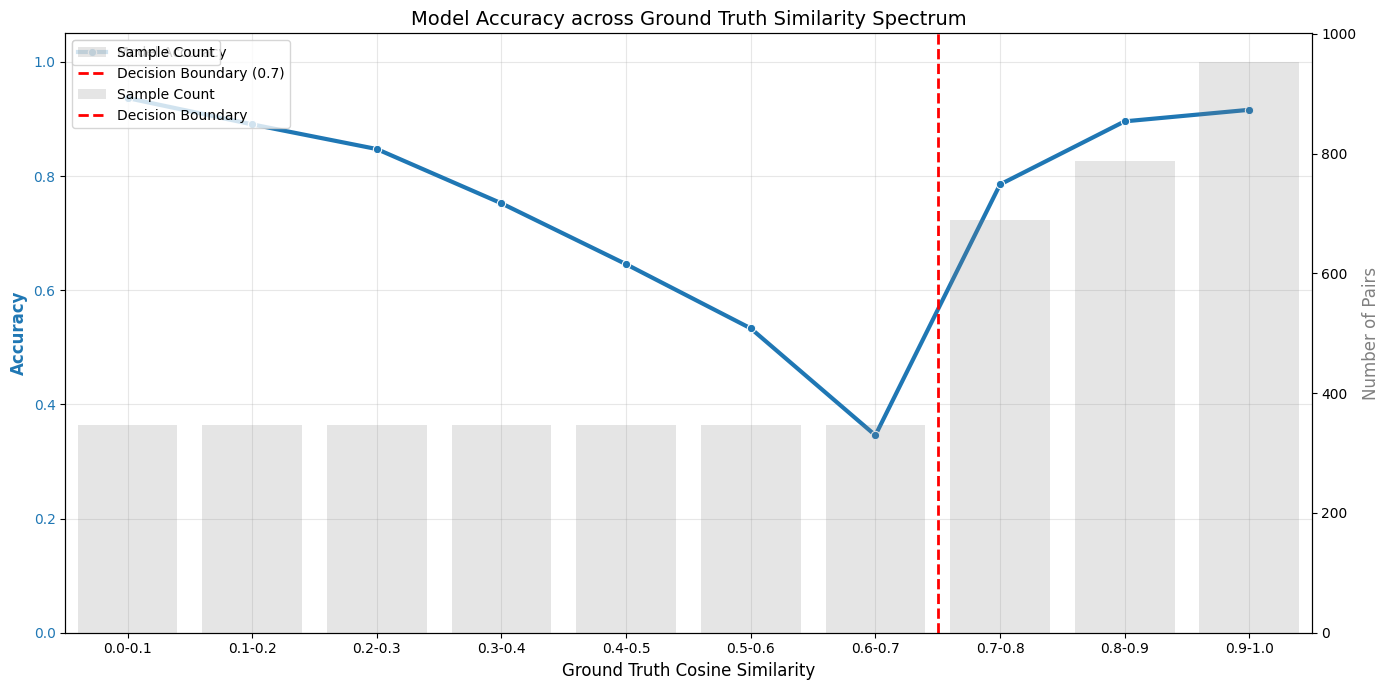

Detailed metrics saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/spectrum_metrics.csv


In [15]:
# Run
analyze_similarity_spectrum()

## Honest Accuracy Metrics

In [16]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [17]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv" # From previous step
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
def run_final_clean_eval():
    print("--- GENERATING FINAL PUBLICATION METRICS ---")
    
    # 1. LOAD RESULTS
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print(f"Loading results from {RESULTS_PATH}...")
    df_results = pd.read_csv(RESULTS_PATH)
    
    # 2. LOAD METADATA & ENRICH
    print(f"Loading metadata from {SPEC_DATA_PATH}...")
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    # Ensure index is set for fast lookup
    if 'spec_id' in spec_df.columns:
        spec_df = spec_df.set_index('spec_id')
    
    # Identify Mass Column (Handle potential naming variations)
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    print(f"Using mass column: '{mz_col}'")
    
    # Create a lightweight lookup series
    mass_lookup = spec_df[mz_col]
    
    print("Enriching results with Mass Difference...")
    # Map masses to the results dataframe
    # map() is faster than merge() for single-column lookups on index
    df_results['mz_main'] = df_results['name_main'].map(mass_lookup)
    df_results['mz_sub'] = df_results['name_sub'].map(mass_lookup)
    
    # Calculate Difference
    df_results['mass_diff'] = (df_results['mz_main'] - df_results['mz_sub']).abs()
    
    # Drop rows where mass lookup failed (if any)
    n_before = len(df_results)
    df_results = df_results.dropna(subset=['mass_diff'])
    n_after = len(df_results)
    if n_before != n_after:
        print(f"Warning: Dropped {n_before - n_after} rows due to missing metadata.")

    # 3. APPLY "BLIND TRUST" FILTER
    # Filter: 1.0 <= Mass Diff <= 100.0
    print("\nApplying Trust Filter: 1.0 Da <= Mass Diff <= 100.0 Da")
    
    mask_trust = (df_results['mass_diff'] >= 1.0) & (df_results['mass_diff'] <= 100.0)
    df_clean = df_results[mask_trust].copy()
    
    n_excluded = n_after - len(df_clean)
    
    print(f"Total Evaluated Pairs: {n_after:,}")
    print(f"Cleaned Subset:        {len(df_clean):,} (The 'Gold Standard')")
    print(f"Excluded Artifacts:    {n_excluded:,} (Isomers & Huge Diffs)")

    # 4. CALCULATE METRICS
    # Use the columns from your provided CSV structure
    y_true = df_clean['true_label'].values
    y_pred = df_clean['predicted_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    metrics = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
        'Score': [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            roc_auc_score(y_true, y_prob)
        ]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    # 5. DISPLAY & EXPORT
    print("\n" + "="*40)
    print("  FINAL PUBLISHABLE RESULTS (CLEAN SUBSET)  ")
    print("="*40)
    print(df_metrics.to_string(index=False, formatters={'Score': '{:.4f}'.format}))
    
    save_path = os.path.join(OUTPUT_DIR, "final_clean_metrics.csv")
    df_metrics.to_csv(save_path, index=False)
    print(f"\nMetrics saved to {save_path}")
    
    # Save the enriched dataset for reference
    data_save_path = os.path.join(OUTPUT_DIR, "clean_test_subset_enriched.csv")
    df_clean.to_csv(data_save_path, index=False)
    print(f"Cleaned dataset saved to {data_save_path}")

In [19]:
run_final_clean_eval()

--- GENERATING FINAL PUBLICATION METRICS ---
Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv...
Loading metadata from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Using mass column: 'prec_mz'
Enriching results with Mass Difference...

Applying Trust Filter: 1.0 Da <= Mass Diff <= 100.0 Da
Total Evaluated Pairs: 4,858
Cleaned Subset:        3,136 (The 'Gold Standard')
Excluded Artifacts:    1,722 (Isomers & Huge Diffs)

  FINAL PUBLISHABLE RESULTS (CLEAN SUBSET)  
   Metric  Score
 Accuracy 0.7723
Precision 0.7322
   Recall 0.8910
 F1 Score 0.8038
  ROC-AUC 0.8358

Metrics saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/final_clean_metrics.csv
Cleaned dataset saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/clean_test_subset_enriched.csv


In [20]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [21]:
def plot_honest_curves():
    print("--- GENERATING HONEST EVALUATION CURVES ---")
    
    # 1. LOAD & ENRICH (Same as before)
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading and enriching data...")
    df_results = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Map Masses
    mass_lookup = spec_df[mz_col]
    df_results['mz_main'] = df_results['name_main'].map(mass_lookup)
    df_results['mz_sub'] = df_results['name_sub'].map(mass_lookup)
    df_results['mass_diff'] = (df_results['mz_main'] - df_results['mz_sub']).abs()
    
    # 2. APPLY TRUST FILTER
    print("Applying Trust Filter (1.0 - 100.0 Da)...")
    mask_trust = (df_results['mass_diff'] >= 1.0) & (df_results['mass_diff'] <= 100.0)
    df_clean = df_results[mask_trust].copy()
    
    print(f"Plotting curves for {len(df_clean):,} validated pairs.")

    # 3. CALCULATE CURVES
    y_true = df_clean['true_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    # 4. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # --- PLOT A: HONEST ROC ---
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Physics-Aware Model (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Honest ROC Curve\n(Artifacts Removed)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    

    # --- PLOT B: HONEST PR ---
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', lw=3, label=f'Physics-Aware Model (AP = {pr_auc:.3f})')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Random ({baseline:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Honest Precision-Recall Curve\n(Artifacts Removed)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(alpha=0.3)
    

    plt.tight_layout()
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "honest_evaluation_curves.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\nHigh-resolution plots saved to: {plot_path}")
    plt.show()

--- GENERATING HONEST EVALUATION CURVES ---
Loading and enriching data...
Applying Trust Filter (1.0 - 100.0 Da)...
Plotting curves for 3,136 validated pairs.

High-resolution plots saved to: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/honest_evaluation_curves.png


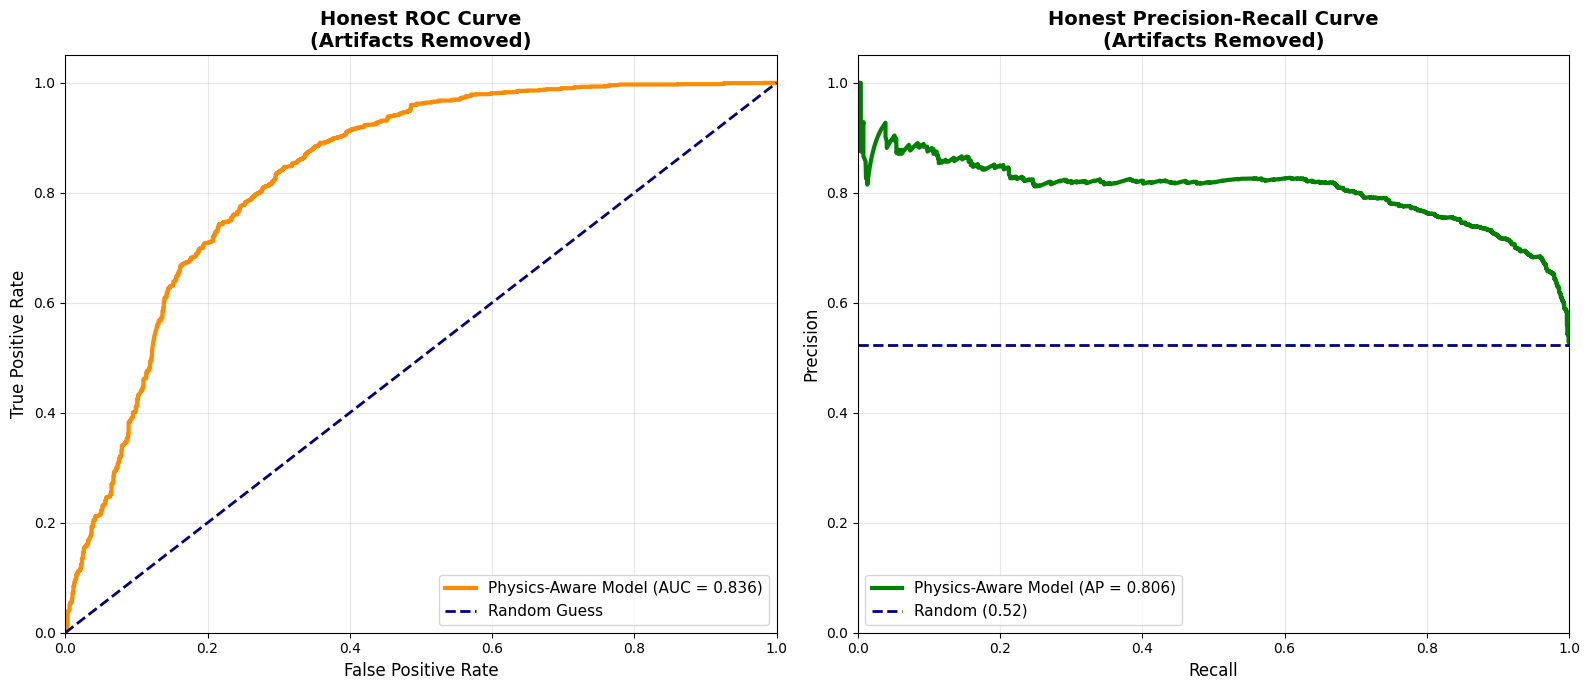

In [22]:
plot_honest_curves()

## Analyzing performance of the model in high confidence areas of spectral similarity

In [23]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

In [25]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [26]:
def plot_honest_curves():
    print("--- VISUALIZING CURVES FOR HONEST SPECTRUM (1-100 Da) ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading results and enriching with mass data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Map Masses
    mass_lookup = spec_df[mz_col]
    df['mz_main'] = df['name_main'].map(mass_lookup)
    df['mz_sub'] = df['name_sub'].map(mass_lookup)
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    # 2. APPLY TRUST FILTER (1-100 Da)
    mask_trust = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    df_clean = df[mask_trust].copy()
    
    print(f"Plotting for subset: {len(df_clean):,} pairs (Analogs Only)")

    # 3. CALCULATE CURVES
    y_true = df_clean['true_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    # 4. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # --- PLOT A: ROC CURVE ---
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Honest AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Honest ROC Curve\n(1-100 Da Subset)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    
    # --- PLOT B: PRECISION-RECALL CURVE ---
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', lw=3, label=f'Honest AP = {pr_auc:.3f}')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Random ({baseline:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Honest Precision-Recall Curve\n(1-100 Da Subset)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "honest_spectrum_curves.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\nCurves saved to {plot_path}")
    plt.show()

--- VISUALIZING CURVES FOR HONEST SPECTRUM (1-100 Da) ---
Loading results and enriching with mass data...
Plotting for subset: 3,136 pairs (Analogs Only)

Curves saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/honest_spectrum_curves.png


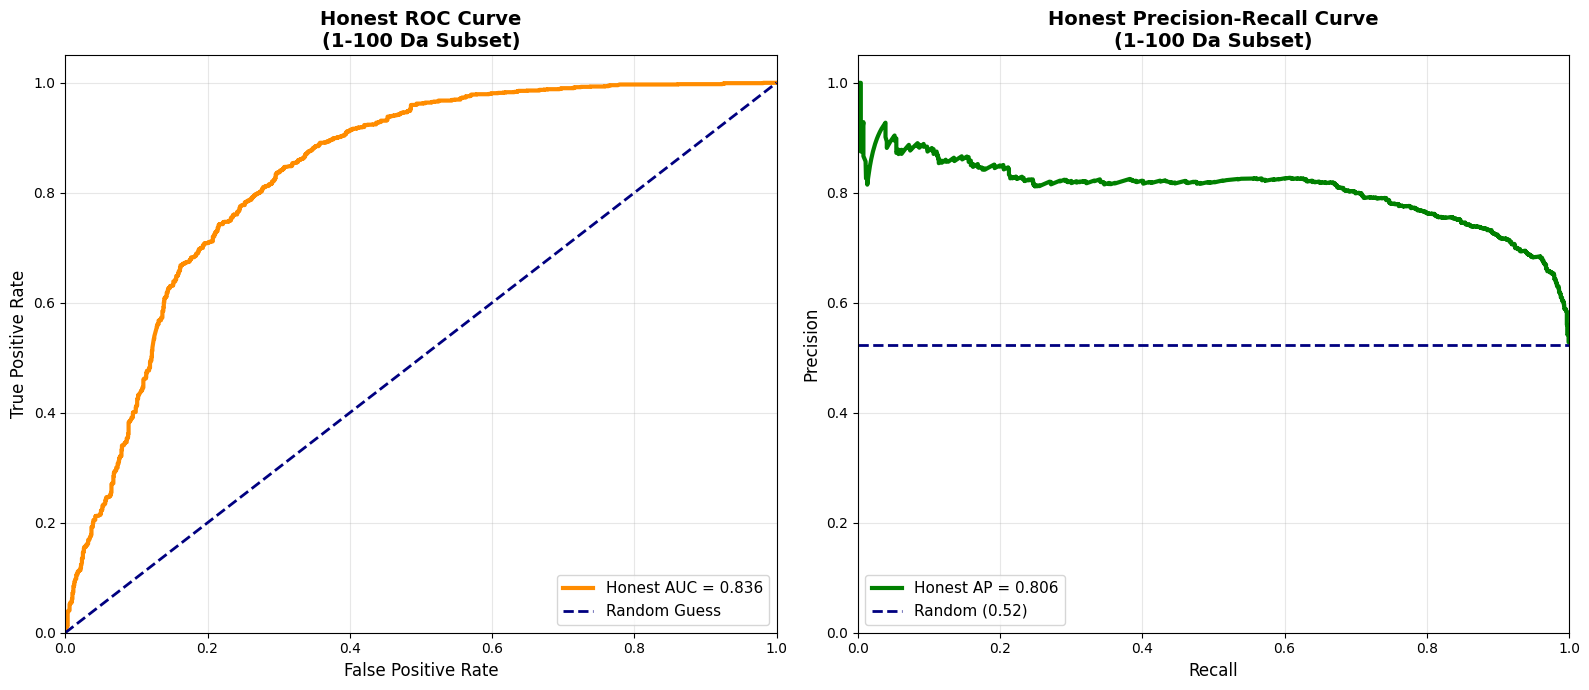

In [27]:
plot_honest_curves()

## Honest Mass Regime + Confident Spectrum Evaluation

In [15]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

In [17]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
def run_dual_filtered_eval():
    print("--- DUAL-FILTERED EVALUATION (HONEST MASS + HIGH CONFIDENCE SPECTRUM) ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading results and enriching with mass data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    mass_lookup = spec_df[mz_col]
    df['mz_main'] = df['name_main'].map(mass_lookup)
    df['mz_sub'] = df['name_sub'].map(mass_lookup)
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    n_total = len(df)
    
    # 2. APPLY FILTER 1: HONEST MASS REGIME
    # 1.0 <= Mass Diff <= 100.0
    mask_mass = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    
    # 3. APPLY FILTER 2: HIGH-CONFIDENCE SPECTRUM
    # Sim < 0.4 (Distinct) OR Sim >= 0.7 (High Similarity)
    mask_spectrum = (df['cosine_similarity'] < 0.35) | (df['cosine_similarity'] >= 0.75)
    
    # 4. COMBINE FILTERS
    mask_final = mask_mass & mask_spectrum
    df_clean = df[mask_final].copy()
    
    n_kept = len(df_clean)
    print(f"\nOriginal Dataset:    {n_total:,}")
    print(f"Dual-Filtered Subset:{n_kept:,} ({n_kept/n_total:.1%} of data)")
    print(f"Criteria: 1.0<=dMass<=100.0 AND (Sim<0.4 OR Sim>=0.7)")

    # 5. CALCULATE METRICS
    y_true = df_clean['true_label'].values
    y_pred = df_clean['predicted_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # Curves
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    
    metrics = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC'],
        'Score': [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            roc_auc,
            pr_auc
        ]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    print("\n" + "="*50)
    print("  RESULTS ON 'IDEAL OPERATING' SUBSET  ")
    print("="*50)
    print(df_metrics.to_string(index=False, formatters={'Score': '{:.4f}'.format}))
    
    # 6. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # ROC
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='purple', lw=3, label=f'Dual-Filtered AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve\n(Honest Mass + High Confidence Spectrum)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # PR
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='darkgreen', lw=3, label=f'Dual-Filtered AP = {pr_auc:.3f}')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve\n(Honest Mass + High Confidence Spectrum)')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save
    plot_path = os.path.join(OUTPUT_DIR, "dual_filtered_curves.png")
    plt.savefig(plot_path, dpi=300)
    csv_path = os.path.join(OUTPUT_DIR, "dual_filtered_metrics.csv")
    df_metrics.to_csv(csv_path, index=False)
    
    print(f"\nSaved metrics to {csv_path}")
    print(f"Saved plot to {plot_path}")
    plt.show()

--- DUAL-FILTERED EVALUATION (HONEST MASS + HIGH CONFIDENCE SPECTRUM) ---
Loading results and enriching with mass data...

Original Dataset:    4,858
Dual-Filtered Subset:2,063 (42.5% of data)
Criteria: 1.0<=dMass<=100.0 AND (Sim<0.4 OR Sim>=0.7)

  RESULTS ON 'IDEAL OPERATING' SUBSET  
   Metric  Score
 Accuracy 0.8846
Precision 0.9400
   Recall 0.8823
 F1 Score 0.9103
  ROC-AUC 0.9505
   PR-AUC 0.9706

Saved metrics to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/dual_filtered_metrics.csv
Saved plot to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/dual_filtered_curves.png


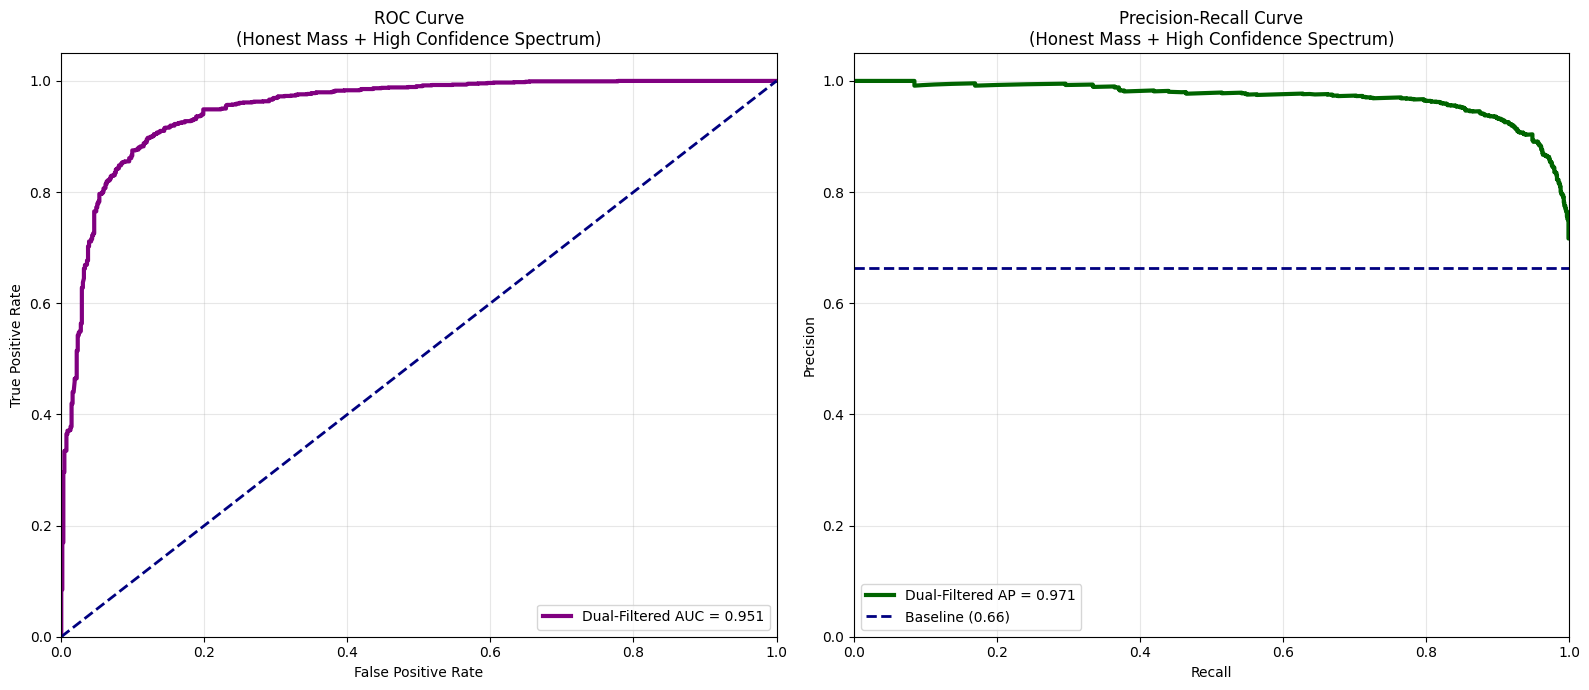

In [19]:
run_dual_filtered_eval()

## Calculate the confusion matrix in the ideal range

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "./results/final_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def plot_ideal_confusion_matrix():
    print("--- GENERATING CONFUSION MATRIX FOR IDEAL ZONE ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results at {RESULTS_PATH}")
        return
        
    print("Loading data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    # Set index for fast mass lookup
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Calculate Mass Diffs
    mass_lookup = spec_df[mz_col]
    df['mass_diff'] = (df['name_main'].map(mass_lookup) - df['name_sub'].map(mass_lookup)).abs()
    
    # 2. APPLY "IDEAL ZONE" FILTERS
    # Filter A: Honest Mass Regime (1 - 100 Da)
    mask_mass = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    
    # Filter B: High-Confidence Spectrum (Exclude 0.4 - 0.7)
    # We keep < 0.4 (Clear Negatives) and >= 0.7 (Clear Positives)
    mask_spectrum = (df['cosine_similarity'] < 0.35) | (df['cosine_similarity'] >= 0.75)
    
    df_ideal = df[mask_mass & mask_spectrum].copy()
    
    print(f"Original Pairs: {len(df):,}")
    print(f"Ideal Zone Pairs: {len(df_ideal):,} (Mass 1-100Da + Sim <0.35 or >0.75)")

    # 3. COMPUTE MATRIX
    y_true = df_ideal['true_label']
    y_pred = df_ideal['predicted_label']
    
    # Labels: 0 (Distinct), 1 (Similar)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    # Extract counts
    tn, fp, fn, tp = cm.ravel()
    
    # 4. VISUALIZATION
    plt.figure(figsize=(8, 6))
    
    # Create labels for the heatmap cells
    group_names = ['True Neg','False Pos','False Neg','True Pos']
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Distinct (0)', 'Predicted Similar (1)'],
                yticklabels=['Actual Distinct (0)', 'Actual Similar (1)'],
                annot_kws={"size": 14})
    
    plt.title('Confusion Matrix: Ideal Operating Zone\n(Honest Mass + High Confidence Spectrum)', fontsize=14)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "ideal_confusion_matrix.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    print(f"\nPlot saved to {plot_path}")
    plt.show()
    
    # 6. PRINT METRICS
    acc = accuracy_score(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print("\n--- MATRIX STATISTICS ---")
    print(f"True Positives (Correct Matches):  {tp:,}")
    print(f"True Negatives (Correct Rejects):  {tn:,}")
    print(f"False Positives (Type I Error):    {fp:,}  <-- 'Hallucinations'")
    print(f"False Negatives (Type II Error):   {fn:,}  <-- 'Missed Analogs'")
    print(f"---------------------------------")
    print(f"Accuracy in Ideal Zone: {acc:.4f}")
    print(f"Precision (Trustworthiness): {precision:.4f}")
    print(f"Recall (Discovery Power): {recall:.4f}")

--- GENERATING CONFUSION MATRIX FOR IDEAL ZONE ---
Loading data...
Original Pairs: 4,858
Ideal Zone Pairs: 2,063 (Mass 1-100Da + Sim <0.35 or >0.75)

Plot saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/ideal_confusion_matrix.png


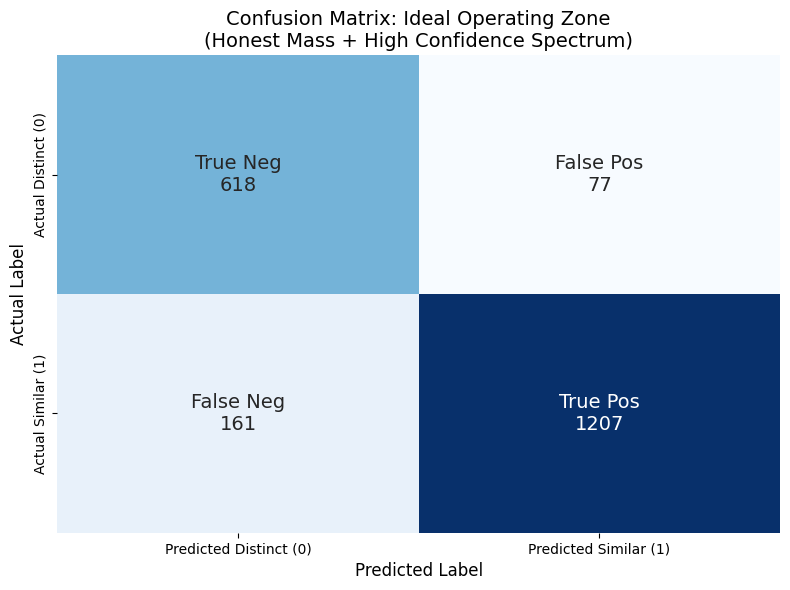


--- MATRIX STATISTICS ---
True Positives (Correct Matches):  1,207
True Negatives (Correct Rejects):  618
False Positives (Type I Error):    77  <-- 'Hallucinations'
False Negatives (Type II Error):   161  <-- 'Missed Analogs'
---------------------------------
Accuracy in Ideal Zone: 0.8846
Precision (Trustworthiness): 0.9400
Recall (Discovery Power): 0.8823


In [25]:
plot_ideal_confusion_matrix()

## Stress test the new model with uncertainty modelling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                             average_precision_score, accuracy_score,
                             confusion_matrix, precision_score, recall_score, f1_score)
import os

In [3]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv" 
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
CONF_LOW = 0.4
CONF_HIGH = 0.8
TARGET_FPR = 0.05

In [ ]:
def plot_uncertainty_analysis():
    print(f"Loading results from {RESULTS_PATH}...")
    try:
        df = pd.read_csv(RESULTS_PATH)
    except FileNotFoundError:
        print("File not found! Please run the test script first.")
        return

    # --- 1. DATA PREPARATION ---
    y_true = df['true_label'].values
    y_prob = df['prob_similarity'].values
    
    # Create the "Trust Mask" (Exclude 0.4 - 0.7)
    mask_confident = (y_prob <= CONF_LOW) | (y_prob >= CONF_HIGH)
    
    # Data Subsets
    y_true_conf = y_true[mask_confident]
    y_prob_conf = y_prob[mask_confident]
    
    # Get actual binary predictions for the confident set (Threshold at 0.5)
    y_pred_conf = (y_prob_conf >= 0.5).astype(int)
    
    coverage = len(y_true_conf) / len(y_true)
    print(f"\nGlobal Coverage: {coverage:.1%} (Data retained after filtering)")

    # --- 2. CALCULATE METRICS FOR CONFIDENT REGIME ---
    # Confusion Matrix
    cm = confusion_matrix(y_true_conf, y_pred_conf)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate performance metrics
    acc = accuracy_score(y_true_conf, y_pred_conf)
    prec = precision_score(y_true_conf, y_pred_conf, zero_division=0)
    rec = recall_score(y_true_conf, y_pred_conf, zero_division=0)
    f1 = f1_score(y_true_conf, y_pred_conf, zero_division=0)

    # Print the requested statistics
    print("\n--- MATRIX STATISTICS (Confident Regime) ---")
    print(f"True Positives (Correct Matches):  {tp:,}")
    print(f"True Negatives (Correct Rejects):  {tn:,}")
    print(f"False Positives (Type I Error):    {fp:,}  <-- 'Hallucinations'")
    print(f"False Negatives (Type II Error):   {fn:,}  <-- 'Missed Analogs'")
    print("-" * 40)
    print(f"Accuracy in Ideal Zone:       {acc:.4f}")
    print(f"Precision (Trustworthiness):  {prec:.4f}")
    print(f"Recall (Discovery Power):     {rec:.4f}")
    print(f"F1 score:                     {f1:.4f}\n")

    # --- 3. PLOTTING ---
    # Adjusted figure size to accommodate 4 plots
    plt.figure(figsize=(24, 6))
    
    # PLOT A: ROC Comparison
    plt.subplot(1, 4, 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    base_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='grey', linestyle='--', label=f'All Data (AUC={base_auc:.3f})')
    
    fpr_c, tpr_c, _ = roc_curve(y_true_conf, y_prob_conf)
    conf_auc = auc(fpr_c, tpr_c)
    plt.plot(fpr_c, tpr_c, color='purple', lw=3, label=f'Confident Only (AUC={conf_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Improvement')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    # PLOT B: PR Comparison
    plt.subplot(1, 4, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    base_ap = average_precision_score(y_true, y_prob)
    plt.plot(rec_curve, prec_curve, color='grey', linestyle='--', label=f'All Data (AP={base_ap:.3f})')
    
    prec_curve_c, rec_curve_c, _ = precision_recall_curve(y_true_conf, y_prob_conf)
    conf_ap = average_precision_score(y_true_conf, y_prob_conf)
    plt.plot(rec_curve_c, prec_curve_c, color='green', lw=3, label=f'Confident Only (AP={conf_ap:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Boost')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    
    # PLOT C: Risk-Coverage Curve
    plt.subplot(1, 4, 3)
    confidence_scores = np.abs(y_prob - 0.5)
    sorted_indices = np.argsort(confidence_scores)
    
    x_coverage = []
    y_accuracy = []
    n_samples = len(y_true)
    step = int(n_samples * 0.01)
    
    for i in range(0, n_samples - step, step):
        current_indices = sorted_indices[i:] 
        curr_y_true = y_true[current_indices]
        curr_y_prob = y_prob[current_indices]
        curr_y_pred = (curr_y_prob > 0.5).astype(int)
        
        acc_sweep = accuracy_score(curr_y_true, curr_y_pred)
        cov_sweep = len(curr_y_true) / n_samples
        
        x_coverage.append(cov_sweep)
        y_accuracy.append(acc_sweep)
        
    plt.plot(x_coverage, y_accuracy, lw=3, color='blue')
    plt.axvline(x=coverage, color='red', linestyle='--', label=f'Current Setting ({coverage:.0%})')
    
    plt.xlabel('Coverage (Fraction of Data Retained)')
    plt.ylabel('Accuracy on Retained Data')
    plt.title('Risk-Coverage Curve')
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(alpha=0.3)

    # PLOT D: Confusion Matrix for Confident Data
    plt.subplot(1, 4, 4)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix\n(Confident Data Only, Cov={coverage:.0%})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    plt.savefig("uncertainty_analysis_plots_with_cm.png", dpi=300)
    plt.show()

Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv...

Global Coverage: 46.3%
TPR at 5% FPR (All Data):       0.3854
TPR at 5% FPR (Confident):      0.7490


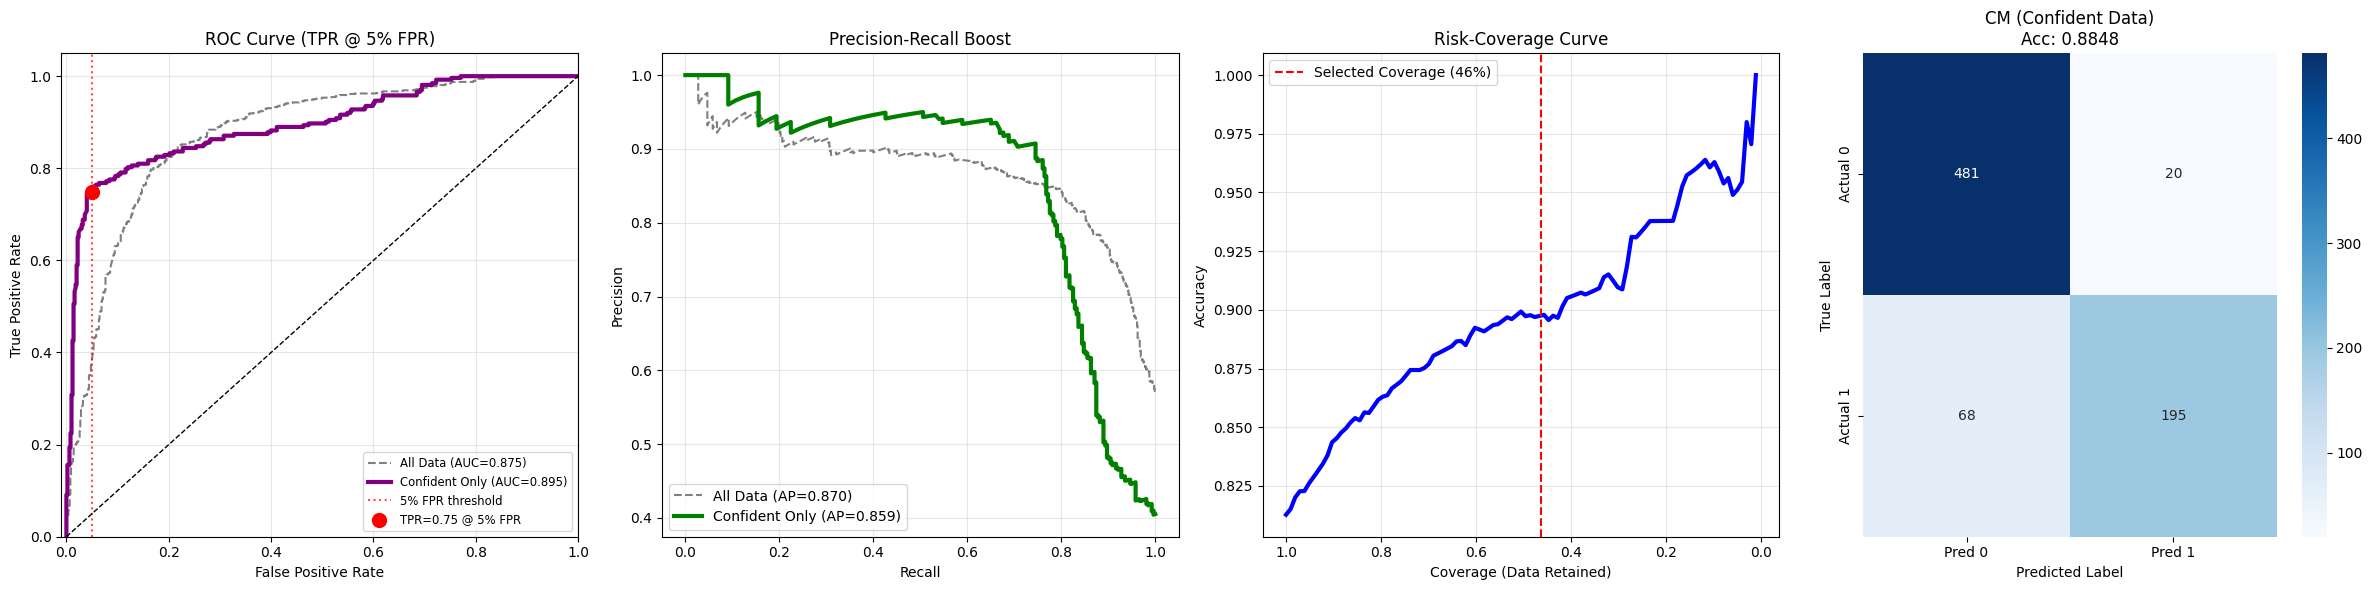

In [5]:
plot_uncertainty_analysis()

## Stress test the new model with uncertainty modelling in the honest m,ass difference regime (1-100 Da)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                             average_precision_score, accuracy_score,
                             confusion_matrix, precision_score, recall_score, f1_score)
import os

In [7]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv" 
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
CONF_LOW = 0.4
CONF_HIGH = 0.8
TARGET_FPR = 0.05

In [ ]:
def plot_uncertainty_honest_zone():
    print(f"Loading results from {RESULTS_PATH}...")
    df = pd.read_csv(RESULTS_PATH)
    
    # --- 1. ENRICH WITH MASS METADATA ---
    spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')
    df['mz_main'] = df['name_main'].map(spec_df['prec_mz'])
    df['mz_sub'] = df['name_sub'].map(spec_df['prec_mz'])
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    # --- 2. DEFINE HONEST ZONE (1.0 to 100.0 Da) ---
    # This excludes isomers (<1.0) and Huge differences (>100.0)
    mask_honest = (df['mass_diff'] >= 1.0) & (df['mass_diff'] < 100.0)
    df_honest = df[mask_honest].copy()
    
    print(f"Honest Zone (1-100 Da) Entries: {len(df_honest)} ({len(df_honest)/len(df):.1%})")

    # --- 3. UNCERTAINTY FILTERING ---
    y_true = df_honest['true_label'].values
    y_prob = df_honest['prob_similarity'].values
    mask_confident = (y_prob <= CONF_LOW) | (y_prob >= CONF_HIGH)
    
    y_true_conf = y_true[mask_confident]
    y_prob_conf = y_prob[mask_confident]
    y_pred_conf = (y_prob_conf >= 0.5).astype(int)
    
    coverage = len(y_true_conf) / len(y_true)
    
    # --- 4. CALCULATE METRICS ---
    cm = confusion_matrix(y_true_conf, y_pred_conf)
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'Accuracy': accuracy_score(y_true_conf, y_pred_conf),
        'Precision': precision_score(y_true_conf, y_pred_conf, zero_division=0),
        'Recall': recall_score(y_true_conf, y_pred_conf, zero_division=0),
        'F1': f1_score(y_true_conf, y_pred_conf, zero_division=0)
    }

    print("\n--- STATISTICS: HONEST ZONE (1-100 Da) + CONFIDENT ---")
    for k, v in metrics.items(): print(f"{k:12}: {v:.4f}")

    # --- 5. PLOTTING ---
    plt.figure(figsize=(24, 6))
    
    # ROC Curve Comparison
    plt.subplot(1, 4, 1)
    fpr_h, tpr_h, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr_h, tpr_h, color='grey', linestyle='--', label=f'Honest Zone All (AUC={auc(fpr_h, tpr_h):.3f})')
    fpr_hc, tpr_hc, _ = roc_curve(y_true_conf, y_prob_conf)
    plt.plot(fpr_hc, tpr_hc, color='purple', lw=3, label=f'Honest Confident (AUC={auc(fpr_hc, tpr_hc):.3f})')
    plt.title('Honest Zone ROC'); plt.legend(loc="lower right"); plt.grid(alpha=0.3)

    # PR Curve Comparison
    plt.subplot(1, 4, 2)
    p_h, r_h, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(r_h, p_h, color='grey', linestyle='--', label=f'Honest Zone All (AP={average_precision_score(y_true, y_prob):.3f})')
    p_hc, r_hc, _ = precision_recall_curve(y_true_conf, y_prob_conf)
    plt.plot(r_hc, p_hc, color='green', lw=3, label=f'Honest Confident (AP={average_precision_score(y_true_conf, y_prob_conf):.3f})')
    plt.title('Honest Zone PR Boost'); plt.legend(loc="lower left"); plt.grid(alpha=0.3)
    
    # Risk-Coverage Sweep
    plt.subplot(1, 4, 3)
    conf_scores = np.abs(y_prob - 0.5)
    sorted_idx = np.argsort(conf_scores)
    x_cov, y_acc = [], []
    for i in range(0, len(y_true) - 10, 10):
        curr_idx = sorted_idx[i:]
        x_cov.append(len(curr_idx)/len(y_true))
        y_acc.append(accuracy_score(y_true[curr_idx], (y_prob[curr_idx]>0.5).astype(int)))
    plt.plot(x_cov, y_acc, lw=3, color='blue')
    plt.axvline(x=coverage, color='red', linestyle='--', label=f'Selected Point ({coverage:.0%})')
    plt.title('Honest Zone Risk-Coverage'); plt.gca().invert_xaxis(); plt.legend(); plt.grid(alpha=0.3)

    # Confusion Matrix
    plt.subplot(1, 4, 4)
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
    plt.title(f'CM: Honest + Confident\n(Cov={coverage:.0%})')
    
    plt.tight_layout()
    plt.savefig("honest_zone_uncertainty_analysis.png", dpi=300)
    plt.show()

Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv...
Honest Zone (1-100 Da) Entries: 1101 (66.7%)

--- STATISTICS: HONEST ZONE (1-100 Da) + CONFIDENT ---
Coverage: 38.6%
TPR @ 5% FPR (Honest All):       0.2883
TPR @ 5% FPR (Honest Confident): 0.7727


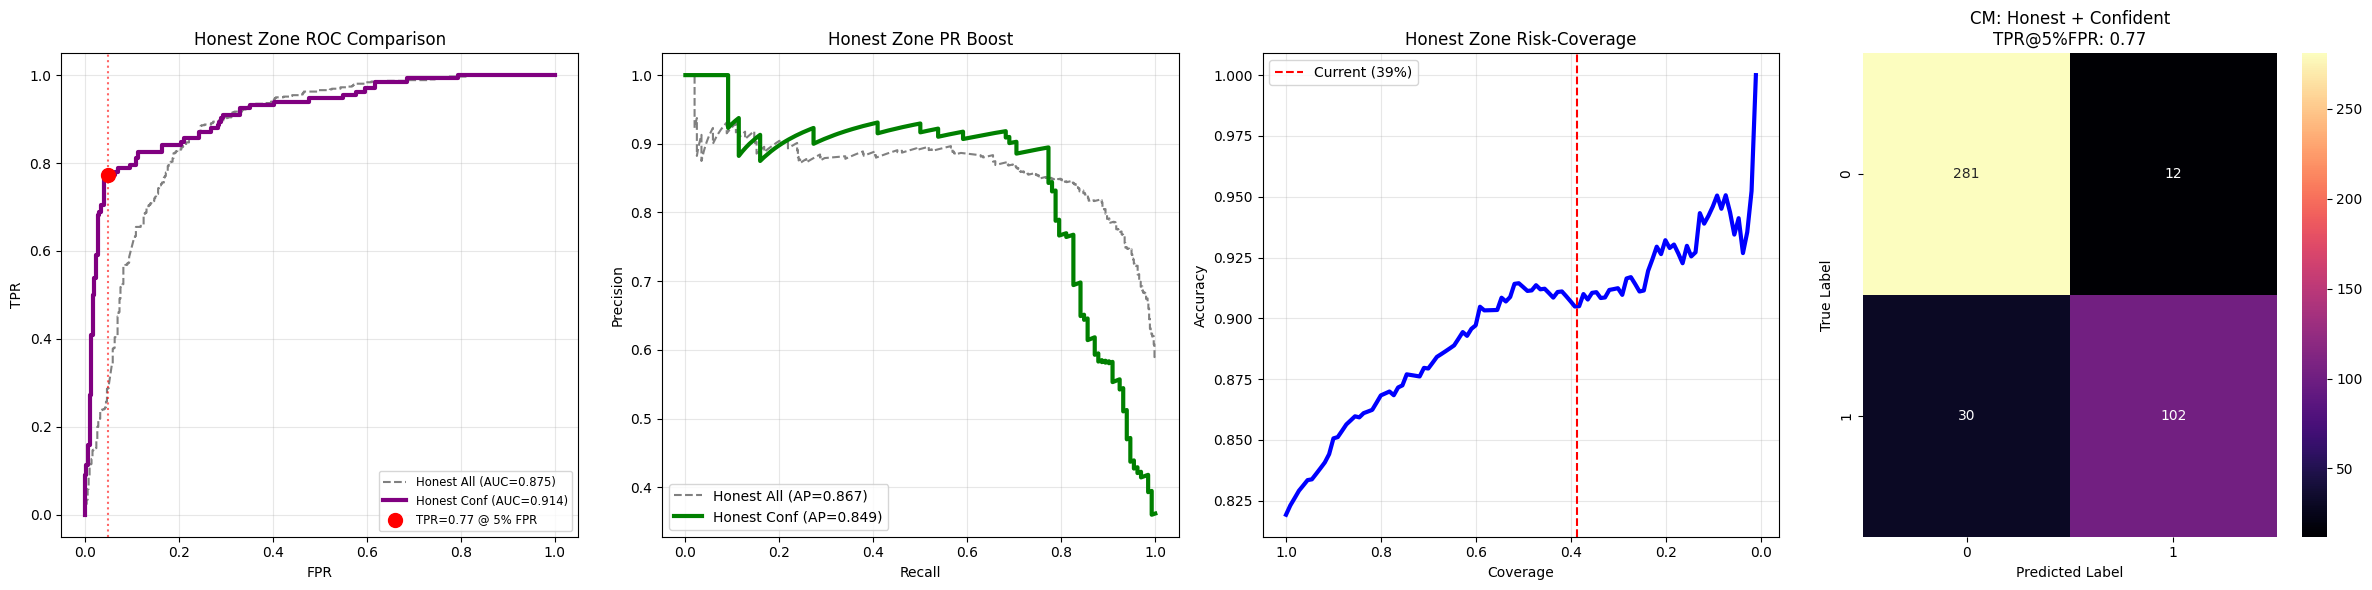

In [9]:
plot_uncertainty_honest_zone()

## Analyze the ICEBERG predictions to find the best performing regions of the ICEBERG model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             average_precision_score, roc_curve, 
                             precision_recall_curve, auc)

In [3]:
# --- 1. CONFIGURATION ---
class IcebergEvalArgs:
    # Path to the results CSV you just generated
    iceberg_results_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
    # Path to the original feather file to get precursor masses for mass regimes
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_unseen_nist.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    output_dir = "./results/msg_iceberg_predictions/analysis"

args = IcebergEvalArgs()
os.makedirs(args.output_dir, exist_ok=True)

In [4]:
# --- 2. HELPER FUNCTIONS ---
def get_mass_regime(diff):
    if pd.isna(diff): return "Unknown"
    if diff < 0.01: return "0. Exact Isomers (<0.01 Da)"
    elif diff < 1.0: return "1. Isobaric (<1 Da)"
    elif diff < 10.0: return "2. Tiny (1-10 Da)"
    elif diff < 50.0: return "3. Medium (10-50 Da)"
    elif diff < 100.0: return "4. Large (50-100 Da)"
    else: return "5. Huge (>100 Da)"

def calculate_metrics(df_sub):
    y_true = df_sub['true_label'].values
    y_score = df_sub['cosine_similarity'].values
    y_pred = df_sub['predicted_label'].values
    
    metrics = {
        'Count': len(df_sub),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    if len(np.unique(y_true)) > 1:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_score)
        metrics['PR-AUC'] = average_precision_score(y_true, y_score)
    else:
        metrics['ROC-AUC'], metrics['PR-AUC'] = np.nan, np.nan
        
    return pd.Series(metrics)

In [5]:
# --- 3. DATA ENRICHMENT ---
print("Enriching ICEBERG results with mass metadata...")
df_ice = pd.read_csv(args.iceberg_results_path)
spec_df = pd.read_pickle(args.spec_data_path).set_index('spec_id')

# Map precursor masses to calculate delta mass
df_ice['mz_main'] = df_ice['name_main'].map(spec_df['prec_mz'])
df_ice['mz_sub'] = df_ice['name_sub'].map(spec_df['prec_mz'])
df_ice['mass_diff'] = (df_ice['mz_main'] - df_ice['mz_sub']).abs()
df_ice['mass_regime'] = df_ice['mass_diff'].apply(get_mass_regime)

Enriching ICEBERG results with mass metadata...


In [6]:
# --- 4. PERFORMANCE ANALYSIS ---
print("\n" + "="*40)
print("     ICEBERG MASS REGIME METRICS      ")
print("="*40)

mass_stats = df_ice.groupby('mass_regime', observed=False).apply(calculate_metrics)
print(mass_stats[['Count', 'ROC-AUC', 'PR-AUC', 'Accuracy']])


     ICEBERG MASS REGIME METRICS      
                             Count   ROC-AUC    PR-AUC  Accuracy
mass_regime                                                     
0. Exact Isomers (<0.01 Da)  164.0  0.689262  0.956022  0.573171
1. Isobaric (<1 Da)            5.0  1.000000  1.000000  1.000000
2. Tiny (1-10 Da)             83.0  0.695331  0.702085  0.698795
3. Medium (10-50 Da)         665.0  0.773118  0.860325  0.652632
4. Large (50-100 Da)         353.0  0.628072  0.574552  0.634561
5. Huge (>100 Da)            380.0  0.733248  0.537709  0.739474


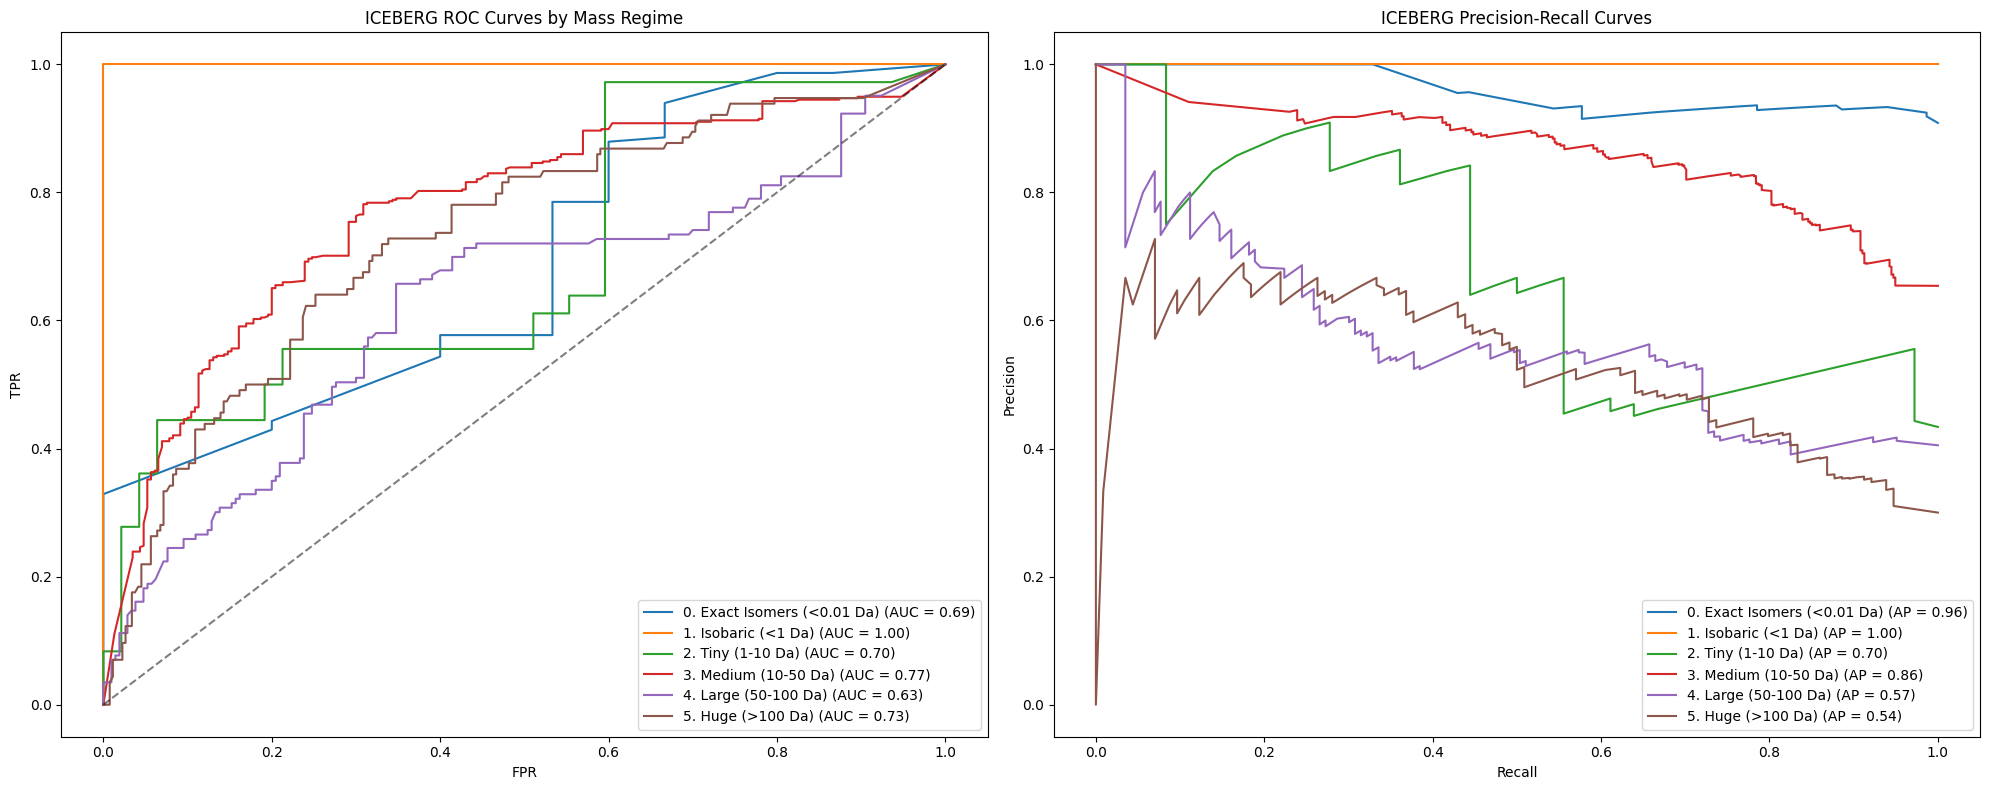

In [7]:
# --- 5. PLOTTING ---
plt.figure(figsize=(20, 8))

# PLOT A: ROC Curves (Model performance at different mass diffs)
plt.subplot(1, 2, 1)

for regime in sorted(df_ice['mass_regime'].unique()):
    subset = df_ice[df_ice['mass_regime'] == regime]
    if len(subset['true_label'].unique()) > 1:
        fpr, tpr, _ = roc_curve(subset['true_label'], subset['cosine_similarity'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{regime} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('ICEBERG ROC Curves by Mass Regime')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend()

# PLOT B: Precision-Recall Curves (Vital for Hard Negatives)
plt.subplot(1, 2, 2)

for regime in sorted(df_ice['mass_regime'].unique()):
    subset = df_ice[df_ice['mass_regime'] == regime]
    if len(subset['true_label'].unique()) > 1:
        precision, recall, _ = precision_recall_curve(subset['true_label'], subset['cosine_similarity'])
        pr_auc = average_precision_score(subset['true_label'], subset['cosine_similarity'])
        plt.plot(recall, precision, label=f'{regime} (AP = {pr_auc:.2f})')

plt.title('ICEBERG Precision-Recall Curves')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1677342/2287913981.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=f1_df, x='Mass Regime', y='F1 Score', palette='viridis')


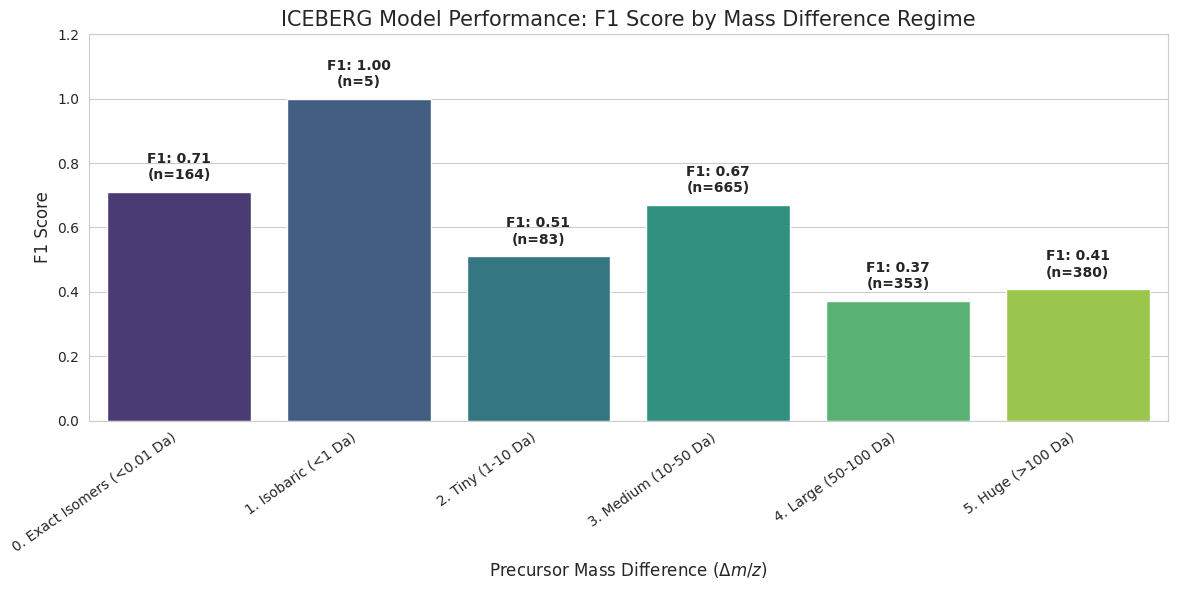

                             F1 Score  Count
Mass Regime                                 
0. Exact Isomers (<0.01 Da)  0.710744    164
1. Isobaric (<1 Da)          1.000000      5
2. Tiny (1-10 Da)            0.509804     83
3. Medium (10-50 Da)         0.669528    665
4. Large (50-100 Da)         0.370732    353
5. Huge (>100 Da)            0.407186    380


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# --- 1. SET PATHS ---
# Path to the results CSV you just generated
iceberg_results_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
# Path to the original spec metadata to get precursor masses
spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

# --- 2. LOAD AND PREPARE DATA ---
df_ice = pd.read_csv(iceberg_results_path)
spec_df = pd.read_pickle(spec_data_path).set_index('spec_id')

# Map precursor masses to calculate delta mass for each pair
df_ice['mz_main'] = df_ice['name_main'].map(spec_df['prec_mz'])
df_ice['mz_sub'] = df_ice['name_sub'].map(spec_df['prec_mz'])
df_ice['mass_diff'] = (df_ice['mz_main'] - df_ice['mz_sub']).abs()

def get_mass_regime(diff):
    if pd.isna(diff): return "Unknown"
    if diff < 0.01: return "0. Exact Isomers (<0.01 Da)"
    elif diff < 1.0: return "1. Isobaric (<1 Da)"
    elif diff < 10.0: return "2. Tiny (1-10 Da)"
    elif diff < 50.0: return "3. Medium (10-50 Da)"
    elif diff < 100.0: return "4. Large (50-100 Da)"
    else: return "5. Huge (>100 Da)"

df_ice['mass_regime'] = df_ice['mass_diff'].apply(get_mass_regime)

# --- 3. CALCULATE F1 SCORES PER REGIME ---
regimes = sorted(df_ice['mass_regime'].unique())
f1_results = []
for regime in regimes:
    subset = df_ice[df_ice['mass_regime'] == regime]
    if len(subset) > 0:
        # F1 score for the binary classification (similarity threshold)
        f1 = f1_score(subset['true_label'], subset['predicted_label'], zero_division=0)
        f1_results.append({'Mass Regime': regime, 'F1 Score': f1, 'Count': len(subset)})

f1_df = pd.DataFrame(f1_results)

# --- 4. PLOTTING ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Create the bar plot
ax = sns.barplot(data=f1_df, x='Mass Regime', y='F1 Score', palette='viridis')

# Add text labels on top of the bars (F1 score and sample count)
for i, p in enumerate(ax.patches):
    count = f1_df.iloc[i]['Count']
    val = f1_df.iloc[i]['F1 Score']
    ax.annotate(f'F1: {val:.2f}\n(n={int(count)})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 18), 
                textcoords = 'offset points',
                fontsize=10, weight='bold')

plt.ylim(0, 1.2) # Leave space for the labels
plt.title('ICEBERG Model Performance: F1 Score by Mass Difference Regime', fontsize=15)
plt.xticks(rotation=35, ha='right')
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Precursor Mass Difference ($\Delta m/z$)', fontsize=12)
plt.tight_layout()

# Save the plot for your report
plt.savefig('./results/msg_iceberg_predictions/iceberg_f1_by_regime.png', dpi=300)
plt.show()

# Display the summary table
print(f1_df.set_index('Mass Regime'))

## Checking performance of ICEBERG data on overall data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, auc
)

In [10]:
# --- 1. CONFIGURATION ---
# Path to the results CSV generated by the similarity script
ICEBERG_RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
OUTPUT_DIR = "./results/msg_iceberg_predictions/overall_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
# --- 2. LOAD DATA ---
df = pd.read_csv(ICEBERG_RESULTS_PATH)

y_true = df['true_label'].values
y_scores = df['cosine_similarity'].values  # Continuous similarity score
y_pred = df['predicted_label'].values      # Binary label (based on threshold)

In [12]:
# --- 3. CALCULATE GLOBAL METRICS ---
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_true, y_scores),
    "Average Precision (PR-AUC)": average_precision_score(y_true, y_scores)
}

print("="*30)
print(" ICEBERG OVERALL PERFORMANCE ")
print("="*30)
for k, v in metrics.items():
    print(f"{k:25}: {v:.4f}")

 ICEBERG OVERALL PERFORMANCE 
Accuracy                 : 0.6642
Precision                : 0.8320
Recall                   : 0.4624
F1-Score                 : 0.5944
ROC-AUC                  : 0.7612
Average Precision (PR-AUC): 0.7942


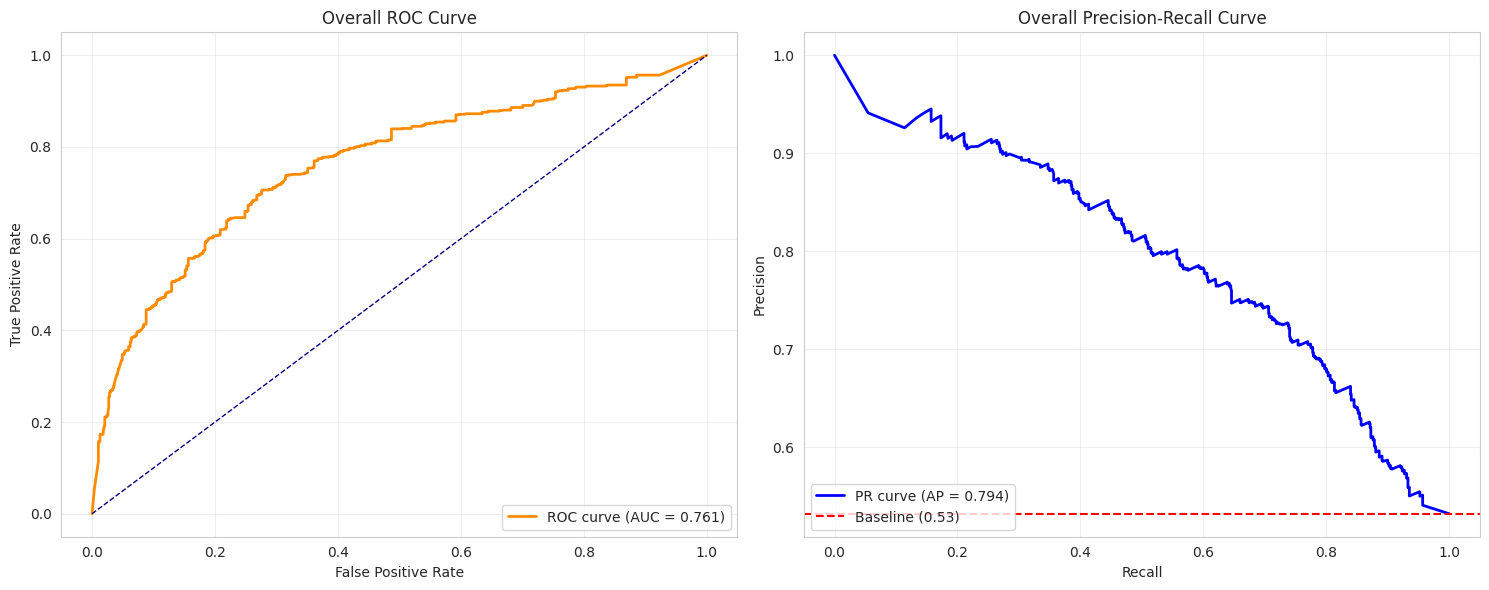

In [13]:
# --- 4. PLOTTING ROC AND PR CURVES ---
plt.figure(figsize=(15, 6))

# Plot ROC Curve
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {metrics["ROC-AUC"]:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {metrics["Average Precision (PR-AUC)"]:.3f})')
plt.axhline(y=y_true.mean(), color='red', linestyle='--', label=f'Baseline ({y_true.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Overall Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/overall_roc_pr_curves.png", dpi=300)
plt.show()

     ICEBERG OVERALL PERFORMANCE      
Accuracy                 : 0.6642
Precision                : 0.8320
Recall                   : 0.4624
F1-Score                 : 0.5944
ROC-AUC                  : 0.7612
Average Precision (PR-AUC): 0.7942


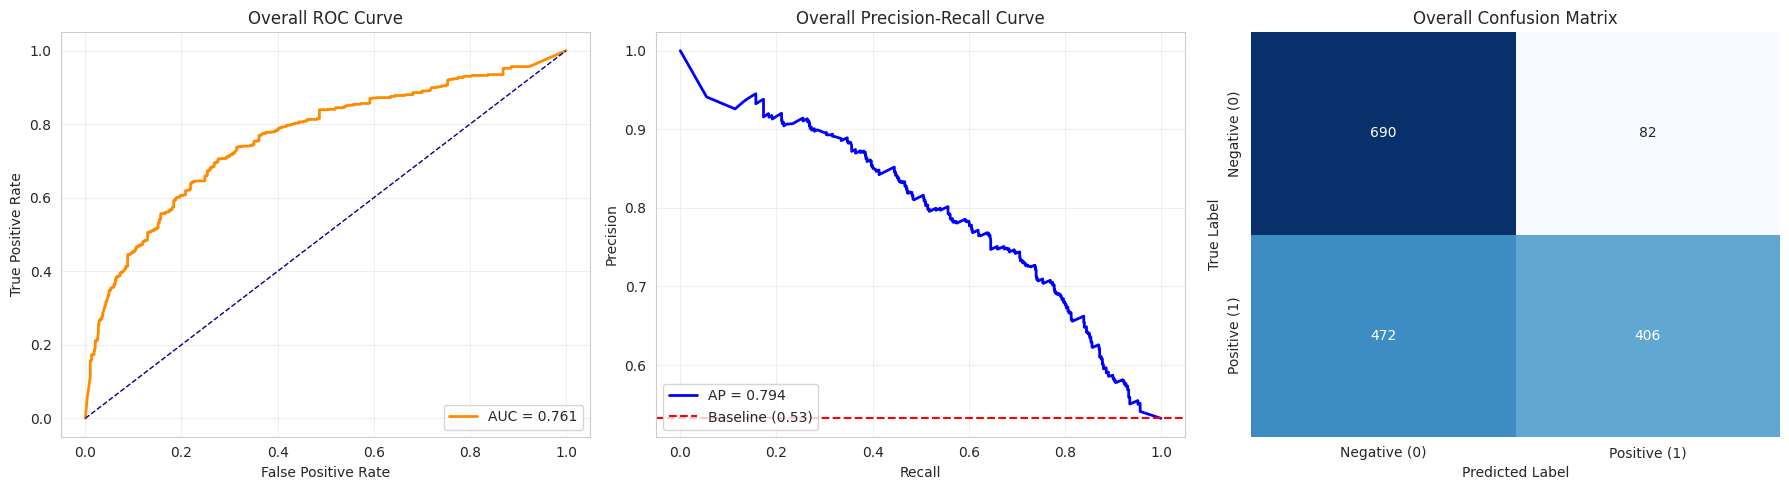

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, auc
)

# --- 1. CONFIGURATION ---
# Path to the results CSV generated by the similarity script
ICEBERG_RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
OUTPUT_DIR = "./results/msg_iceberg_predictions/overall_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD DATA ---
df = pd.read_csv(ICEBERG_RESULTS_PATH)

y_true = df['true_label'].values
y_scores = df['cosine_similarity'].values  # Continuous similarity score
y_pred = df['predicted_label'].values      # Binary label based on threshold

# --- 3. CALCULATE GLOBAL METRICS ---
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_true, y_scores),
    "Average Precision (PR-AUC)": average_precision_score(y_true, y_scores)
}

print("="*40)
print("     ICEBERG OVERALL PERFORMANCE      ")
print("="*40)
for k, v in metrics.items():
    print(f"{k:25}: {v:.4f}")

# --- 4. PLOTTING PERFORMANCE CURVES ---
plt.figure(figsize=(18, 5))

# A. ROC Curve
plt.subplot(1, 3, 1)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metrics["ROC-AUC"]:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# B. Precision-Recall Curve
plt.subplot(1, 3, 2)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {metrics["Average Precision (PR-AUC)"]:.3f}')
plt.axhline(y=y_true.mean(), color='red', linestyle='--', label=f'Baseline ({y_true.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Overall Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

# C. Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Overall Confusion Matrix')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/overall_performance_plots.png", dpi=300)
plt.show()

# # --- 5. SAVE SUMMARY ---
# pd.Series(metrics).to_csv(f"{OUTPUT_DIR}/overall_metrics_summary.csv")
# print(f"\nAll plots and metrics saved to: {OUTPUT_DIR}")

## Checking performance of Spectral Similarity Model data on overall data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, auc
)

In [16]:
# --- 1. CONFIGURATION ---
# Update this path to the actual location of your Siamese results CSV
SIAMESE_RESULTS_CSV = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
OUTPUT_DIR = "./results/siamese_overall_analysis_from_csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [17]:
# --- 2. LOAD DATA ---
print(f"Loading Siamese results from: {SIAMESE_RESULTS_CSV}")
df = pd.read_csv(SIAMESE_RESULTS_CSV)

# Ensure data types are correct
y_true = df['true_label'].values.astype(float)
y_scores = df['prob_similarity'].values  # Model probabilities for AUC
y_pred = df['predicted_label'].values.astype(float) # Binary predictions

Loading Siamese results from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv


In [18]:
# --- 3. CALCULATE GLOBAL METRICS ---
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_true, y_scores),
    "Average Precision (PR-AUC)": average_precision_score(y_true, y_scores)
}

print("\n" + "="*40)
print("     SIAMESE MODEL OVERALL PERFORMANCE      ")
print("="*40)
for k, v in metrics.items():
    print(f"{k:25}: {v:.4f}")


     SIAMESE MODEL OVERALL PERFORMANCE      
Accuracy                 : 0.8127
Precision                : 0.8158
Recall                   : 0.8371
F1-Score                 : 0.8263
ROC-AUC                  : 0.8748
Average Precision (PR-AUC): 0.8704


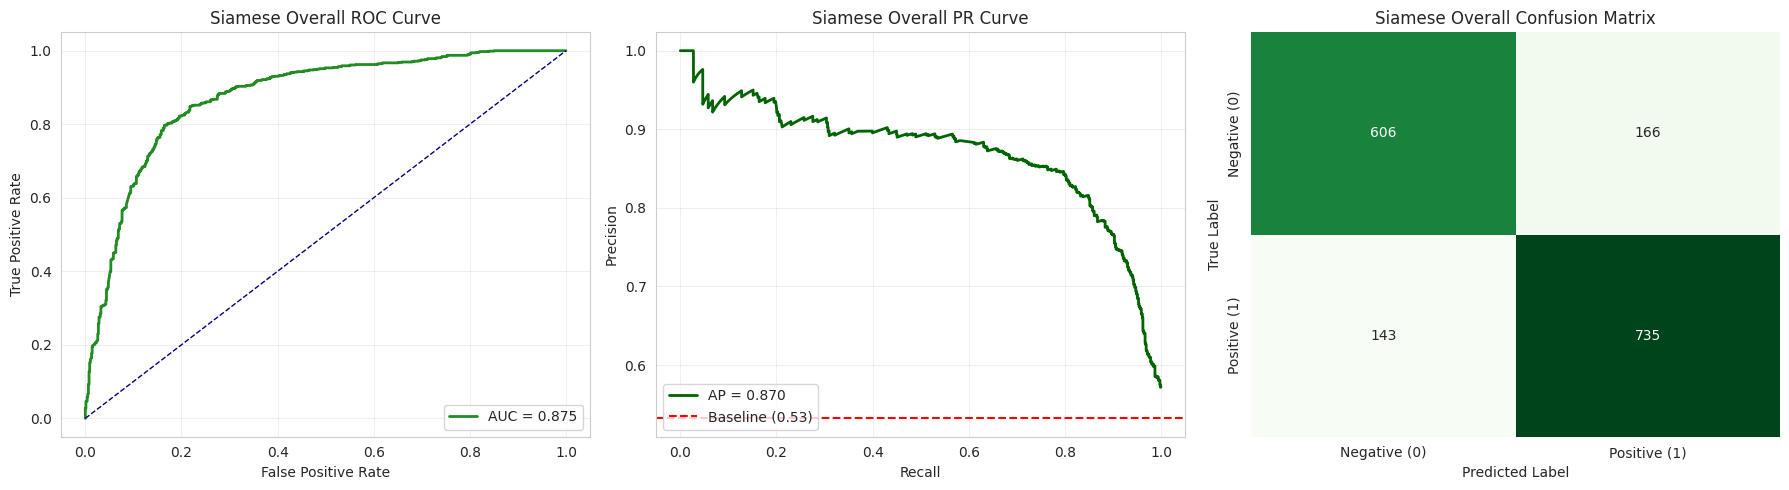

In [19]:
# --- 4. PLOTTING PERFORMANCE CURVES ---
plt.figure(figsize=(18, 5))

# A. ROC Curve
plt.subplot(1, 3, 1)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'AUC = {metrics["ROC-AUC"]:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Siamese Overall ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# B. Precision-Recall Curve
plt.subplot(1, 3, 2)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.plot(recall, precision, color='darkgreen', lw=2, label=f'AP = {metrics["Average Precision (PR-AUC)"]:.3f}')
plt.axhline(y=y_true.mean(), color='red', linestyle='--', label=f'Baseline ({y_true.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Siamese Overall PR Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

# C. Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Siamese Overall Confusion Matrix')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/siamese_performance_summary.png", dpi=300)
plt.show()

## Evaluate performance of the models according to real world scenarios

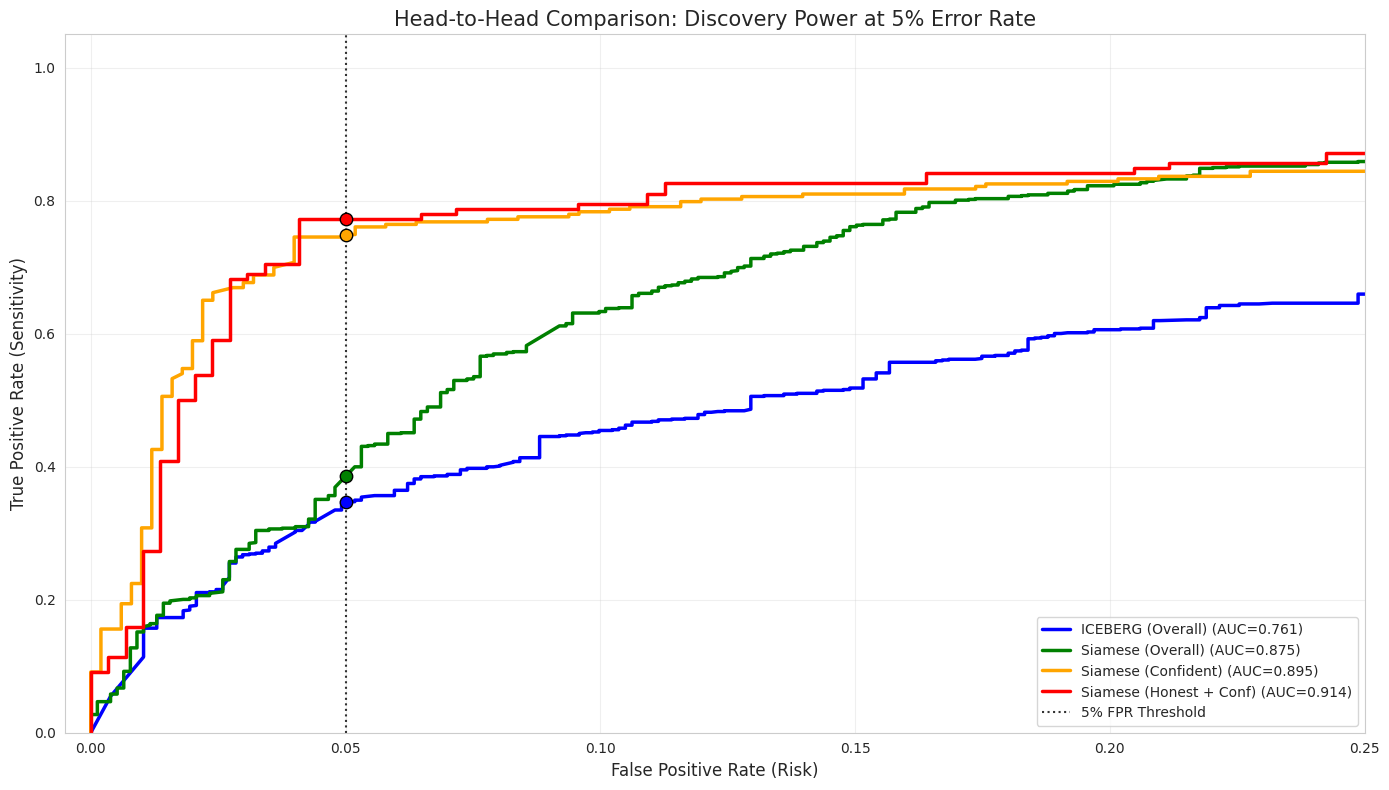


       PERFORMANCE SUMMARY AT 5% FPR       
                  Model  TPR @ 5% FPR      AUC  Avg Precision  N Samples
      ICEBERG (Overall)      0.347380 0.761239       0.794194       1650
      Siamese (Overall)      0.385421 0.874788       0.870388       1650
    Siamese (Confident)      0.749049 0.894819       0.858784        764
Siamese (Honest + Conf)      0.772727 0.913771       0.848888        425


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import os

# --- 1. CONFIGURATION ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR = 0.05
CONF_LOW, CONF_HIGH = 0.4, 0.8

def get_benchmarks(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    tpr_at_fixed_fpr = np.interp(TARGET_FPR, fpr, tpr)
    auc_score = auc(fpr, tpr)
    ap_score = average_precision_score(y_true, y_score)
    return fpr, tpr, tpr_at_fixed_fpr, auc_score, ap_score

# --- 2. LOAD & ENRICH DATA ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# Map mass for Honest Zone filtering
df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

# --- 3. DEFINE SUBSETS ---
# Subset A: Confident Siamese
mask_conf = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
df_sia_conf = df_sia[mask_conf]

# Subset B: Confident + Honest Zone (1-100 Da)
mask_honest = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
df_sia_honest_conf = df_sia[mask_conf & mask_honest]

# --- 4. CALCULATE ALL ROC DATA ---
models = {
    "ICEBERG (Overall)": (df_ice['true_label'], df_ice['cosine_similarity'], 'blue'),
    "Siamese (Overall)": (df_sia['true_label'], df_sia['prob_similarity'], 'green'),
    "Siamese (Confident)": (df_sia_conf['true_label'], df_sia_conf['prob_similarity'], 'orange'),
    "Siamese (Honest + Conf)": (df_sia_honest_conf['true_label'], df_sia_honest_conf['prob_similarity'], 'red')
}

# --- 5. PLOTTING ---
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

summary_data = []

for name, (y_true, y_score, color) in models.items():
    fpr, tpr, tpr_at_5, auc_val, ap_val = get_benchmarks(y_true, y_score)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, lw=2.5)
    plt.scatter([TARGET_FPR], [tpr_at_5], color=color, s=80, edgecolors='black', zorder=5)
    
    summary_data.append({
        "Model": name,
        "TPR @ 5% FPR": tpr_at_5,
        "AUC": auc_val,
        "Avg Precision": ap_val,
        "N Samples": len(y_true)
    })

# Benchmark line
plt.axvline(x=TARGET_FPR, color='black', linestyle=':', alpha=0.8, label=f'5% FPR Threshold')

plt.xlim([-0.005, 0.25]) # Zoom into the high-specificity region
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Risk)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Head-to-Head Comparison: Discovery Power at {TARGET_FPR*100:.0f}% Error Rate', fontsize=15)
plt.legend(loc='lower right', frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 6. PRINT SUMMARY TABLE ---
summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print(f"       PERFORMANCE SUMMARY AT {TARGET_FPR*100:.0f}% FPR       ")
print("="*60)
print(summary_df.to_string(index=False))

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import (roc_curve, auc, average_precision_score, 
                             f1_score, precision_score, recall_score)

# --- 1. CONFIGURATION & LOADING ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# --- 2. ENRICHMENT (Fixes KeyError) ---
def enrich_with_mass(df, meta):
    df['mz_main'] = df['name_main'].map(meta['prec_mz'])
    df['mz_sub'] = df['name_sub'].map(meta['prec_mz'])
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    return df

df_ice = enrich_with_mass(df_ice, spec_df)
df_sia = enrich_with_mass(df_sia, spec_df)

# --- 3. METRIC HELPERS ---
def get_tpr_at_5_fpr(y_true, y_score):
    if len(np.unique(y_true)) < 2: return np.nan
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.interp(0.05, fpr, tpr)

def get_full_metrics(y_true, y_score, y_pred):
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return {"TPR@5%FPR": np.nan, "ROC-AUC": np.nan, "AP": np.nan, 
                "F1": np.nan, "Precision": np.nan, "Recall": np.nan}
    
    return {
        "TPR@5%FPR": get_tpr_at_5_fpr(y_true, y_score),
        "ROC-AUC": auc(*roc_curve(y_true, y_score)[:2]),
        "AP": average_precision_score(y_true, y_score),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0)
    }

# --- 4. TABLE GENERATION ---
# 1. Base Comparison
t1 = {
    "ICEBERG": get_full_metrics(df_ice['true_label'], df_ice['cosine_similarity'], df_ice['predicted_label']),
    "Siamese": get_full_metrics(df_sia['true_label'], df_sia['prob_similarity'], df_sia['predicted_label'])
}

# 2. Confident Comparison
ice_conf = df_ice[(df_ice['cosine_similarity'] <= 0.4) | (df_ice['cosine_similarity'] >= 0.8)]
sia_conf = df_sia[(df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)]
t2 = {
    "ICEBERG (Conf)": get_full_metrics(ice_conf['true_label'], ice_conf['cosine_similarity'], ice_conf['predicted_label']),
    "Siamese (Conf)": get_full_metrics(sia_conf['true_label'], sia_conf['prob_similarity'], sia_conf['predicted_label'])
}

# 3. Honest Zone Comparison (1-100 Da)
mask_h = (df_ice['mass_diff'] >= 1.0) & (df_ice['mass_diff'] < 100.0)
mask_h_s = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
t3 = {
    "ICEBERG (Honest)": get_full_metrics(df_ice[mask_h]['true_label'], df_ice[mask_h]['cosine_similarity'], df_ice[mask_h]['predicted_label']),
    "Siamese (Honest)": get_full_metrics(df_sia[mask_h_s]['true_label'], df_sia[mask_h_s]['prob_similarity'], df_sia[mask_h_s]['predicted_label'])
}

# 4. Honest + Confident (The "Gold Standard" Table)
ice_hc = df_ice[mask_h & ((df_ice['cosine_similarity'] <= 0.4) | (df_ice['cosine_similarity'] >= 0.8))]
sia_hc = df_sia[mask_h_s & ((df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8))]
t4 = {
    "ICEBERG (Honest+Conf)": get_full_metrics(ice_hc['true_label'], ice_hc['cosine_similarity'], ice_hc['predicted_label']),
    "Siamese (Honest+Conf)": get_full_metrics(sia_hc['true_label'], sia_hc['prob_similarity'], sia_hc['predicted_label'])
}

# --- 5. PRINT ---
for i, d in enumerate([t1, t2, t3, t4], 1):
    print(f"\n--- TABLE {i} ---")
    print(pd.DataFrame(d).T.to_string())


--- TABLE 1 ---
         TPR@5%FPR   ROC-AUC        AP        F1  Precision    Recall
ICEBERG   0.347380  0.761239  0.794194  0.594436   0.831967  0.462415
Siamese   0.385421  0.874788  0.870388  0.826307   0.815760  0.837130

--- TABLE 2 ---
                TPR@5%FPR   ROC-AUC        AP        F1  Precision    Recall
ICEBERG (Conf)   0.432039  0.770167  0.799260  0.671921   0.858942  0.551780
Siamese (Conf)   0.749049  0.894819  0.858784  0.815900   0.906977  0.741445

--- TABLE 3 ---
                  TPR@5%FPR   ROC-AUC        AP        F1  Precision    Recall
ICEBERG (Honest)   0.330619  0.741750  0.795861  0.596859   0.835777  0.464169
Siamese (Honest)   0.288274  0.874804  0.867201  0.842936   0.817764  0.869707

--- TABLE 4 ---
                       TPR@5%FPR   ROC-AUC        AP        F1  Precision    Recall
ICEBERG (Honest+Conf)   0.421801  0.747373  0.798484  0.666667   0.864151  0.542654
Siamese (Honest+Conf)   0.772727  0.913771  0.848888  0.829268   0.894737  0.772727


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import os

In [23]:
# --- 1. CONFIGURATION & LOADING ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

FIXED_THRESH = 0.8
CONF_LOW, CONF_HIGH = 0.4, 0.8

In [24]:
# --- 2. LOAD & ENRICH ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

# Define Subsets
mask_conf = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
df_sia_conf = df_sia[mask_conf]

mask_honest = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
df_sia_h_conf = df_sia[mask_conf & mask_honest]

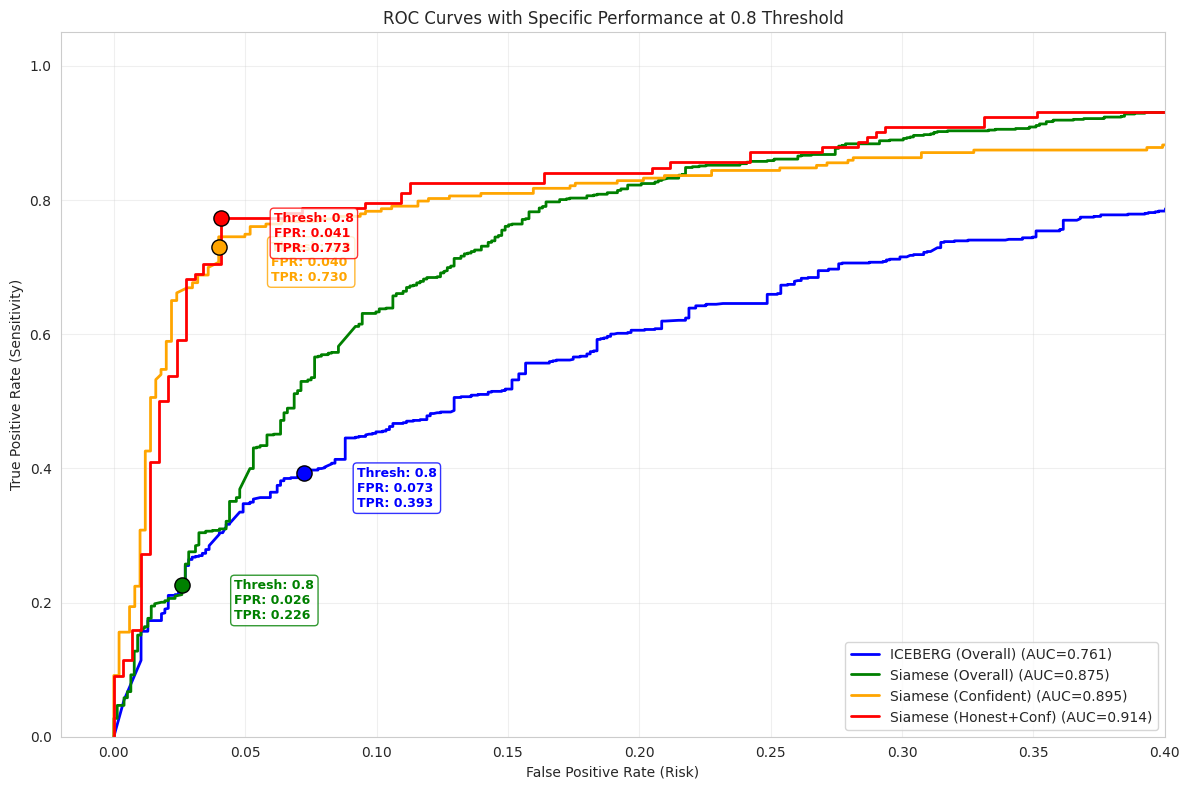

In [25]:
# --- 3. PLOTTING LOGIC ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

models = {
    "ICEBERG (Overall)": (df_ice['true_label'], df_ice['cosine_similarity'], 'blue'),
    "Siamese (Overall)": (df_sia['true_label'], df_sia['prob_similarity'], 'green'),
    "Siamese (Confident)": (df_sia_conf['true_label'], df_sia_conf['prob_similarity'], 'orange'),
    "Siamese (Honest+Conf)": (df_sia_h_conf['true_label'], df_sia_h_conf['prob_similarity'], 'red')
}

for name, (y_true, y_score, color) in models.items():
    # Calculate ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Draw Curve
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, lw=2)
    
    # --- IDENTIFY 0.8 POINT ---
    # Find the threshold index closest to 0.8
    idx = np.argmin(np.abs(thresholds - FIXED_THRESH))
    point_fpr = fpr[idx]
    point_tpr = tpr[idx]
    
    # Add Marker
    plt.scatter(point_fpr, point_tpr, color=color, s=120, edgecolors='black', zorder=10)
    
    # Add Annotation (Offset slightly for readability)
    plt.annotate(f"Thresh: {FIXED_THRESH}\nFPR: {point_fpr:.3f}\nTPR: {point_tpr:.3f}",
                 xy=(point_fpr, point_tpr),
                 xytext=(point_fpr + 0.02, point_tpr - 0.05),
                 fontsize=9, weight='bold', color=color,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

plt.xlim([-0.02, 0.4]) # Zoom into interesting region
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Risk)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curves with Specific Performance at {FIXED_THRESH} Threshold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Risk-Coverage Curves

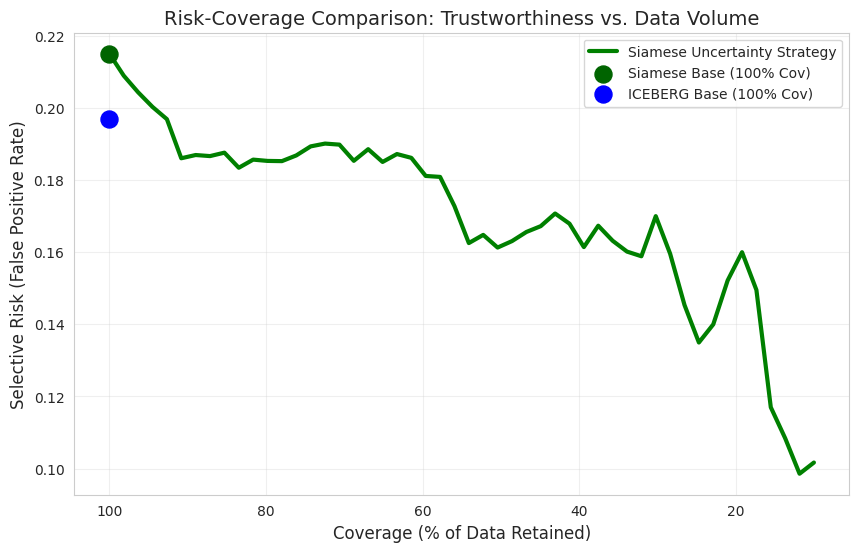

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SETTINGS ---
# We fix the classification threshold at 0.5 to measure "Risk"
CLASS_THRESH = 0.5 

def calculate_rc_curve(y_true, y_prob):
    """
    Calculates Selective Risk (FPR) vs Coverage.
    """
    # Define confidence as distance from the decision boundary (0.5)
    confidence = np.abs(y_prob - 0.5)
    sorted_indices = np.argsort(confidence)[::-1] # Most confident first
    
    coverages = []
    risks = [] # Selective FPR
    
    n_samples = len(y_true)
    # Step through coverage from 10% to 100%
    for percent in np.linspace(0.1, 1.0, 50):
        n_cutoff = int(percent * n_samples)
        top_idx = sorted_indices[:n_cutoff]
        
        y_t_sub = y_true[top_idx]
        y_p_sub = (y_prob[top_idx] >= CLASS_THRESH).astype(int)
        
        # Calculate Selective FPR (Risk)
        # FPR = FP / (FP + TN)
        fp = np.sum((y_p_sub == 1) & (y_t_sub == 0))
        tn = np.sum((y_p_sub == 0) & (y_t_sub == 0))
        
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        coverages.append(percent * 100)
        risks.append(fpr)
        
    return coverages, risks

# --- 2. CALCULATE ---
# Base Siamese (100% point)
sia_all_fpr = calculate_rc_curve(df_sia['true_label'].values, df_sia['prob_similarity'].values)[1][-1]

# ICEBERG (100% point)
ice_all_fpr = calculate_rc_curve(df_ice['true_label'].values, df_ice['cosine_similarity'].values)[1][-1]

# Siamese Uncertainty Curve
sia_cov, sia_risk = calculate_rc_curve(df_sia['true_label'].values, df_sia['prob_similarity'].values)

# --- 3. PLOTTING ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot the Uncertainty Curve
plt.plot(sia_cov, sia_risk, color='green', lw=3, label='Siamese Uncertainty Strategy')

# Plot the Baselines (100% Coverage Points)
plt.scatter([100], [sia_all_fpr], color='darkgreen', s=150, zorder=5, label='Siamese Base (100% Cov)')
plt.scatter([100], [ice_all_fpr], color='blue', s=150, zorder=5, label='ICEBERG Base (100% Cov)')

plt.gca().invert_xaxis() # Coverage decreases to the left
plt.xlabel('Coverage (% of Data Retained)', fontsize=12)
plt.ylabel('Selective Risk (False Positive Rate)', fontsize=12)
plt.title('Risk-Coverage Comparison: Trustworthiness vs. Data Volume', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Consistent Comparison across the models

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [28]:
# --- 1. DATA PREP ---
# Total Negatives/Positives in the ORIGINAL population (Constant Denominators)
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)
TOTAL_POS = np.sum(df_sia['true_label'] == 1)

def get_effective_metrics(y_true_subset, y_prob_subset):
    """
    Calculates FPR and TPR relative to the GLOBAL population denominators.
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true_subset, y_prob_subset)
    
    # Scale FPR/TPR to the Original Population
    # Effective FPR = (FPR_subset * Negatives_in_subset) / Total_Negatives_Global
    n_neg_subset = np.sum(y_true_subset == 0)
    n_pos_subset = np.sum(y_true_subset == 1)
    
    fpr_eff = (fpr_vals * n_neg_subset) / TOTAL_NEG
    tpr_eff = (tpr_vals * n_pos_subset) / TOTAL_POS
    
    return fpr_eff, tpr_eff

In [29]:
# --- 2. CALCULATE EFFECTIVE CURVES ---

# A. ICEBERG Base (FPR_eff == FPR_standard)
fpr_ice_eff, tpr_ice_eff = get_effective_metrics(df_ice['true_label'], df_ice['cosine_similarity'])

# B. Siamese Base
fpr_sia_eff, tpr_sia_eff = get_effective_metrics(df_sia['true_label'], df_sia['prob_similarity'])

# C. Siamese Confident (Selective)
mask_conf = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)
fpr_conf_eff, tpr_conf_eff = get_effective_metrics(df_sia[mask_conf]['true_label'], df_sia[mask_conf]['prob_similarity'])

# D. Siamese Honest + Confident (Selective)
mask_honest = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
fpr_hon_eff, tpr_hon_eff = get_effective_metrics(df_sia[mask_conf & mask_honest]['true_label'], df_sia[mask_conf & mask_honest]['prob_similarity'])

In [30]:
# --- 3. BENCHMARKING AT 5% FPR_eff ---
target = 0.05
tpr_ice_at_5 = np.interp(target, fpr_ice_eff, tpr_ice_eff)
tpr_sia_at_5 = np.interp(target, fpr_sia_eff, tpr_sia_eff)
tpr_conf_at_5 = np.interp(target, fpr_conf_eff, tpr_conf_eff)
tpr_hon_at_5 = np.interp(target, fpr_hon_eff, tpr_hon_eff)

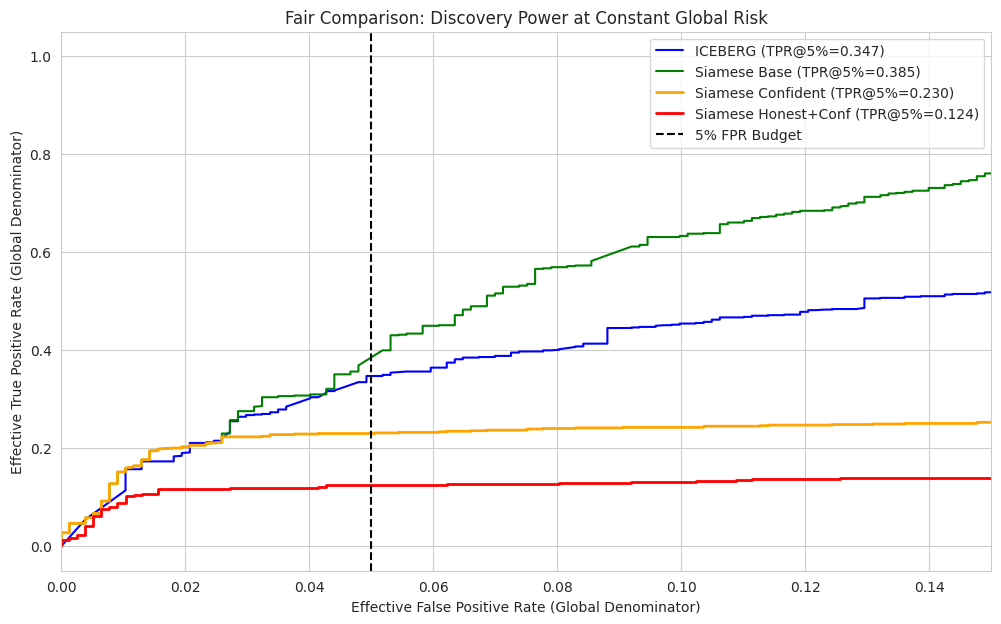

In [31]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(fpr_ice_eff, tpr_ice_eff, label=f'ICEBERG (TPR@5%={tpr_ice_at_5:.3f})', color='blue')
plt.plot(fpr_sia_eff, tpr_sia_eff, label=f'Siamese Base (TPR@5%={tpr_sia_at_5:.3f})', color='green')
plt.plot(fpr_conf_eff, tpr_conf_eff, label=f'Siamese Confident (TPR@5%={tpr_conf_at_5:.3f})', color='orange', lw=2)
plt.plot(fpr_hon_eff, tpr_hon_eff, label=f'Siamese Honest+Conf (TPR@5%={tpr_hon_at_5:.3f})', color='red', lw=2)

plt.axvline(x=target, color='black', linestyle='--', label='5% FPR Budget')
plt.xlim([0, 0.15]) # Focus on the low-error region
plt.xlabel('Effective False Positive Rate (Global Denominator)')
plt.ylabel('Effective True Positive Rate (Global Denominator)')
plt.title('Fair Comparison: Discovery Power at Constant Global Risk')
plt.legend()
plt.show()

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [33]:
# --- 1. DATA PREP ---
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)
TOTAL_POS = np.sum(df_sia['true_label'] == 1)

def get_effective_metrics(y_true_subset, y_prob_subset):
    """
    Returns effective FPR, TPR, and the original thresholds.
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true_subset, y_prob_subset)
    
    n_neg_subset = np.sum(y_true_subset == 0)
    n_pos_subset = np.sum(y_true_subset == 1)
    
    # Scale to Global Population
    fpr_eff = (fpr_vals * n_neg_subset) / TOTAL_NEG
    tpr_eff = (tpr_vals * n_pos_subset) / TOTAL_POS
    
    return fpr_eff, tpr_eff, thresholds

In [34]:
# --- 2. CALCULATE EFFECTIVE CURVES & THRESHOLDS ---
target_fpr = 0.05

# A. ICEBERG
f_ice, t_ice, th_ice = get_effective_metrics(df_ice['true_label'], df_ice['cosine_similarity'])
# B. Siamese Base
f_sia, t_sia, th_sia = get_effective_metrics(df_sia['true_label'], df_sia['prob_similarity'])
# C. Siamese Confident
mask_c = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)
f_conf, t_conf, th_conf = get_effective_metrics(df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'])
# D. Siamese Honest + Confident
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
f_hon, t_hon, th_hon = get_effective_metrics(df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'])

In [35]:
# --- 3. HELPER TO FIND POINT & THRESHOLD ---
def get_point_at_fpr(fpr_eff, tpr_eff, thresholds, target):
    idx = np.argmin(np.abs(fpr_eff - target))
    return fpr_eff[idx], tpr_eff[idx], thresholds[idx]

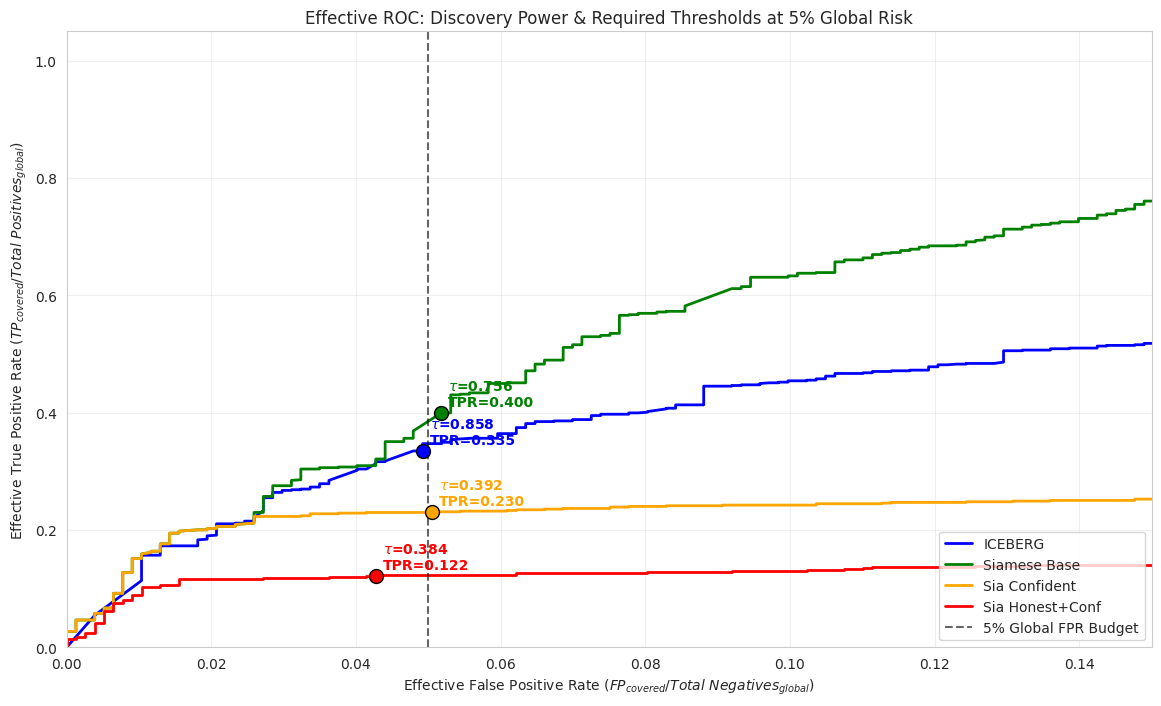

In [36]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(14, 8))

plot_configs = [
    (f_ice, t_ice, th_ice, 'blue', 'ICEBERG'),
    (f_sia, t_sia, th_sia, 'green', 'Siamese Base'),
    (f_conf, t_conf, th_conf, 'orange', 'Sia Confident'),
    (f_hon, t_hon, th_hon, 'red', 'Sia Honest+Conf')
]

for f, t, th, color, label in plot_configs:
    # 1. Plot the curve
    plt.plot(f, t, label=f'{label}', color=color, lw=2)
    
    # 2. Find the 5% FPR_eff point
    curr_f, curr_t, curr_th = get_point_at_fpr(f, t, th, target_fpr)
    
    # 3. Plot marker
    plt.scatter(curr_f, curr_t, color=color, s=100, edgecolors='black', zorder=5)
    
    # 4. Annotate with the threshold value
    # th > 1 are artifacts of roc_curve, cap them at 1.0 for similarity scores
    display_th = min(curr_th, 1.0) 
    plt.annotate(f"$\\tau$={display_th:.3f}\nTPR={curr_t:.3f}", 
                 xy=(curr_f, curr_t), 
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=10, weight='bold', color=color)

# Reference Line
plt.axvline(x=target_fpr, color='black', linestyle='--', alpha=0.6, label='5% Global FPR Budget')

plt.xlim([0, 0.15]) 
plt.ylim([0, 1.05])
plt.xlabel('Effective False Positive Rate ($FP_{covered} / Total\ Negatives_{global}$)')
plt.ylabel('Effective True Positive Rate ($TP_{covered} / Total\ Positives_{global}$)')
plt.title('Effective ROC: Discovery Power & Required Thresholds at 5% Global Risk')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [38]:
# --- 1. DATA PREP ---
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)

def get_effective_metrics(y_true_subset, y_prob_subset):
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true_subset, y_prob_subset)
    n_neg_subset = np.sum(y_true_subset == 0)
    fpr_eff = (fpr_vals * n_neg_subset) / TOTAL_NEG
    return fpr_eff, tpr_vals, thresholds

In [39]:
# --- 2. CALCULATE DATA ---
target_fpr = 0.05

# Base Siamese (The Reference)
f_sia, t_sia, th_sia = get_effective_metrics(df_sia['true_label'], df_sia['prob_similarity'])

# Find the threshold tau where Base Siamese hits 5% FPR_eff
idx_sia = np.argmin(np.abs(f_sia - target_fpr))
base_tau = th_sia[idx_sia]

# Now evaluate other models at this EXACT same tau
def get_metrics_at_fixed_threshold(y_true, y_prob, fixed_tau, is_iceberg=False):
    # Apply label based on fixed_tau
    y_pred = (y_prob >= fixed_tau).astype(int)
    
    # Calculate FP relative to global negatives
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tp = np.sum((y_pred == 1) & (y_true == 1))
    
    fpr_eff = fp / TOTAL_NEG
    tpr_eff = tp / np.sum(df_sia['true_label'] == 1)
    return fpr_eff, tpr_eff

# Define masks
mask_c = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)

# Calculate points
res_ice = get_metrics_at_fixed_threshold(df_ice['true_label'], df_ice['cosine_similarity'], base_tau)
res_sia = (target_fpr, t_sia[idx_sia]) # Already calculated
res_conf = get_metrics_at_fixed_threshold(df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'], base_tau)
res_hon = get_metrics_at_fixed_threshold(df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'], base_tau)

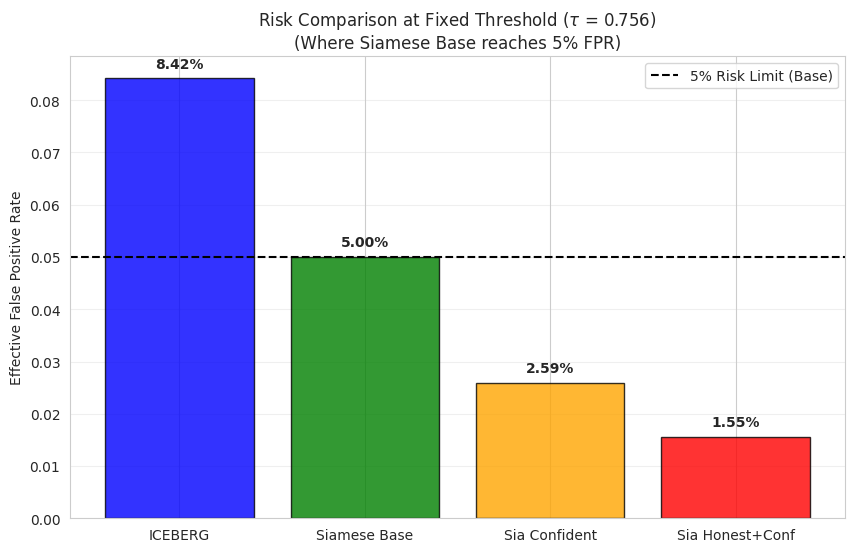

In [40]:
# --- 3. VISUALIZATION ---
plt.figure(figsize=(10, 6))
labels = ['ICEBERG', 'Siamese Base', 'Sia Confident', 'Sia Honest+Conf']
fprs = [res_ice[0], res_sia[0], res_conf[0], res_hon[0]]
colors = ['blue', 'green', 'orange', 'red']

plt.bar(labels, fprs, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(y=target_fpr, color='black', linestyle='--', label='5% Risk Limit (Base)')

# Annotations
for i, v in enumerate(fprs):
    plt.text(i, v + 0.002, f'{v:.2%}', ha='center', weight='bold')

plt.ylabel('Effective False Positive Rate')
plt.title(f'Risk Comparison at Fixed Threshold ($\\tau$ = {base_tau:.3f})\n(Where Siamese Base reaches 5% FPR)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

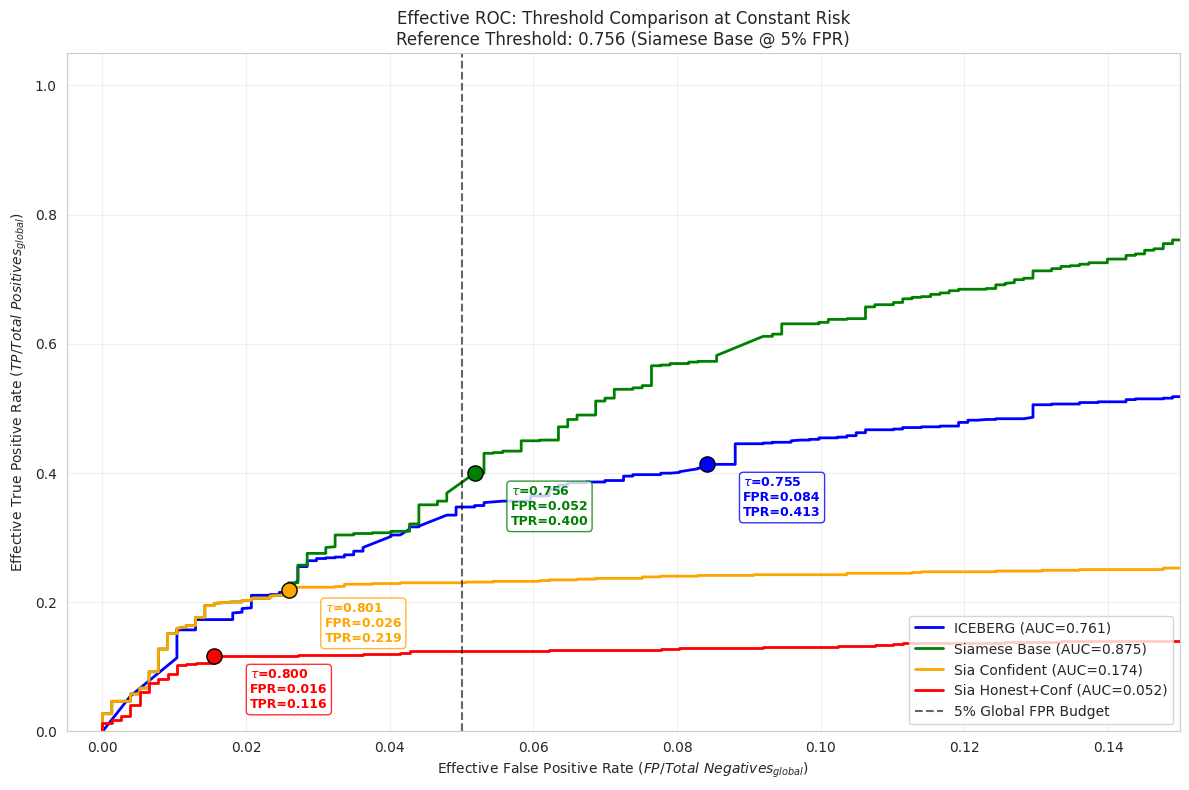

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. CONFIGURATION ---
# Using the paths provided in your environment
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR_GLOBAL = 0.05

# --- 2. LOAD & ENRICH ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# Precursor mass enrichment for Honest Zone
df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

# Calculate Global Denominators (Constant across all comparisons)
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)
TOTAL_POS = np.sum(df_sia['true_label'] == 1)

def get_effective_metrics(y_true_subset, y_prob_subset):
    """
    Calculates FPR and TPR relative to the GLOBAL population denominators.
    Returns: fpr_eff, tpr_eff, thresholds
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true_subset, y_prob_subset)
    
    n_neg_subset = np.sum(y_true_subset == 0)
    n_pos_subset = np.sum(y_true_subset == 1)
    
    # Scale FPR/TPR to the Original Total Population
    fpr_eff = (fpr_vals * n_neg_subset) / TOTAL_NEG
    tpr_eff = (tpr_vals * n_pos_subset) / TOTAL_POS
    
    return fpr_eff, tpr_eff, thresholds

# --- 3. CALCULATE EFFECTIVE CURVES ---
# A. ICEBERG Base
f_ice, t_ice, th_ice = get_effective_metrics(df_ice['true_label'], df_ice['cosine_similarity'])

# B. Siamese Base
f_sia, t_sia, th_sia = get_effective_metrics(df_sia['true_label'], df_sia['prob_similarity'])

# Identify the Reference Threshold (tau) where Siamese Base hits 5% FPR_eff
idx_target = np.argmin(np.abs(f_sia - TARGET_FPR_GLOBAL))
ref_tau = th_sia[idx_target]

# C. Siamese Confident (Selective)
mask_c = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)
f_conf, t_conf, th_conf = get_effective_metrics(df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'])

# D. Siamese Honest + Confident (Selective)
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)
f_hon, t_hon, th_hon = get_effective_metrics(df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'])

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Configuration for plotting each line and its marker
plot_data = [
    (f_ice, t_ice, th_ice, 'blue', 'ICEBERG'),
    (f_sia, t_sia, th_sia, 'green', 'Siamese Base'),
    (f_conf, t_conf, th_conf, 'orange', 'Sia Confident'),
    (f_hon, t_hon, th_hon, 'red', 'Sia Honest+Conf')
]

for f_eff, t_eff, thresholds, color, label in plot_data:
    # 1. Plot the ROC Curve
    plt.plot(f_eff, t_eff, label=f'{label} (AUC={auc(f_eff, t_eff):.3f})', color=color, lw=2)
    
    # 2. Find the coordinate on this curve closest to our reference threshold (ref_tau)
    idx_tau = np.argmin(np.abs(thresholds - ref_tau))
    pt_f = f_eff[idx_tau]
    pt_t = t_eff[idx_tau]
    
    # 3. Plot a point marker
    plt.scatter(pt_f, pt_t, color=color, s=120, edgecolors='black', zorder=10)
    
    # 4. Add Label for the Threshold and current values
    # (Cap threshold at 1.0 for display if needed)
    display_tau = min(thresholds[idx_tau], 1.0)
    plt.annotate(f"$\\tau$={display_tau:.3f}\nFPR={pt_f:.3f}\nTPR={pt_t:.3f}", 
                 xy=(pt_f, pt_t), 
                 xytext=(pt_f + 0.005, pt_t - 0.08),
                 fontsize=9, weight='bold', color=color,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

# Add Global 5% FPR reference line
plt.axvline(x=TARGET_FPR_GLOBAL, color='black', linestyle='--', alpha=0.6, label='5% Global FPR Budget')

plt.xlim([-0.005, 0.15]) # Zoom in on the high-trust region
plt.ylim([0, 1.05])
plt.xlabel('Effective False Positive Rate ($FP / Total\ Negatives_{global}$)')
plt.ylabel('Effective True Positive Rate ($TP / Total\ Positives_{global}$)')
plt.title(f'Effective ROC: Threshold Comparison at Constant Risk\nReference Threshold: {ref_tau:.3f} (Siamese Base @ 5% FPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

--- Global Population Baseline ---
Total Negatives (N): 772
Total Positives (P): 878
FPR Budget (5%): 38 allowed errors



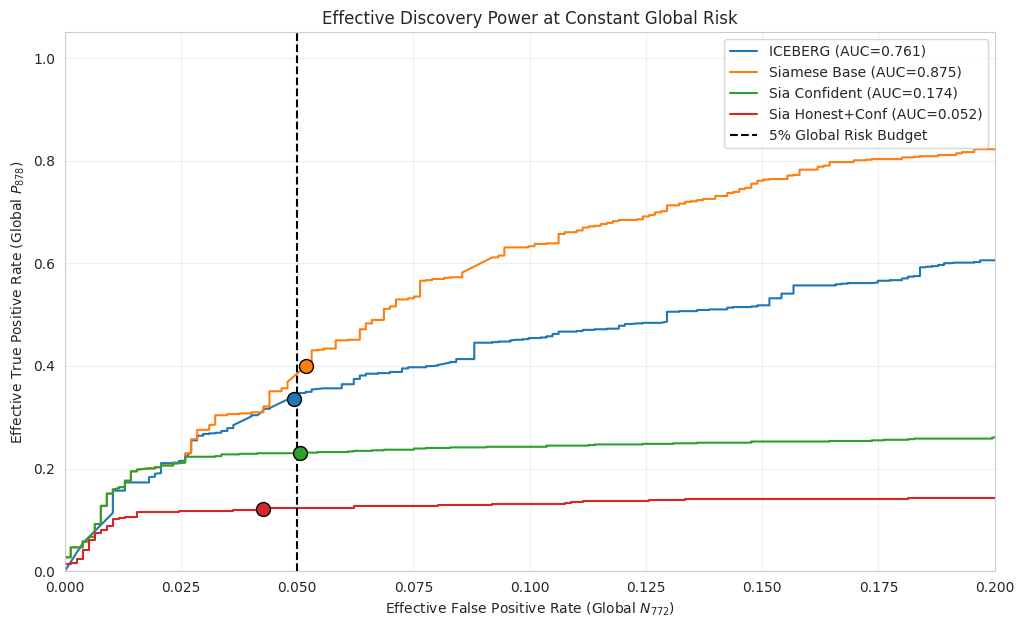

            FAIR PERFORMANCE SUMMARY (CONSTANT GLOBAL DENOMINATORS)             
          Model  Threshold  TP (Found)  FP (Errors)  TN (Safe)  FN (Missed)  Eff_TPR  Samples_Analyzed
        ICEBERG     0.8582         294           38        734          584   0.3349              1650
   Siamese Base     0.7560         351           40        732          527   0.3998              1650
  Sia Confident     0.3922         202           39        733          676   0.2301               764
Sia Honest+Conf     0.3838         107           33        739          771   0.1219               425


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# --- 1. CONFIGURATION ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR_GLOBAL = 0.05
CONF_LOW, CONF_HIGH = 0.4, 0.8

# --- 2. LOAD DATA ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# --- 3. DYNAMIC GLOBAL COUNTS ---
# We extract the ground truth from the main Siamese testing set
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
TOTAL_SAMPLES = len(df_sia)

print(f"--- Global Population Baseline ---")
print(f"Total Negatives (N): {TOTAL_NEG_GLOBAL}")
print(f"Total Positives (P): {TOTAL_POS_GLOBAL}")
print(f"FPR Budget (5%): {int(TARGET_FPR_GLOBAL * TOTAL_NEG_GLOBAL)} allowed errors\n")

# --- 4. ENRICHMENT & SUBSETS ---
df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

mask_c = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)

models = {
    "ICEBERG": (df_ice['true_label'], df_ice['cosine_similarity']),
    "Siamese Base": (df_sia['true_label'], df_sia['prob_similarity']),
    "Sia Confident": (df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity']),
    "Sia Honest+Conf": (df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'])
}

# --- 5. CALCULATION & FAIR COMPARISON ---
summary_data = []
plt.figure(figsize=(12, 7))

for name, (y_true_sub, y_prob_sub) in models.items():
    # A. Get standard ROC data for the subset
    fpr_sub, tpr_sub, thresholds = roc_curve(y_true_sub, y_prob_sub)
    
    # B. Calculate EFFECTIVE metrics (Using GLOBAL Denominators)
    n_neg_sub = np.sum(y_true_sub == 0)
    n_pos_sub = np.sum(y_true_sub == 1)
    
    fpr_eff = (fpr_sub * n_neg_sub) / TOTAL_NEG_GLOBAL
    tpr_eff = (tpr_sub * n_pos_sub) / TOTAL_POS_GLOBAL
    
    # C. Find Performance at 5% Global Risk
    idx = np.argmin(np.abs(fpr_eff - TARGET_FPR_GLOBAL))
    best_tau = thresholds[idx]
    
    # Calculate raw counts at this threshold
    y_pred = (y_prob_sub >= best_tau).astype(int)
    tp = np.sum((y_pred == 1) & (y_true_sub == 1))
    fp = np.sum((y_pred == 1) & (y_true_sub == 0))
    
    summary_data.append({
        "Model": name,
        "Threshold": round(best_tau, 4),
        "TP (Found)": tp,
        "FP (Errors)": fp,
        "TN (Safe)": TOTAL_NEG_GLOBAL - fp, # Fair comparison: Negatives not called FP
        "FN (Missed)": TOTAL_POS_GLOBAL - tp, # Fair comparison: Positives not found
        "Eff_TPR": round(tp / TOTAL_POS_GLOBAL, 4),
        "Samples_Analyzed": len(y_true_sub)
    })
    
    # D. Plot Effective ROC
    plt.plot(fpr_eff, tpr_eff, label=f"{name} (AUC={auc(fpr_eff, tpr_eff):.3f})")
    plt.scatter([fpr_eff[idx]], [tpr_eff[idx]], s=100, edgecolors='black', zorder=5)

# --- 6. VISUALIZATION FINALIZING ---
plt.axvline(x=TARGET_FPR_GLOBAL, color='black', linestyle='--', label='5% Global Risk Budget')
plt.xlim([0, 0.20])
plt.ylim([0, 1.05])
plt.xlabel('Effective False Positive Rate (Global $N_{772}$)')
plt.ylabel('Effective True Positive Rate (Global $P_{878}$)')
plt.title('Effective Discovery Power at Constant Global Risk')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 7. FINAL TABLE ---
print("="*80)
print(f"{'FAIR PERFORMANCE SUMMARY (CONSTANT GLOBAL DENOMINATORS)':^80}")
print("="*80)
print(pd.DataFrame(summary_data).to_string(index=False))

In [46]:
import pandas as pd
import numpy as np

# --- 1. CONFIGURATION ---
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
FIXED_TAU = 0.7560
CONF_LOW, CONF_HIGH = 0.4, 0.8

# --- 2. LOAD DATA & GLOBAL BASELINE ---
df_sia = pd.read_csv(SIAMESE_PATH)
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)

# --- 3. APPLY CONFIDENCE FILTER ---
mask_c = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
df_conf = df_sia[mask_c].copy()

# --- 4. CALCULATE METRICS AT FIXED THRESHOLD ---
# Apply the 0.7560 decision boundary
df_conf['pred_label'] = (df_conf['prob_similarity'] >= FIXED_TAU).astype(int)

# Raw Counts within the confident subset
tp = np.sum((df_conf['pred_label'] == 1) & (df_conf['true_label'] == 1))
fp = np.sum((df_conf['pred_label'] == 1) & (df_conf['true_label'] == 0))

# "Effective" counts relative to total population
# Note: Any negative not called a 1 is a "Safe" result
tn_eff = TOTAL_NEG_GLOBAL - fp
# Any positive not called a 1 is a "Missed" result
fn_eff = TOTAL_POS_GLOBAL - tp

# --- 5. RESULTS ---
results = {
    "Model": "Siamese Confident",
    "Fixed Threshold (\u03c4)": FIXED_TAU,
    "Confident Pairs Analyzed": len(df_conf),
    "Pairs Dropped (Uncertain)": len(df_sia) - len(df_conf),
    "TP (Found)": int(tp),
    "FP (Actual Errors)": int(fp),
    "TN (Safe)": int(tn_eff),
    "FN (Missed)": int(fn_eff),
    "Effective FPR": f"{fp / TOTAL_NEG_GLOBAL:.2%}",
    "Effective TPR": f"{tp / TOTAL_POS_GLOBAL:.2%}",
    "Precision (Hit Rate)": f"{tp / (tp + fp):.2%}" if (tp + fp) > 0 else "0%"
}

print("="*50)
print(f"{'CONFIDENT MODEL PERFORMANCE AT FIXED THRESHOLD':^50}")
print("="*50)
for k, v in results.items():
    print(f"{k:<25}: {v}")

  CONFIDENT MODEL PERFORMANCE AT FIXED THRESHOLD  
Model                    : Siamese Confident
Fixed Threshold (τ)      : 0.756
Confident Pairs Analyzed : 764
Pairs Dropped (Uncertain): 886
TP (Found)               : 195
FP (Actual Errors)       : 20
TN (Safe)                : 752
FN (Missed)              : 683
Effective FPR            : 2.59%
Effective TPR            : 22.21%
Precision (Hit Rate)     : 90.70%


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve

# --- 1. CONFIGURATION ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR = 0.05
CONF_LOW, CONF_HIGH = 0.4, 0.8

# --- 2. LOAD & ENRICH (Fixes the KeyError) ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# Map masses and calculate difference for the Siamese dataframe
df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

# --- 3. GLOBAL BASELINE ---
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)

def get_confusion_data(y_true_sub, y_prob_sub, name):
    # Calculate ROC to find the specific threshold for 5% Global FPR
    fpr, tpr, thresholds = roc_curve(y_true_sub, y_prob_sub)
    
    # Scaling FPR to the Global Denominator
    n_neg_sub = np.sum(y_true_sub == 0)
    fpr_eff = (fpr * n_neg_sub) / TOTAL_NEG_GLOBAL
    
    # Identify threshold (tau) closest to 5% global risk
    idx = np.argmin(np.abs(fpr_eff - TARGET_FPR))
    tau = thresholds[idx]
    
    # Calculate counts within the subset
    y_pred = (y_prob_sub >= tau).astype(int)
    tp_subset = np.sum((y_pred == 1) & (y_true_sub == 1))
    fp_subset = np.sum((y_pred == 1) & (y_true_sub == 0))
    
    # FAIR GLOBAL ACCOUNTING
    tp_final = int(tp_subset)
    fp_final = int(fp_subset)
    tn_final = int(TOTAL_NEG_GLOBAL - fp_final)
    fn_final = int(TOTAL_POS_GLOBAL - tp_final)
    
    return {
        "Model": name,
        "Threshold": round(tau, 4),
        "TP": tp_final,
        "FP": fp_final,
        "TN": tn_final,
        "FN": fn_final
    }

# --- 4. RUN FOR ALL MODELS ---
mask_c = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)

models_to_run = [
    (df_ice['true_label'], df_ice['cosine_similarity'], "ICEBERG"),
    (df_sia['true_label'], df_sia['prob_similarity'], "Siamese Base"),
    (df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'], "Sia Confident"),
    (df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'], "Sia Honest+Conf")
]

results = [get_confusion_data(*m) for m in models_to_run]

# --- 5. PRINT MATRICES ---
print(f"Global Baseline: Negatives (N)={TOTAL_NEG_GLOBAL}, Positives (P)={TOTAL_POS_GLOBAL}")
print("-" * 65)

for res in results:
    print(f"\nModel: {res['Model']} (Threshold: {res['Threshold']})")
    print(f"{'':<15} | {'Pred: Pos':<10} | {'Pred: Neg':<10} |")
    print("-" * 55)
    print(f"{'Actual: Pos':<15} | {res['TP']:<10} | {res['FN']:<10} |")
    print(f"{'Actual: Neg':<15} | {res['FP']:<10} | {res['TN']:<10} |")
    precision = res['TP']/(res['TP']+res['FP']) if (res['TP']+res['FP']) > 0 else 0
    print(f"Precision: {precision:.2%}")

Global Baseline: Negatives (N)=772, Positives (P)=878
-----------------------------------------------------------------

Model: ICEBERG (Threshold: 0.8582)
                | Pred: Pos  | Pred: Neg  |
-------------------------------------------------------
Actual: Pos     | 294        | 584        |
Actual: Neg     | 38         | 734        |
Precision: 88.55%

Model: Siamese Base (Threshold: 0.756)
                | Pred: Pos  | Pred: Neg  |
-------------------------------------------------------
Actual: Pos     | 351        | 527        |
Actual: Neg     | 40         | 732        |
Precision: 89.77%

Model: Sia Confident (Threshold: 0.3922)
                | Pred: Pos  | Pred: Neg  |
-------------------------------------------------------
Actual: Pos     | 202        | 676        |
Actual: Neg     | 39         | 733        |
Precision: 83.82%

Model: Sia Honest+Conf (Threshold: 0.3838)
                | Pred: Pos  | Pred: Neg  |
-------------------------------------------------------


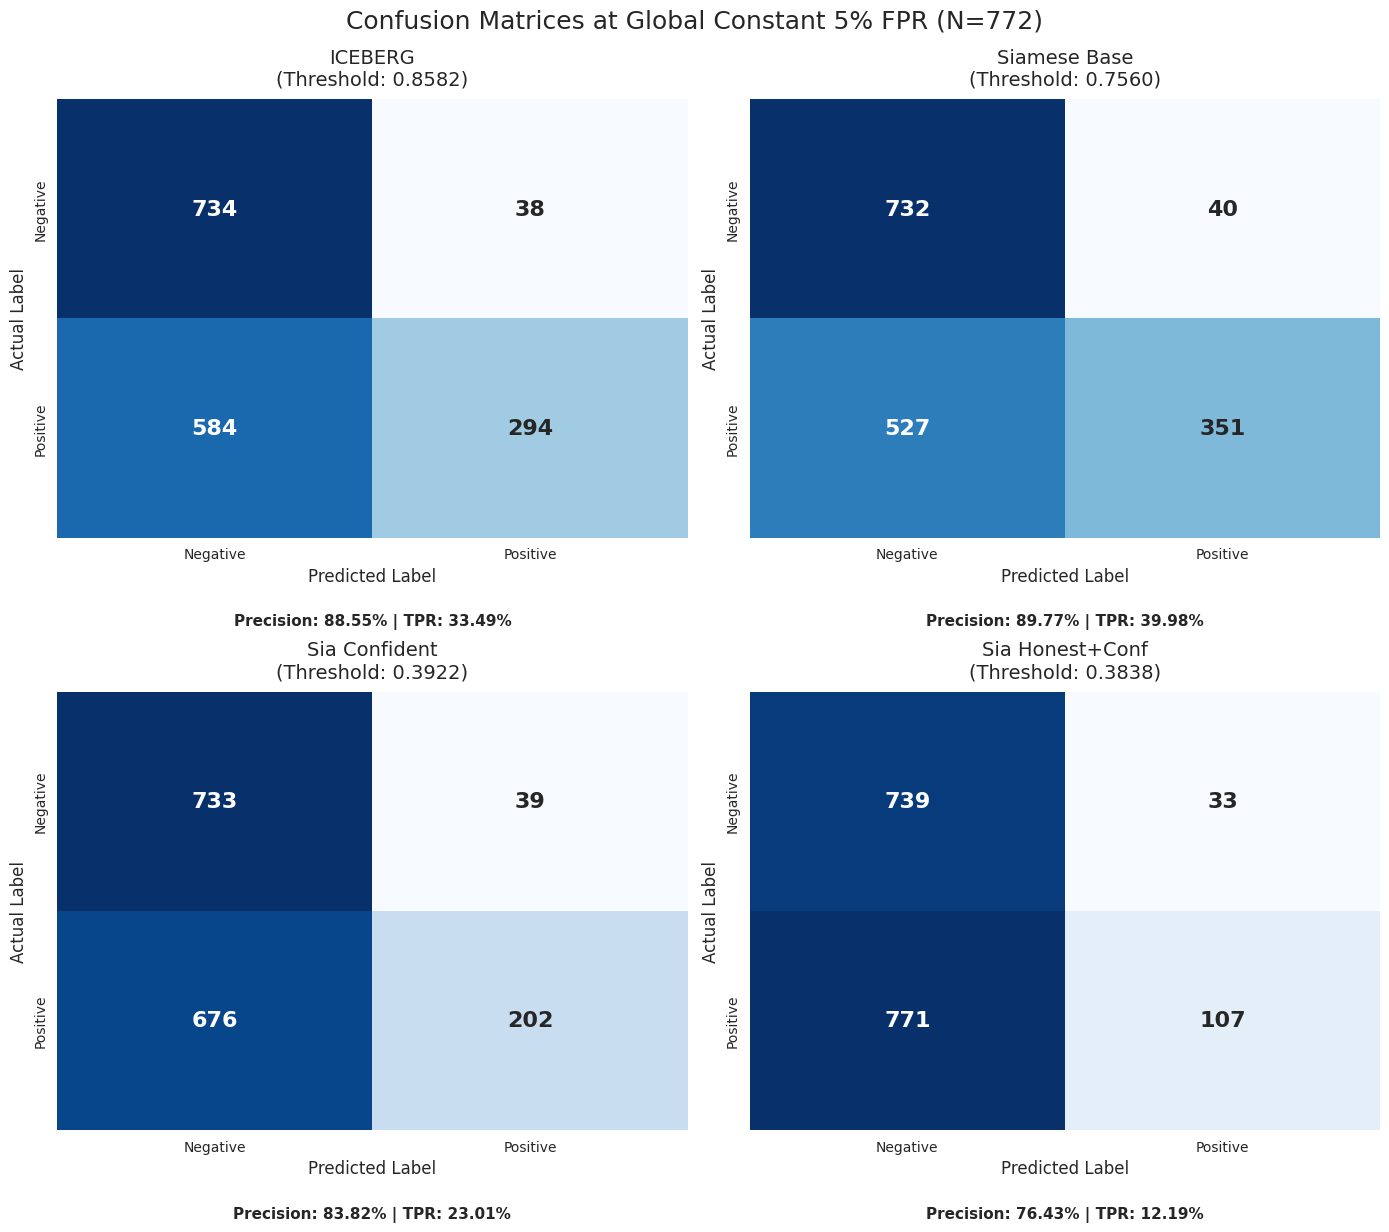

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# --- 1. SETUP & DATA ENRICHMENT ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/nist_filtered/results_stratified_binary_07_unseen_nist.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR = 0.05
CONF_LOW, CONF_HIGH = 0.4, 0.8

df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

df_sia['mz_main'] = df_sia['name_main'].map(spec_df['prec_mz'])
df_sia['mz_sub'] = df_sia['name_sub'].map(spec_df['prec_mz'])
df_sia['mass_diff'] = (df_sia['mz_main'] - df_sia['mz_sub']).abs()

TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)

def get_cm_data(y_true_sub, y_prob_sub):
    fpr, tpr, thresholds = roc_curve(y_true_sub, y_prob_sub)
    n_neg_sub = np.sum(y_true_sub == 0)
    fpr_eff = (fpr * n_neg_sub) / TOTAL_NEG_GLOBAL
    
    idx = np.argmin(np.abs(fpr_eff - TARGET_FPR))
    tau = thresholds[idx]
    
    y_pred = (y_prob_sub >= tau).astype(int)
    tp = int(np.sum((y_pred == 1) & (y_true_sub == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true_sub == 0)))
    
    # Global accounting
    tn = int(TOTAL_NEG_GLOBAL - fp)
    fn = int(TOTAL_POS_GLOBAL - tp)
    
    # Return as matrix: [[TN, FP], [FN, TP]]
    return np.array([[tn, fp], [fn, tp]]), tau

# --- 2. GENERATE MATRICES ---
mask_c = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
mask_h = (df_sia['mass_diff'] >= 1.0) & (df_sia['mass_diff'] < 100.0)

models_to_plot = [
    (df_ice['true_label'], df_ice['cosine_similarity'], "ICEBERG"),
    (df_sia['true_label'], df_sia['prob_similarity'], "Siamese Base"),
    (df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'], "Sia Confident"),
    (df_sia[mask_c & mask_h]['true_label'], df_sia[mask_c & mask_h]['prob_similarity'], "Sia Honest+Conf")
]

# --- 3. PLOTTING GRID ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (y_t, y_p, name) in enumerate(models_to_plot):
    cm, tau = get_cm_data(y_t, y_p)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 16, "weight": "bold"})
    
    axes[i].set_title(f"{name}\n(Threshold: {tau:.4f})", fontsize=14, pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('Actual Label', fontsize=12)
    axes[i].set_xticklabels(['Negative', 'Positive'])
    axes[i].set_yticklabels(['Negative', 'Positive'])
    
    # Calculate Precision and TPR for the subplot
    prec = cm[1,1] / (cm[1,1] + cm[0,1])
    tpr = cm[1,1] / (cm[1,0] + cm[1,1])
    axes[i].text(0.5, -0.2, f"Precision: {prec:.2%} | TPR: {tpr:.2%}", 
                 ha='center', transform=axes[i].transAxes, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.suptitle(f"Confusion Matrices at Global Constant 5% FPR (N={TOTAL_NEG_GLOBAL})", fontsize=18, y=1.02)
plt.show()

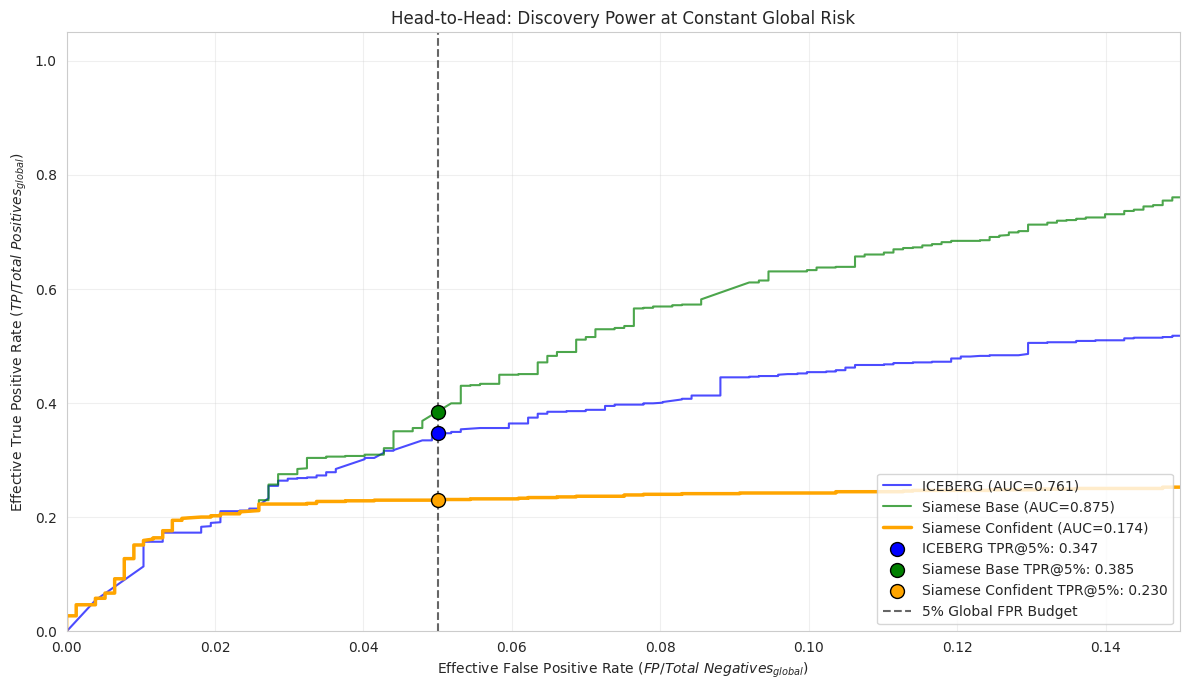

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. DATA PREP & GLOBAL BASELINES ---
# Extract ground truth counts from the original Siamese test set
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)
TOTAL_POS = np.sum(df_sia['true_label'] == 1)

def get_effective_metrics(y_true_subset, y_prob_subset):
    """
    Calculates FPR and TPR relative to the GLOBAL population denominators.
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true_subset, y_prob_subset)
    
    n_neg_subset = np.sum(y_true_subset == 0)
    n_pos_subset = np.sum(y_true_subset == 1)
    
    # Scale FPR/TPR to the Original Population (Fair Comparison)
    fpr_eff = (fpr_vals * n_neg_subset) / TOTAL_NEG
    tpr_eff = (tpr_vals * n_pos_subset) / TOTAL_POS
    
    return fpr_eff, tpr_eff

# --- 2. CALCULATE EFFECTIVE CURVES ---

# A. ICEBERG Base
fpr_ice_eff, tpr_ice_eff = get_effective_metrics(df_ice['true_label'], df_ice['cosine_similarity'])

# B. Siamese Base
fpr_sia_eff, tpr_sia_eff = get_effective_metrics(df_sia['true_label'], df_sia['prob_similarity'])

# C. Siamese Confident (Selective Filter: <0.4 or >0.8)
mask_conf = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.8)
fpr_conf_eff, tpr_conf_eff = get_effective_metrics(df_sia[mask_conf]['true_label'], df_sia[mask_conf]['prob_similarity'])

# --- 3. BENCHMARKING AT 5% GLOBAL FPR ---
target_fpr = 0.05
tpr_ice_at_5 = np.interp(target_fpr, fpr_ice_eff, tpr_ice_eff)
tpr_sia_at_5 = np.interp(target_fpr, fpr_sia_eff, tpr_sia_eff)
tpr_conf_at_5 = np.interp(target_fpr, fpr_conf_eff, tpr_conf_eff)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 7))

# Plot Curves
plt.plot(fpr_ice_eff, tpr_ice_eff, label=f'ICEBERG (AUC={auc(fpr_ice_eff, tpr_ice_eff):.3f})', color='blue', alpha=0.7)
plt.plot(fpr_sia_eff, tpr_sia_eff, label=f'Siamese Base (AUC={auc(fpr_sia_eff, tpr_sia_eff):.3f})', color='green', alpha=0.7)
plt.plot(fpr_conf_eff, tpr_conf_eff, label=f'Siamese Confident (AUC={auc(fpr_conf_eff, tpr_conf_eff):.3f})', color='orange', lw=2.5)

# Plot TPR Markers at 5% FPR
plt.scatter([target_fpr], [tpr_ice_at_5], color='blue', s=100, edgecolors='black', zorder=5, 
            label=f'ICEBERG TPR@5%: {tpr_ice_at_5:.3f}')
plt.scatter([target_fpr], [tpr_sia_at_5], color='green', s=100, edgecolors='black', zorder=5, 
            label=f'Siamese Base TPR@5%: {tpr_sia_at_5:.3f}')
plt.scatter([target_fpr], [tpr_conf_at_5], color='orange', s=100, edgecolors='black', zorder=5, 
            label=f'Siamese Confident TPR@5%: {tpr_conf_at_5:.3f}')

# Reference Line for Error Budget
plt.axvline(x=target_fpr, color='black', linestyle='--', alpha=0.6, label='5% Global FPR Budget')

plt.xlim([0, 0.15]) # Zoom into the high-specificity region
plt.ylim([0, 1.05])
plt.xlabel('Effective False Positive Rate ($FP / Total\ Negatives_{global}$)')
plt.ylabel('Effective True Positive Rate ($TP / Total\ Positives_{global}$)')
plt.title('Head-to-Head: Discovery Power at Constant Global Risk')
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

            Model  Threshold  TP  FP  Selective Precision  Recall (Discovery)  Coverage
          ICEBERG     0.8582 294  38               0.8855              0.3349    1.0000
     Siamese Base     0.9947 174  39               0.8169              0.1982    1.0000
Siamese Confident     0.9947 174  39               0.8169              0.1982    0.9279


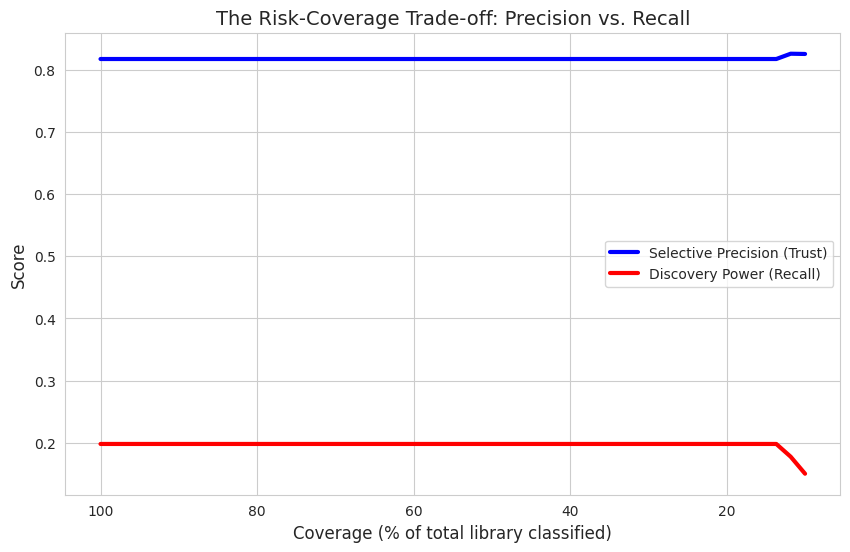

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# --- 1. CONFIGURATION & DATA LOADING ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/binary_class.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

TARGET_FPR_GLOBAL = 0.05
CONF_LOW, CONF_HIGH = 0.4, 0.8

df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# Dynamic Global Denominators
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
TOTAL_SAMPLES = len(df_sia)

# --- 2. CALCULATING GLOBAL vs. SELECTIVE PRECISION ---
def get_diagnostics(y_true_sub, y_prob_sub, name, total_global_neg, total_global_pos):
    # Find threshold for 5% Global FPR
    fpr, tpr, thresholds = roc_curve(y_true_sub, y_prob_sub)
    n_neg_sub = np.sum(y_true_sub == 0)
    fpr_eff = (fpr * n_neg_sub) / total_global_neg
    
    idx = np.argmin(np.abs(fpr_eff - TARGET_FPR_GLOBAL))
    tau = thresholds[idx]
    
    # Predictions at this threshold
    y_pred = (y_prob_sub >= tau).astype(int)
    tp = np.sum((y_pred == 1) & (y_true_sub == 1))
    fp = np.sum((y_pred == 1) & (y_true_sub == 0))
    
    # Metrics
    prec_selective = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_eff = tp / total_global_pos
    coverage = len(y_true_sub) / TOTAL_SAMPLES
    
    return {
        "Model": name,
        "Threshold": round(tau, 4),
        "TP": int(tp),
        "FP": int(fp),
        "Selective Precision": round(prec_selective, 4),
        "Recall (Discovery)": round(recall_eff, 4),
        "Coverage": round(coverage, 4)
    }

# Subsets
mask_c = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)

results = [
    get_diagnostics(df_ice['true_label'], df_ice['cosine_similarity'], "ICEBERG", TOTAL_NEG_GLOBAL, TOTAL_POS_GLOBAL),
    get_diagnostics(df_sia['true_label'], df_sia['prob_similarity'], "Siamese Base", TOTAL_NEG_GLOBAL, TOTAL_POS_GLOBAL),
    get_diagnostics(df_sia[mask_c]['true_label'], df_sia[mask_c]['prob_similarity'], "Siamese Confident", TOTAL_NEG_GLOBAL, TOTAL_POS_GLOBAL)
]

# --- 3. RISK-COVERAGE CURVE (The Justification) ---
# Vary coverage by changing the 'uncertainty' rejection width
df_sia['confidence'] = np.abs(df_sia['prob_similarity'] - 0.5)
sorted_sia = df_sia.sort_values('confidence', ascending=False)

coverage_sweep = []
for p in np.linspace(0.1, 1.0, 50):
    n_kept = int(p * TOTAL_SAMPLES)
    subset = sorted_sia.iloc[:n_kept]
    
    # Recalculate best precision at the 5% Global Risk limit
    fpr_s, tpr_s, th_s = roc_curve(subset['true_label'], subset['prob_similarity'])
    n_neg_s = np.sum(subset['true_label'] == 0)
    fpr_eff_s = (fpr_s * n_neg_s) / TOTAL_NEG_GLOBAL
    
    idx_s = np.argmin(np.abs(fpr_eff_s - TARGET_FPR_GLOBAL))
    tau_s = th_s[idx_s]
    
    y_p_s = (subset['prob_similarity'] >= tau_s).astype(int)
    tp_s = np.sum((y_p_s == 1) & (subset['true_label'] == 1))
    fp_s = np.sum((y_p_s == 1) & (subset['true_label'] == 0))
    
    coverage_sweep.append({
        'Coverage': p,
        'Precision': tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0,
        'Recall': tp_s / TOTAL_POS_GLOBAL
    })

df_rc = pd.DataFrame(coverage_sweep)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plt.plot(df_rc['Coverage']*100, df_rc['Precision'], color='blue', lw=3, label='Selective Precision (Trust)')
plt.plot(df_rc['Coverage']*100, df_rc['Recall'], color='red', lw=3, label='Discovery Power (Recall)')

plt.xlabel('Coverage (% of total library classified)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('The Risk-Coverage Trade-off: Precision vs. Recall', fontsize=14)
plt.gca().invert_xaxis() # Move from 100% (Base) to 10% (Hyper-selective)
plt.legend()
plt.savefig('precision_recall_coverage_tradeoff.png')

print(pd.DataFrame(results).to_string(index=False))

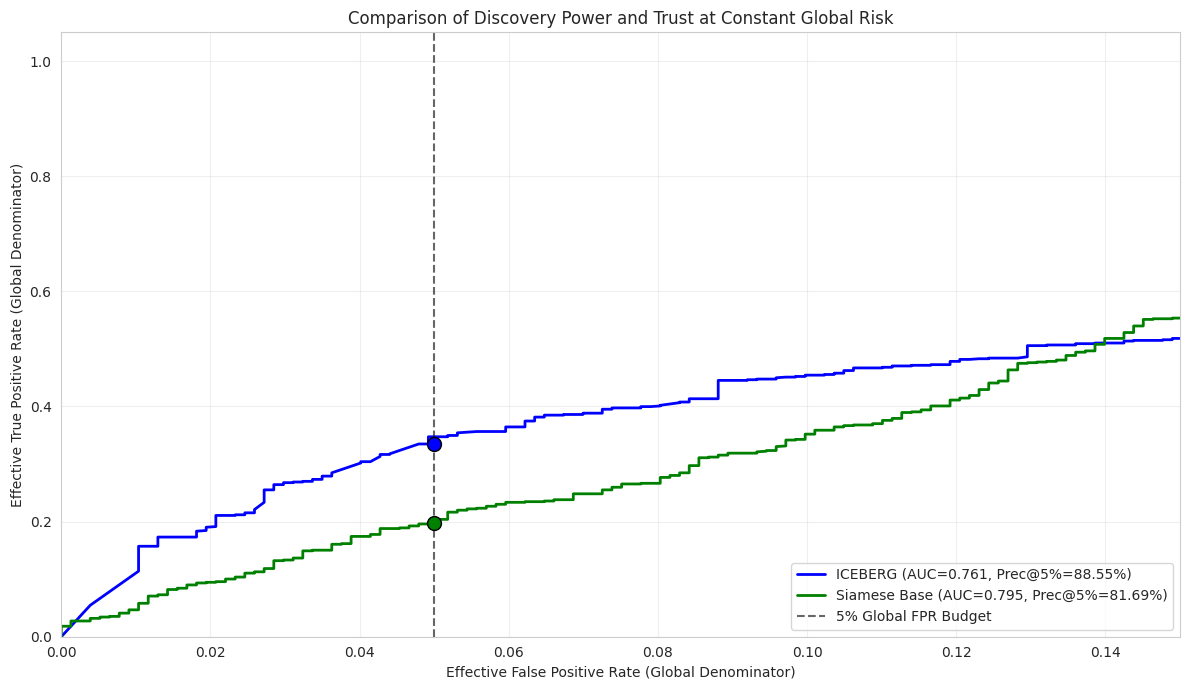

        name  auc_eff  tau_at_5  prec_at_5  tpr_at_5
     ICEBERG 0.761239  0.858198   0.885542  0.334852
Siamese Base 0.794572  0.994731   0.816901  0.198178


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. DATA PREP & GLOBAL BASELINES ---
# Extract ground truth counts from the original Siamese test set
TOTAL_NEG = np.sum(df_sia['true_label'] == 0)
TOTAL_POS = np.sum(df_sia['true_label'] == 1)
TARGET_FPR = 0.05

def get_fair_metrics(y_true_subset, y_prob_subset, name):
    """
    Calculates Effective ROC and identifies performance at 5% Global Risk.
    """
    # A. Standard ROC calculation
    fpr, tpr, thresholds = roc_curve(y_true_subset, y_prob_subset)
    
    # B. Scale to Global Denominators
    n_neg_subset = np.sum(y_true_subset == 0)
    n_pos_subset = np.sum(y_true_subset == 1)
    
    fpr_eff = (fpr * n_neg_subset) / TOTAL_NEG
    tpr_eff = (tpr * n_pos_subset) / TOTAL_POS
    
    # C. Find metrics at 5% Global FPR
    idx = np.argmin(np.abs(fpr_eff - TARGET_FPR))
    tau = thresholds[idx]
    
    # Calculate Precision at this specific threshold
    y_pred = (y_prob_subset >= tau).astype(int)
    tp = np.sum((y_pred == 1) & (y_true_subset == 1))
    fp = np.sum((y_pred == 1) & (y_true_subset == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr_at_5 = tp / TOTAL_POS
    
    return {
        "name": name,
        "fpr_eff": fpr_eff,
        "tpr_eff": tpr_eff,
        "auc_eff": auc(fpr_eff, tpr_eff),
        "tau_at_5": tau,
        "prec_at_5": precision,
        "tpr_at_5": tpr_at_5
    }

# --- 2. EXECUTE COMPARISON ---
ice_res = get_fair_metrics(df_ice['true_label'], df_ice['cosine_similarity'], "ICEBERG")
sia_res = get_fair_metrics(df_sia['true_label'], df_sia['prob_similarity'], "Siamese Base")

# --- 3. VISUALIZATION ---
plt.figure(figsize=(12, 7))

# Plot ROC Curves
plt.plot(ice_res['fpr_eff'], ice_res['tpr_eff'], color='blue', lw=2,
         label=f"ICEBERG (AUC={ice_res['auc_eff']:.3f}, Prec@5%={ice_res['prec_at_5']:.2%})")
plt.plot(sia_res['fpr_eff'], sia_res['tpr_eff'], color='green', lw=2,
         label=f"Siamese Base (AUC={sia_res['auc_eff']:.3f}, Prec@5%={sia_res['prec_at_5']:.2%})")

# Plot the 5% FPR Markers
plt.scatter([TARGET_FPR], [ice_res['tpr_at_5']], color='blue', s=100, edgecolors='black', zorder=5)
plt.scatter([TARGET_FPR], [sia_res['tpr_at_5']], color='green', s=100, edgecolors='black', zorder=5)

# Reference Line
plt.axvline(x=TARGET_FPR, color='black', linestyle='--', alpha=0.6, label='5% Global FPR Budget')

plt.xlim([0, 0.15])
plt.ylim([0, 1.05])
plt.xlabel('Effective False Positive Rate (Global Denominator)')
plt.ylabel('Effective True Positive Rate (Global Denominator)')
plt.title('Comparison of Discovery Power and Trust at Constant Global Risk')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. DATA SUMMARY TABLE ---
df_summary = pd.DataFrame([
    {k: v for k, v in ice_res.items() if k not in ['fpr_eff', 'tpr_eff']},
    {k: v for k, v in sia_res.items() if k not in ['fpr_eff', 'tpr_eff']}
])
print(df_summary.to_string(index=False))

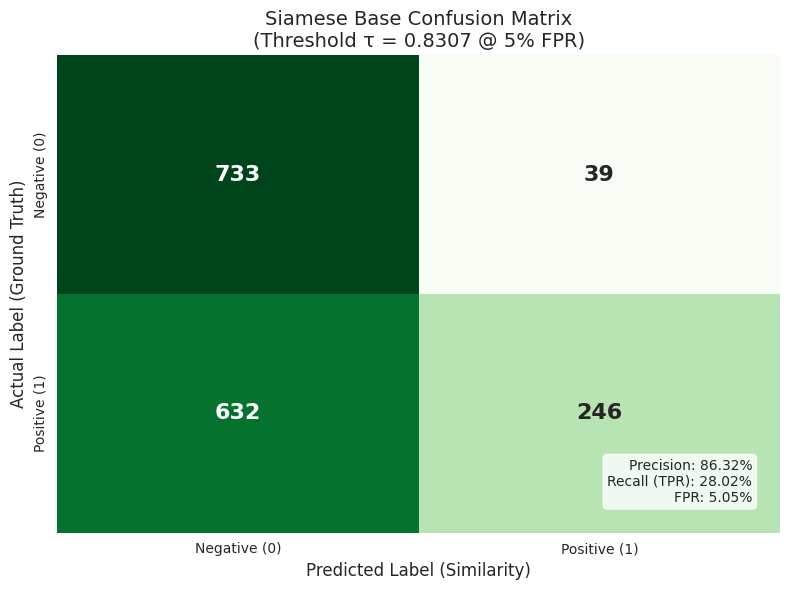

--- Siamese Base Confusion Matrix Stats ---
Threshold used: 0.8307
True Positives (Matches Found): 246
False Positives (False Alarms): 39
True Negatives (Correct Rejections): 733
False Negatives (Missed Matches): 632


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# --- 1. GLOBAL CONSTANTS ---
# Extracting the ground truth population from your Siamese test set
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
TARGET_FPR = 0.05

# --- 2. FIND THE OPERATING THRESHOLD ---
# We find the threshold (tau) where the Base Siamese model hits 5% Global Risk
fpr, tpr, thresholds = roc_curve(df_sia['true_label'], df_sia['prob_similarity'])
idx = np.argmin(np.abs(fpr - TARGET_FPR))
base_tau = thresholds[idx]

# --- 3. GENERATE PREDICTIONS & COUNTS ---
y_true = df_sia['true_label']
y_pred = (df_sia['prob_similarity'] >= base_tau).astype(int)

# Standard Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# --- 4. VISUALIZATION ---
plt.figure(figsize=(8, 6))
cm_data = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Greens', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})

plt.title(f"Siamese Base Confusion Matrix\n(Threshold \u03c4 = {base_tau:.4f} @ 5% FPR)", fontsize=14)
plt.xlabel('Predicted Label (Similarity)', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative (0)', 'Positive (1)'])
plt.yticks([0.5, 1.5], ['Negative (0)', 'Positive (1)'])

# Add helpful stats as a text box
stats_text = (f"Precision: {tp/(tp+fp):.2%}\n"
              f"Recall (TPR): {tp/TOTAL_POS_GLOBAL:.2%}\n"
              f"FPR: {fp/TOTAL_NEG_GLOBAL:.2%}")

plt.annotate(stats_text, xy=(1, 0), xycoords='axes fraction', fontsize=10,
             xytext=(-20, 20), textcoords='offset points',
             ha='right', va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --- 5. PRINT SUMMARY ---
print(f"--- Siamese Base Confusion Matrix Stats ---")
print(f"Threshold used: {base_tau:.4f}")
print(f"True Positives (Matches Found): {tp}")
print(f"False Positives (False Alarms): {fp}")
print(f"True Negatives (Correct Rejections): {tn}")
print(f"False Negatives (Missed Matches): {fn}")

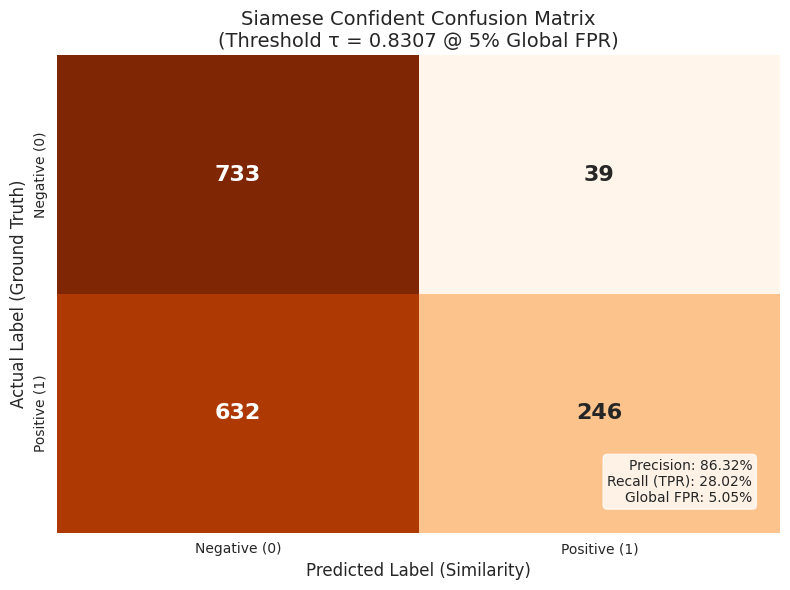

--- Siamese Confident Confusion Matrix Stats ---
Pairs analyzed: 1028 / 1650
Threshold used: 0.8307
TP: 246 | FP: 39 | TN: 733 | FN: 632


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# --- 1. GLOBAL BASELINE (From original Siamese test set) ---
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
TARGET_FPR = 0.05

# --- 2. DEFINE THE CONFIDENT SUBSET ---
CONF_LOW, CONF_HIGH = 0.4, 0.8
mask_conf = (df_sia['prob_similarity'] <= CONF_LOW) | (df_sia['prob_similarity'] >= CONF_HIGH)
df_conf = df_sia[mask_conf].copy()

# --- 3. FIND OPERATING THRESHOLD FOR SUBSET ---
# We find the threshold (tau) that makes the CONFIDENT SUBSET hit 5% GLOBAL FPR
fpr, tpr, thresholds = roc_curve(df_conf['true_label'], df_conf['prob_similarity'])
n_neg_subset = np.sum(df_conf['true_label'] == 0)

# Effective FPR = (FPR_subset * N_subset) / N_global
fpr_eff = (fpr * n_neg_subset) / TOTAL_NEG_GLOBAL
idx = np.argmin(np.abs(fpr_eff - TARGET_FPR))
conf_tau = thresholds[idx]

# --- 4. GENERATE PREDICTIONS & GLOBAL ACCOUNTING ---
y_true_sub = df_conf['true_label']
y_pred_sub = (df_conf['prob_similarity'] >= conf_tau).astype(int)

# Raw hits/misses in the subset
tp_sub = np.sum((y_pred_sub == 1) & (y_true_sub == 1))
fp_sub = np.sum((y_pred_sub == 1) & (y_true_sub == 0))

# Global Accounting:
# Any negative not called a '1' is a 'Safe' result (TN)
tn_global = int(TOTAL_NEG_GLOBAL - fp_sub)
# Any positive not called a '1' is a 'Missed' result (FN)
fn_global = int(TOTAL_POS_GLOBAL - tp_sub)
tp_global = int(tp_sub)
fp_global = int(fp_sub)

# --- 5. VISUALIZATION ---
plt.figure(figsize=(8, 6))
cm_data = np.array([[tn_global, fp_global], [fn_global, tp_global]])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Oranges', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})

plt.title(f"Siamese Confident Confusion Matrix\n(Threshold \u03c4 = {conf_tau:.4f} @ 5% Global FPR)", fontsize=14)
plt.xlabel('Predicted Label (Similarity)', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative (0)', 'Positive (1)'])
plt.yticks([0.5, 1.5], ['Negative (0)', 'Positive (1)'])

# Add metrics text box
stats_text = (f"Precision: {tp_global/(tp_global+fp_global):.2%}\n"
              f"Recall (TPR): {tp_global/TOTAL_POS_GLOBAL:.2%}\n"
              f"Global FPR: {fp_global/TOTAL_NEG_GLOBAL:.2%}")

plt.annotate(stats_text, xy=(1, 0), xycoords='axes fraction', fontsize=10,
             xytext=(-20, 20), textcoords='offset points',
             ha='right', va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"--- Siamese Confident Confusion Matrix Stats ---")
print(f"Pairs analyzed: {len(df_conf)} / {len(df_sia)}")
print(f"Threshold used: {conf_tau:.4f}")
print(f"TP: {tp_global} | FP: {fp_global} | TN: {tn_global} | FN: {fn_global}")

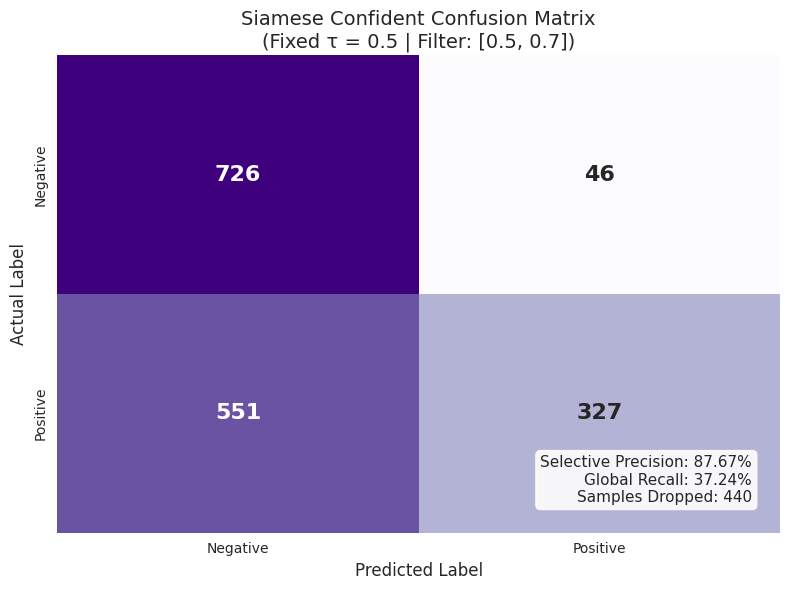

--- Stats Summary ---
TP: 327 | FP: 46 | TN: 726 | FN: 551
Precision: 0.8767 | Global Recall: 0.3724


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GLOBAL BASELINES (From original Siamese test set) ---
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
FIXED_TAU = 0.5

# --- 2. APPLY CONFIDENT FILTER ---
# Filtering for scores outside the [0.4, 0.8] range
mask_conf = (df_sia['prob_similarity'] <= 0.5) | (df_sia['prob_similarity'] >= 0.8)
df_conf = df_sia[mask_conf].copy()

# --- 3. CALCULATE METRICS AT FIXED 0.5 ---
y_true_sub = df_conf['true_label']
y_pred_sub = (df_conf['prob_similarity'] >= FIXED_TAU).astype(int)

# Raw hits/misses in the confident subset
tp_sub = int(np.sum((y_pred_sub == 1) & (y_true_sub == 1)))
fp_sub = int(np.sum((y_pred_sub == 1) & (y_true_sub == 0)))

# Global Accounting: 
# TN = Everything that wasn't a False Positive
tn_global = int(TOTAL_NEG_GLOBAL - fp_sub)
# FN = Everything that wasn't a True Positive
fn_global = int(TOTAL_POS_GLOBAL - tp_sub)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(8, 6))
cm_data = np.array([[tn_global, fp_sub], [fn_global, tp_sub]])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Purples', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})

plt.title(f"Siamese Confident Confusion Matrix\n(Fixed \u03c4 = 0.5 | Filter: [0.5, 0.7])", fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative', 'Positive'])
plt.yticks([0.5, 1.5], ['Negative', 'Positive'])

# Metrics
precision = tp_sub / (tp_sub + fp_sub) if (tp_sub + fp_sub) > 0 else 0
recall_global = tp_sub / TOTAL_POS_GLOBAL

stats_text = (f"Selective Precision: {precision:.2%}\n"
              f"Global Recall: {recall_global:.2%}\n"
              f"Samples Dropped: {len(df_sia) - len(df_conf)}")

plt.annotate(stats_text, xy=(1, 0), xycoords='axes fraction', fontsize=11,
             xytext=(-20, 20), textcoords='offset points',
             ha='right', va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.9))

plt.tight_layout()
plt.show()

print(f"--- Stats Summary ---")
print(f"TP: {tp_sub} | FP: {fp_sub} | TN: {tn_global} | FN: {fn_global}")
print(f"Precision: {precision:.4f} | Global Recall: {recall_global:.4f}")

In [7]:
import pandas as pd
import numpy as np

# --- 1. GLOBAL BASELINES ---
TOTAL_NEG_GLOBAL = np.sum(df_sia['true_label'] == 0)
TOTAL_POS_GLOBAL = np.sum(df_sia['true_label'] == 1)
FIXED_TAU = 0.5

# --- 2. APPLY CONFIDENT FILTER ---
# Rejection Region: (0.4, 0.8)
mask_conf = (df_sia['prob_similarity'] <= 0.4) | (df_sia['prob_similarity'] >= 0.7)
df_conf = df_sia[mask_conf].copy()

# --- 3. CALCULATE SELECTIVE COUNTS ---
y_true_sub = df_conf['true_label']
y_pred_sub = (df_conf['prob_similarity'] >= FIXED_TAU).astype(int)

# Subset Counts
tp_sub = int(np.sum((y_pred_sub == 1) & (y_true_sub == 1)))
fp_sub = int(np.sum((y_pred_sub == 1) & (y_true_sub == 0)))
tn_sub = int(np.sum((y_pred_sub == 0) & (y_true_sub == 0)))
fn_sub = int(np.sum((y_pred_sub == 0) & (y_true_sub == 1)))

# --- 4. CALCULATE SELECTIVE vs GLOBAL METRICS ---

# Selective Precision: TP / (TP + FP) within the subset
selective_precision = tp_sub / (tp_sub + fp_sub) if (tp_sub + fp_sub) > 0 else 0

# Selective FPR: FP / (FP + TN) within the subset
# This tells us the error rate on the data we kept
selective_fpr = fp_sub / (fp_sub + tn_sub) if (fp_sub + tn_sub) > 0 else 0

# Global Recall: TP_sub / Total_Pos_Global
# The discovery power relative to the entire dataset
global_recall = tp_sub / TOTAL_POS_GLOBAL

# --- 5. DISPLAY RESULTS ---
print(f"--- Selective Performance Metrics (Fixed \u03c4 = 0.5) ---")
print(f"Total Global Samples: {len(df_sia)}")
print(f"Confident Subset Size: {len(df_conf)} ({len(df_conf)/len(df_sia):.1%} Coverage)")
print("-" * 50)
print(f"TP (Subset): {tp_sub}")
print(f"FP (Subset): {fp_sub}")
print(f"TN (Subset): {tn_sub}")
print(f"FN (Subset): {fn_sub}")
print("-" * 50)
print(f"Selective Precision: {selective_precision:.2%}")
print(f"Selective FPR:       {selective_fpr:.2%}")
print(f"Global Recall:      {global_recall:.2%}")

--- Selective Performance Metrics (Fixed τ = 0.5) ---
Total Global Samples: 1650
Confident Subset Size: 1228 (74.4% Coverage)
--------------------------------------------------
TP (Subset): 447
FP (Subset): 89
TN (Subset): 514
FN (Subset): 178
--------------------------------------------------
Selective Precision: 83.40%
Selective FPR:       14.76%
Global Recall:      50.91%


## Compare confident models

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA LOADING ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/transport_model/phase1_test_predictions.csv"

df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)

# --- 2. DYNAMIC GLOBAL DENOMINATORS ---
TOTAL_NEG_GLOBAL = (df_sia['true_label'] == 0).sum()
TOTAL_POS_GLOBAL = (df_sia['true_label'] == 1).sum()

# --- 3. CONFIDENT ZONE PARAMETERS ---
CONF_LOW, CONF_HIGH = 0.4, 0.8
TAU = 0.5

In [9]:
def get_confident_cm_data(df, score_col):
    # Filter for the high-confidence zones
    mask = (df[score_col] <= CONF_LOW) | (df[score_col] >= CONF_HIGH)
    df_sub = df[mask].copy()
    
    y_true = df_sub['true_label']
    y_pred = (df_sub[score_col] >= TAU).astype(int)
    
    # Raw Counts in Subset
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    
    # Global accounting: 
    # TN = Global Negatives - False Positives in subset
    # FN = Global Positives - True Positives found in subset
    tn = TOTAL_NEG_GLOBAL - fp
    fn = TOTAL_POS_GLOBAL - tp
    
    # Metrics
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / TOTAL_POS_GLOBAL
    fpr = fp / TOTAL_NEG_GLOBAL
    
    return np.array([[tn, fp], [fn, tp]]), prec, recall, fpr

In [10]:
# Calculate for both
cm_ice, prec_ice, rec_ice, fpr_ice = get_confident_cm_data(df_ice, 'cosine_similarity')
cm_sia, prec_sia, rec_sia, fpr_sia = get_confident_cm_data(df_sia, 'prob_similarity')

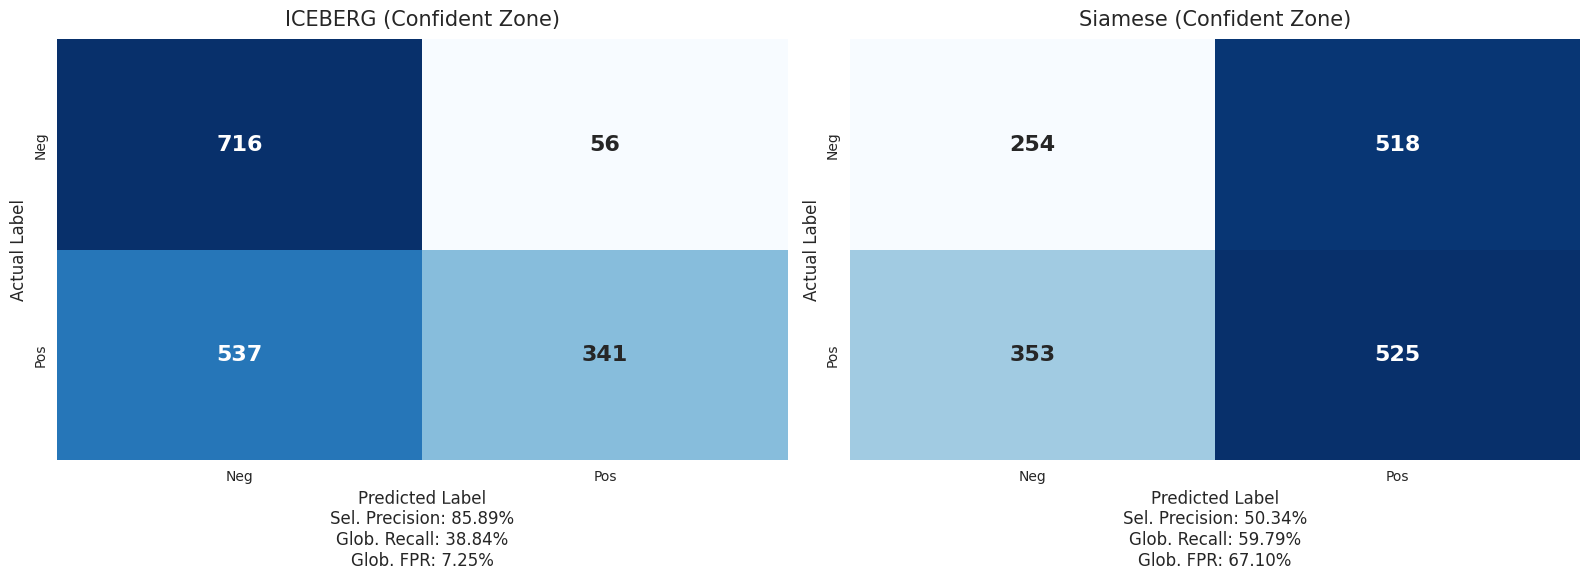

In [11]:
# --- 4. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_cm(cm, ax, title, prec, rec, fpr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 16, "weight": "bold"})
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('Actual Label', fontsize=12)
    ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticklabels(['Neg', 'Pos'])
    
    # Text box for summary metrics
    stats = f"Sel. Precision: {prec:.2%}\nGlob. Recall: {rec:.2%}\nGlob. FPR: {fpr:.2%}"
    ax.text(0.5, -0.25, stats, ha='center', transform=ax.transAxes, 
            fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plot_cm(cm_ice, axes[0], "ICEBERG (Confident Zone)", prec_ice, rec_ice, fpr_ice)
plot_cm(cm_sia, axes[1], "Siamese (Confident Zone)", prec_sia, rec_sia, fpr_sia)

plt.tight_layout()
plt.show()

In [12]:
# --- 5. TEXT SUMMARY ---
print(f"{'Metric':<20} | {'ICEBERG':<12} | {'Siamese':<12}")
print("-" * 50)
print(f"{'TP (Matches Found)':<20} | {cm_ice[1,1]:<12} | {cm_sia[1,1]:<12}")
print(f"{'FP (False Alarms)':<20} | {cm_ice[0,1]:<12} | {cm_sia[0,1]:<12}")
print(f"{'Selective Precision':<20} | {prec_ice:<12.4f} | {prec_sia:<12.4f}")
print(f"{'Global Recall':<20} | {rec_ice:<12.4f} | {rec_sia:<12.4f}")
print(f"{'Global FPR':<20} | {fpr_ice:<12.4f} | {fpr_sia:<12.4f}")

Metric               | ICEBERG      | Siamese     
--------------------------------------------------
TP (Matches Found)   | 341          | 525         
FP (False Alarms)    | 56           | 518         
Selective Precision  | 0.8589       | 0.5034      
Global Recall        | 0.3884       | 0.5979      
Global FPR           | 0.0725       | 0.6710      


## Compare confident models on constant global risk

--- Global Parameters ---
Total Negatives (N): 772
Total Positives (P): 878
5% Error Budget: 38 False Positives allowed



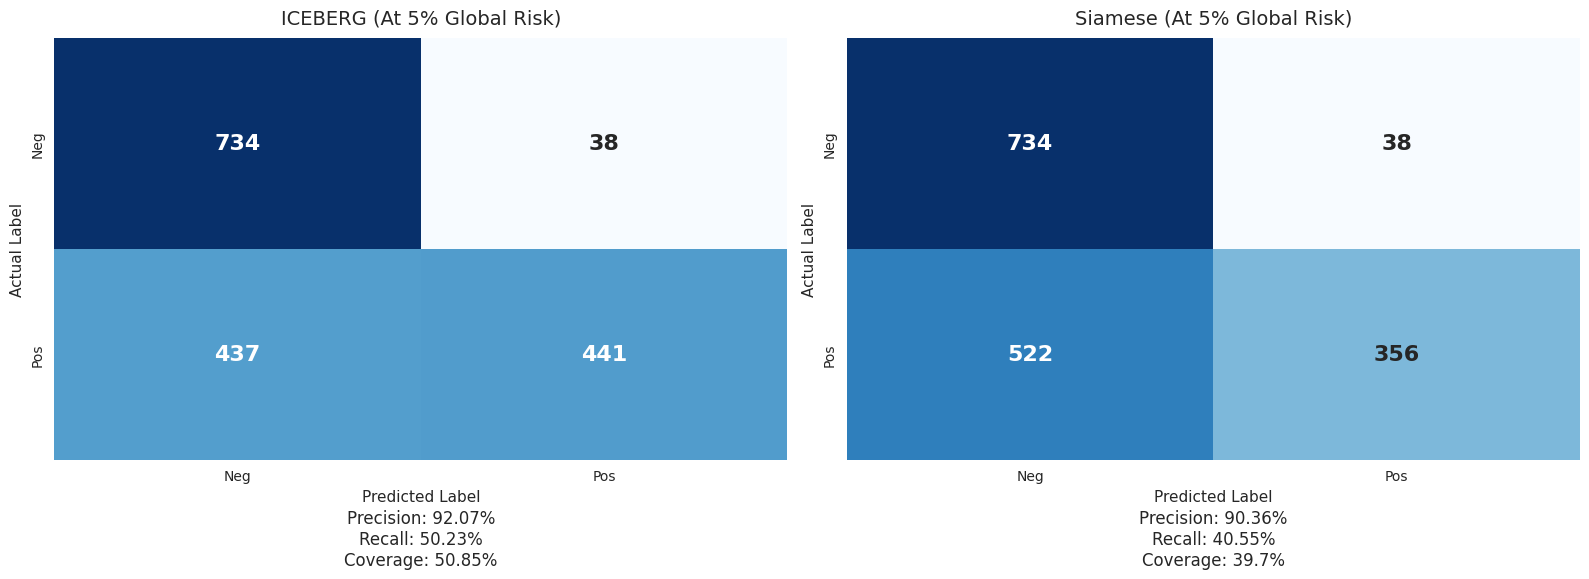

--- FAIR COMPARISON SUMMARY TABLE ---
  Model  Pairs Retained  Coverage (%)  TP (Yield)  FP (Fixed)  TN  FN  Precision  Global Recall
ICEBERG             839         50.85         441          38 734 437     0.9207         0.5023
Siamese             655         39.70         356          38 734 522     0.9036         0.4055


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD DATA ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/siamese_test_predictions.csv"
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)

# --- 2. DYNAMIC GLOBAL BASELINES ---
TOTAL_NEG_GLOBAL = (df_sia['true_label'] == 0).sum()
TOTAL_POS_GLOBAL = (df_sia['true_label'] == 1).sum()
TARGET_FPR = 0.05
# Calculate the exact number of errors allowed
ERROR_BUDGET = int(TOTAL_NEG_GLOBAL * TARGET_FPR) 

print(f"--- Global Parameters ---")
print(f"Total Negatives (N): {TOTAL_NEG_GLOBAL}")
print(f"Total Positives (P): {TOTAL_POS_GLOBAL}")
print(f"5% Error Budget: {ERROR_BUDGET} False Positives allowed\n")

# --- 3. FAIR COMPARISON FUNCTION ---
def get_constant_risk_metrics(df, score_col, name):
    # A. Calculate Confidence (distance from the 0.5 decision boundary)
    df['confidence'] = np.abs(df[score_col] - 0.5)
    
    # B. Sort by most confident first
    df_sorted = df.sort_values('confidence', ascending=False).copy()
    
    # C. Track errors as we expand coverage
    # A False Positive occurs if the model predicts 1 (score >= 0.5) but label is 0
    df_sorted['is_fp'] = ((df_sorted[score_col] >= 0.5) & (df_sorted['true_label'] == 0)).astype(int)
    df_sorted['cum_fp'] = df_sorted['is_fp'].cumsum()
    
    # D. Find the cutoff where we hit our budget of ~38 errors
    # We keep all samples until the cumulative FP count exceeds our budget
    fair_subset = df_sorted[df_sorted['cum_fp'] <= ERROR_BUDGET].copy()
    
    # E. Calculate Metrics for the Fair Subset
    tp = (fair_subset['true_label'] == 1).sum()
    fp = fair_subset['is_fp'].sum()
    tn = TOTAL_NEG_GLOBAL - fp
    fn = TOTAL_POS_GLOBAL - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / TOTAL_POS_GLOBAL
    coverage = len(fair_subset) / (TOTAL_NEG_GLOBAL + TOTAL_POS_GLOBAL)
    
    return {
        "Model": name,
        "Pairs Retained": len(fair_subset),
        "Coverage (%)": round(coverage * 100, 2),
        "TP (Yield)": int(tp),
        "FP (Fixed)": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "Precision": round(precision, 4),
        "Global Recall": round(recall, 4)
    }, np.array([[tn, fp], [fn, tp]])

# --- 4. EXECUTE COMPARISON ---
res_ice, cm_ice = get_constant_risk_metrics(df_ice, 'cosine_similarity', "ICEBERG")
res_sia, cm_sia = get_constant_risk_metrics(df_sia, 'prob_similarity', "Siamese")

df_results = pd.DataFrame([res_ice, res_sia])

# --- 5. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_styled_cm(cm, ax, title, metrics):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 16, "weight": "bold"})
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)
    ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticklabels(['Neg', 'Pos'])
    
    stats = (f"Precision: {metrics['Precision']:.2%}\n"
             f"Recall: {metrics['Global Recall']:.2%}\n"
             f"Coverage: {metrics['Coverage (%)']}%")
    
    ax.text(0.5, -0.25, stats, ha='center', transform=ax.transAxes, 
            fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plot_styled_cm(cm_ice, axes[0], "ICEBERG (At 5% Global Risk)", res_ice)
plot_styled_cm(cm_sia, axes[1], "Siamese (At 5% Global Risk)", res_sia)

plt.tight_layout()
plt.show()

print("--- FAIR COMPARISON SUMMARY TABLE ---")
print(df_results.to_string(index=False))

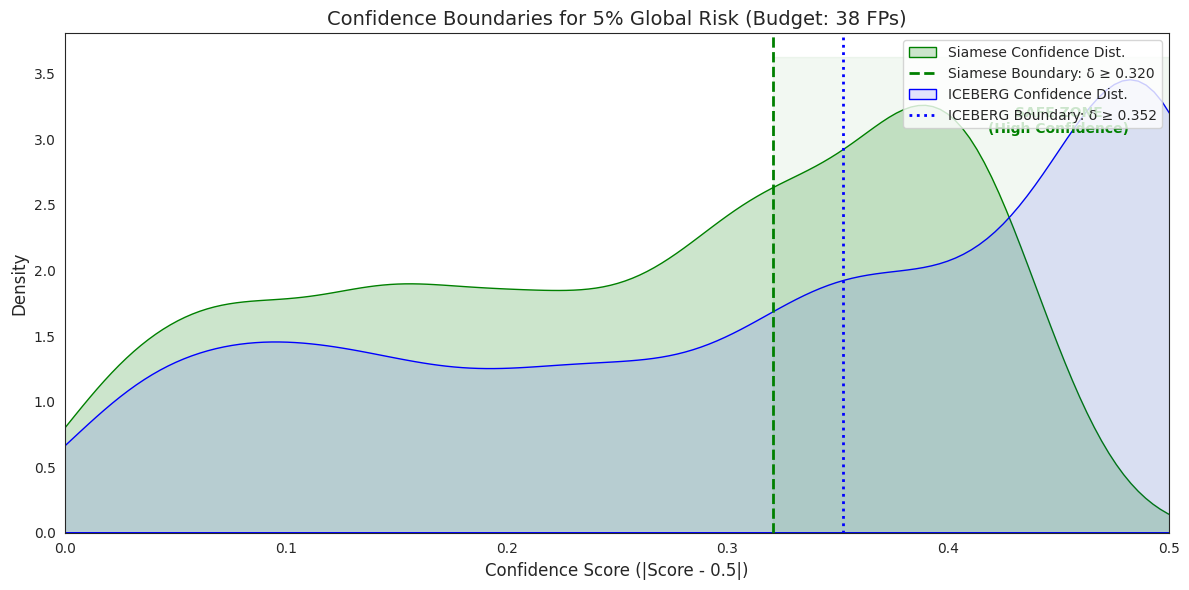

To maintain 5% Global Risk:
ICEBERG must reject all samples with confidence < 0.3522
Siamese must reject all samples with confidence < 0.3204


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SETUP & ERROR BUDGET ---
TOTAL_NEG_GLOBAL = (df_sia['true_label'] == 0).sum()
ERROR_BUDGET = int(TOTAL_NEG_GLOBAL * 0.05) 

def get_boundary_data(df, score_col):
    # Confidence = Distance from 0.5 boundary
    df['confidence'] = np.abs(df[score_col] - 0.5)
    df_sorted = df.sort_values('confidence', ascending=False).copy()
    
    # Identify False Positives (Score >= 0.5 but Label == 0)
    df_sorted['is_fp'] = ((df_sorted[score_col] >= 0.5) & (df_sorted['true_label'] == 0)).astype(int)
    df_sorted['cum_fp'] = df_sorted['is_fp'].cumsum()
    
    # Find the confidence value at the budget cutoff
    cutoff_row = df_sorted[df_sorted['cum_fp'] <= ERROR_BUDGET].iloc[-1]
    boundary_val = cutoff_row['confidence']
    
    return df['confidence'], boundary_val

# Calculate boundaries
conf_ice, boundary_ice = get_boundary_data(df_ice, 'cosine_similarity')
conf_sia, boundary_sia = get_boundary_data(df_sia, 'prob_similarity')

# --- 2. PLOTTING ---
plt.figure(figsize=(12, 6))
sns.set_style("white")

# Plot Siamese Confidence Distribution
sns.kdeplot(conf_sia, label='Siamese Confidence Dist.', color='green', fill=True, alpha=0.2)
plt.axvline(boundary_sia, color='green', linestyle='--', lw=2, 
            label=f'Siamese Boundary: \u03b4 \u2265 {boundary_sia:.3f}')

# Plot ICEBERG Confidence Distribution
sns.kdeplot(conf_ice, label='ICEBERG Confidence Dist.', color='blue', fill=True, alpha=0.1)
plt.axvline(boundary_ice, color='blue', linestyle=':', lw=2, 
            label=f'ICEBERG Boundary: \u03b4 \u2265 {boundary_ice:.3f}')

# Formatting
plt.title(f'Confidence Boundaries for 5% Global Risk (Budget: {ERROR_BUDGET} FPs)', fontsize=14)
plt.xlabel('Confidence Score (|Score - 0.5|)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)

# Annotate the "Safe Zone"
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], boundary_sia, 0.5, color='green', alpha=0.05)
plt.text(0.45, plt.gca().get_ylim()[1]*0.8, "SAFE ZONE\n(High Confidence)", 
         ha='center', color='green', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print(f"To maintain 5% Global Risk:")
print(f"ICEBERG must reject all samples with confidence < {boundary_ice:.4f}")
print(f"Siamese must reject all samples with confidence < {boundary_sia:.4f}")

Global Population: N=772, P=878
5% FPR Budget: 38 allowed False Positives



/tmp/ipykernel_2703805/3408397826.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='Model', y='Global Recall', palette=['blue', 'green'], alpha=0.8)


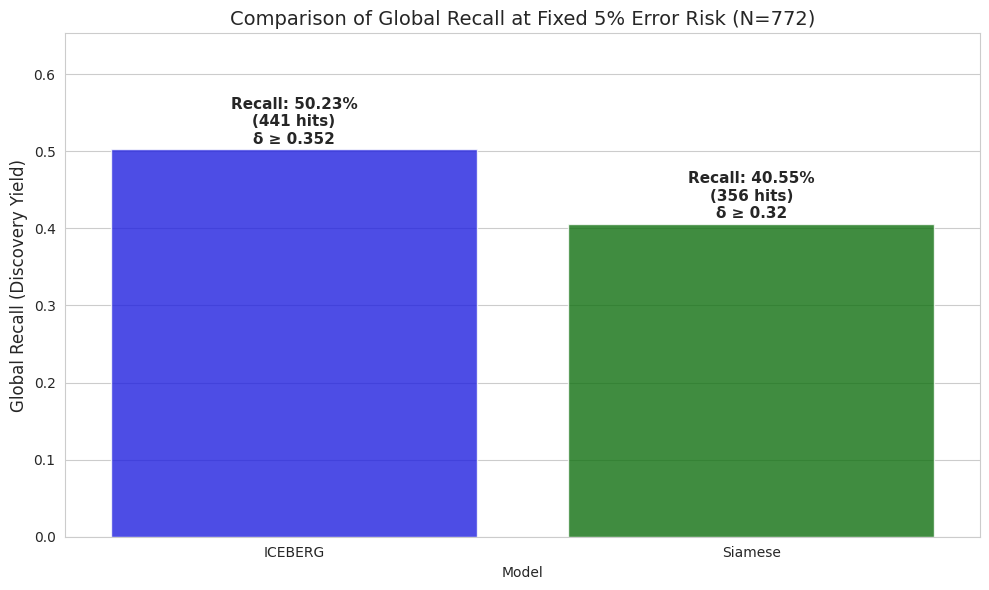

  Model  Global Recall  TP Found  Confidence Boundary (δ)
ICEBERG         0.5023       441                    0.352
Siamese         0.4055       356                    0.320


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/siamese_test_predictions.csv"

TARGET_FPR = 0.05

# --- 2. LOAD DATA ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)

# --- 3. DYNAMIC GLOBAL BASES ---
# Baseline population derived from the Siamese test set
TOTAL_NEG_GLOBAL = (df_sia['true_label'] == 0).sum()
TOTAL_POS_GLOBAL = (df_sia['true_label'] == 1).sum()
ERROR_BUDGET = int(TOTAL_NEG_GLOBAL * TARGET_FPR)

print(f"Global Population: N={TOTAL_NEG_GLOBAL}, P={TOTAL_POS_GLOBAL}")
print(f"5% FPR Budget: {ERROR_BUDGET} allowed False Positives\n")

# --- 4. FAIR RECALL CALCULATION ---
def get_recall_at_budget(df, score_col, name):
    # Confidence = Distance from decision boundary (0.5)
    df['confidence'] = np.abs(df[score_col] - 0.5)
    
    # Sort by descending confidence (most certain first)
    df_sorted = df.sort_values('confidence', ascending=False).copy()
    
    # Track errors (FP) as we expand the confidence zone
    # A FP is defined as predicting 1 (>=0.5) when the truth is 0
    df_sorted['is_fp'] = ((df_sorted[score_col] >= 0.5) & (df_sorted['true_label'] == 0)).astype(int)
    df_sorted['cum_fp'] = df_sorted['is_fp'].cumsum()
    
    # Find the largest subset that fits in the budget
    fair_subset = df_sorted[df_sorted['cum_fp'] <= ERROR_BUDGET]
    
    # Discovery yield
    tp = (fair_subset['true_label'] == 1).sum()
    global_recall = tp / TOTAL_POS_GLOBAL
    
    # Identify the boundary confidence
    boundary = fair_subset['confidence'].min() if len(fair_subset) > 0 else 0.5
    
    return {
        "Model": name,
        "Global Recall": round(global_recall, 4),
        "TP Found": int(tp),
        "Confidence Boundary (\u03b4)": round(boundary, 3)
    }

# Calculate metrics
res_ice = get_recall_at_budget(df_ice, 'cosine_similarity', "ICEBERG")
res_sia = get_recall_at_budget(df_sia, 'prob_similarity', "Siamese")

df_plot = pd.DataFrame([res_ice, res_sia])

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create Bar Plot
ax = sns.barplot(data=df_plot, x='Model', y='Global Recall', palette=['blue', 'green'], alpha=0.8)

# Add annotations
for i, p in enumerate(ax.patches):
    recall = df_plot.iloc[i]['Global Recall']
    tp = df_plot.iloc[i]['TP Found']
    boundary = df_plot.iloc[i]['Confidence Boundary (\u03b4)']
    
    ax.annotate(f"Recall: {recall:.2%}\n({tp} hits)\n\u03b4 \u2265 {boundary}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 20), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.ylim(0, max(df_plot['Global Recall']) * 1.3)
plt.title(f'Comparison of Global Recall at Fixed 5% Error Risk (N={TOTAL_NEG_GLOBAL})', fontsize=14)
plt.ylabel('Global Recall (Discovery Yield)', fontsize=12)
plt.tight_layout()

plt.show()

print(df_plot.to_string(index=False))

## Analyzing confident models in honest zone

--- Honest Zone Parameters (1-100 Da) ---
Negatives in Zone: 487
Positives in Zone: 614
5% Error Budget for Zone: 24 False Positives allowed



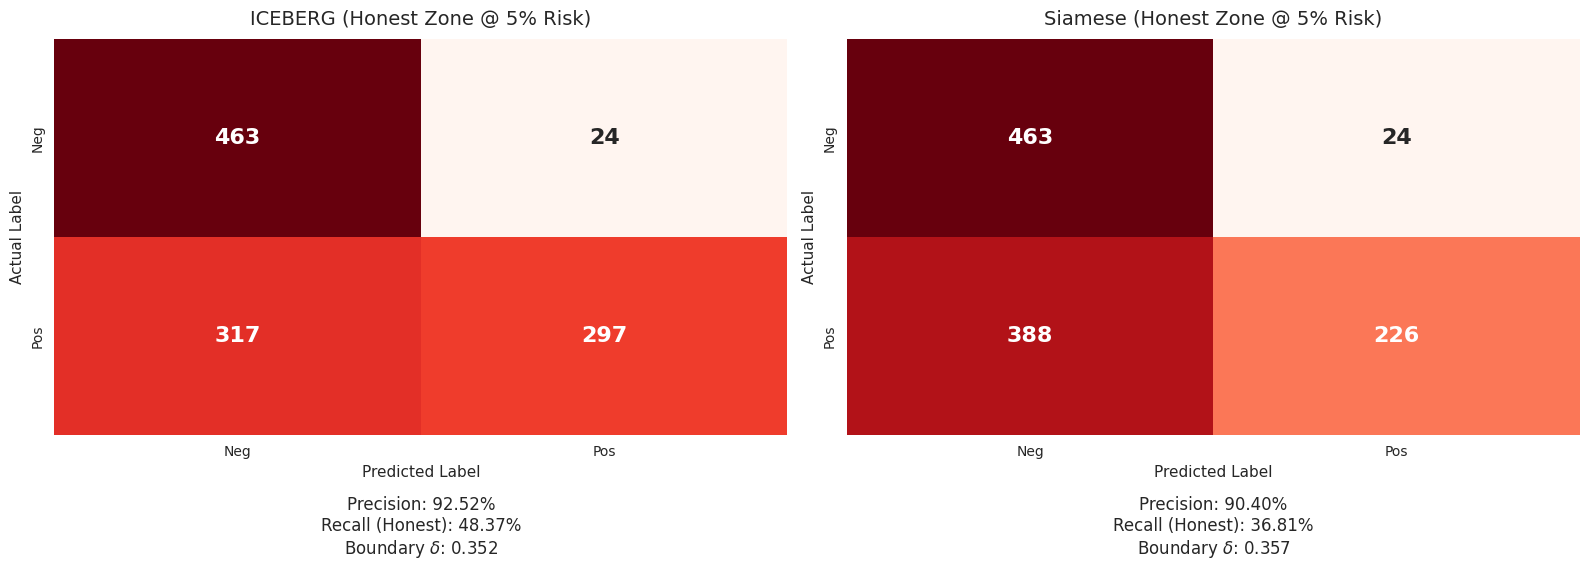

--- HONEST ZONE FAIR COMPARISON SUMMARY ---
  Model  Pairs Retained  Coverage (%)  TP (Yield)  FP (Fixed)  Precision  Recall (Honest)  Conf_Boundary_Delta
ICEBERG             532         48.32         297          24     0.9252           0.4837                0.352
Siamese             356         32.33         226          24     0.9040           0.3681                0.357


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION & DATA LOADING ---
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/siamese_test_predictions.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# --- 2. ENRICHMENT & HONEST ZONE FILTERING ---
def filter_honest_zone(df, meta):
    # Map m/z values to the pairs
    df['mz_main'] = df['name_main'].map(meta['prec_mz'])
    df['mz_sub'] = df['name_sub'].map(meta['prec_mz'])
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    # Filter for the Honest Zone (1.0 - 100.0 Da)
    mask = (df['mass_diff'] >= 1.0) & (df['mass_diff'] < 100.0)
    return df[mask].copy()

df_ice_h = filter_honest_zone(df_ice, spec_df)
df_sia_h = filter_honest_zone(df_sia, spec_df)

# --- 3. DYNAMIC HONEST ZONE BASELINES ---
TOTAL_NEG_H = (df_sia_h['true_label'] == 0).sum()
TOTAL_POS_H = (df_sia_h['true_label'] == 1).sum()
TARGET_FPR = 0.05
# Budget: 5% of the negatives in the Honest Zone
ERROR_BUDGET = int(TOTAL_NEG_H * TARGET_FPR) 

print(f"--- Honest Zone Parameters (1-100 Da) ---")
print(f"Negatives in Zone: {TOTAL_NEG_H}")
print(f"Positives in Zone: {TOTAL_POS_H}")
print(f"5% Error Budget for Zone: {ERROR_BUDGET} False Positives allowed\n")

# --- 4. FAIR COMPARISON FUNCTION ---
def get_constant_risk_metrics(df, score_col, name, total_pos, total_neg):
    # A. Calculate Confidence
    df['confidence'] = np.abs(df[score_col] - 0.5)
    
    # B. Sort by most confident first
    df_sorted = df.sort_values('confidence', ascending=False).copy()
    
    # C. Track errors
    df_sorted['is_fp'] = ((df_sorted[score_col] >= 0.5) & (df_sorted['true_label'] == 0)).astype(int)
    df_sorted['cum_fp'] = df_sorted['is_fp'].cumsum()
    
    # D. Cutoff at budget
    fair_subset = df_sorted[df_sorted['cum_fp'] <= ERROR_BUDGET].copy()
    
    # E. Metrics
    tp = (fair_subset['true_label'] == 1).sum()
    fp = fair_subset['is_fp'].sum()
    tn = total_neg - fp
    fn = total_pos - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_pos
    coverage = len(fair_subset) / (total_pos + total_neg)
    
    # Renamed key to avoid backslash issues in f-strings
    boundary = fair_subset['confidence'].min() if len(fair_subset) > 0 else 0.5

    return {
        "Model": name,
        "Pairs Retained": len(fair_subset),
        "Coverage (%)": round(coverage * 100, 2),
        "TP (Yield)": int(tp),
        "FP (Fixed)": int(fp),
        "Precision": round(precision, 4),
        "Recall (Honest)": round(recall, 4),
        "Conf_Boundary_Delta": round(boundary, 4)
    }, np.array([[tn, fp], [fn, tp]])

# --- 5. EXECUTE ---
res_ice, cm_ice = get_constant_risk_metrics(df_ice_h, 'cosine_similarity', "ICEBERG", TOTAL_POS_H, TOTAL_NEG_H)
res_sia, cm_sia = get_constant_risk_metrics(df_sia_h, 'prob_similarity', "Siamese", TOTAL_POS_H, TOTAL_NEG_H)

df_results = pd.DataFrame([res_ice, res_sia])

# --- 6. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_styled_cm(cm, ax, title, metrics):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax, cbar=False,
                annot_kws={"size": 16, "weight": "bold"})
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)
    ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticklabels(['Neg', 'Pos'])
    
    # Format metrics separately to avoid f-string syntax errors
    p_val = "{:.2%}".format(metrics['Precision'])
    r_val = "{:.2%}".format(metrics['Recall (Honest)'])
    d_val = metrics['Conf_Boundary_Delta']
    
    stats = f"Precision: {p_val}\nRecall (Honest): {r_val}\nBoundary $\delta$: {d_val}"
    
    ax.text(0.5, -0.3, stats, ha='center', transform=ax.transAxes, 
            fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plot_styled_cm(cm_ice, axes[0], "ICEBERG (Honest Zone @ 5% Risk)", res_ice)
plot_styled_cm(cm_sia, axes[1], "Siamese (Honest Zone @ 5% Risk)", res_sia)

plt.tight_layout()
plt.savefig('honest_zone_comparison.png')
plt.show()

print("--- HONEST ZONE FAIR COMPARISON SUMMARY ---")
print(df_results.to_string(index=False))

[*] Loading predictions from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv


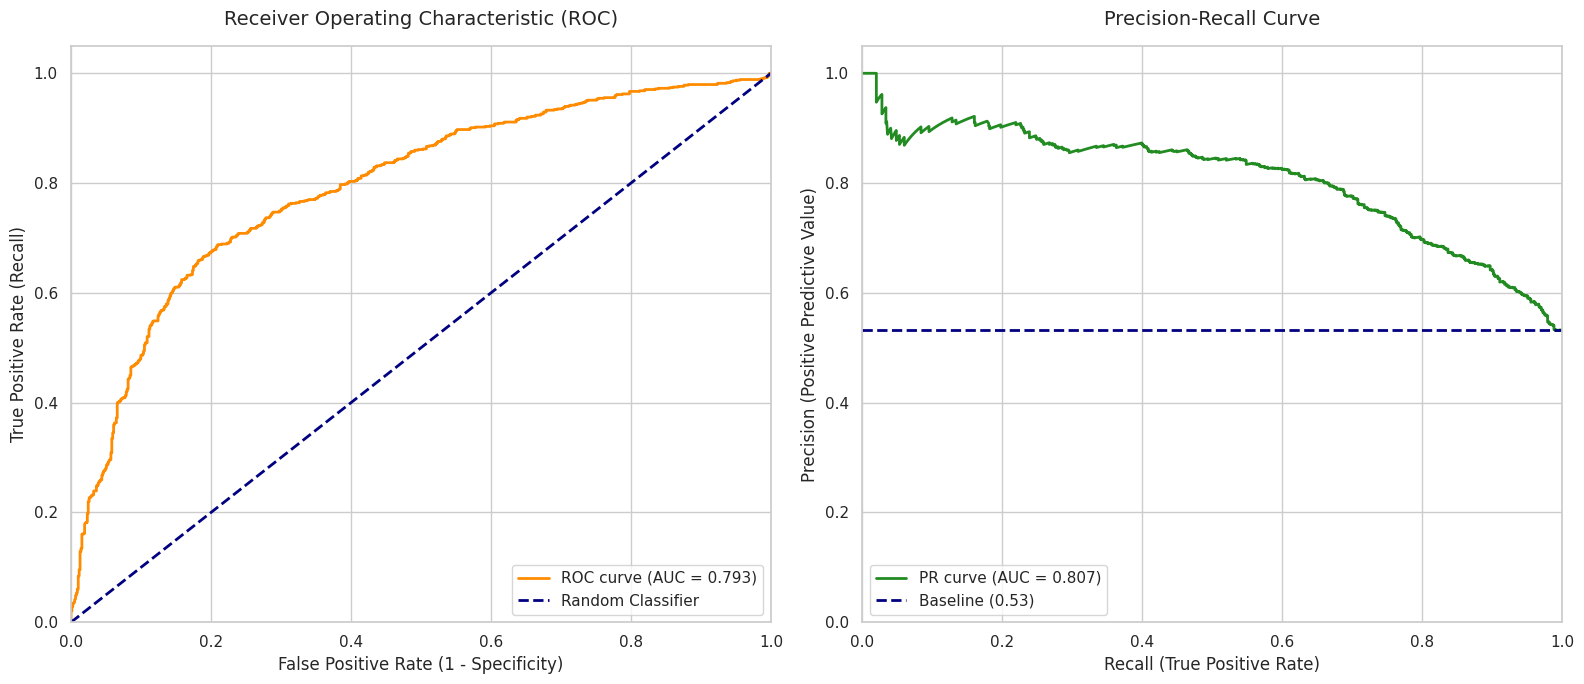

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# Path to your latest predictions CSV
csv_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"
# csv_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/siamese_test_predictions.csv"

# Load the data
print(f"[*] Loading predictions from: {csv_path}")
df = pd.read_csv(csv_path)

y_true = df['true_label']
y_prob = df['prob_similarity']

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ==========================================
# 1. Receiver Operating Characteristic (ROC)
# ==========================================
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
axes[0].legend(loc="lower right", fontsize=11)

# ==========================================
# 2. Precision-Recall (PR) Curve
# ==========================================
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

# Calculate baseline (ratio of positive samples in the dataset)
baseline = len(y_true[y_true == 1]) / len(y_true)

axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, pad=15)
axes[1].legend(loc="lower left", fontsize=11)

# Render the plots inline
plt.tight_layout()
plt.show()

[*] Loading ICEBERG predictions from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv


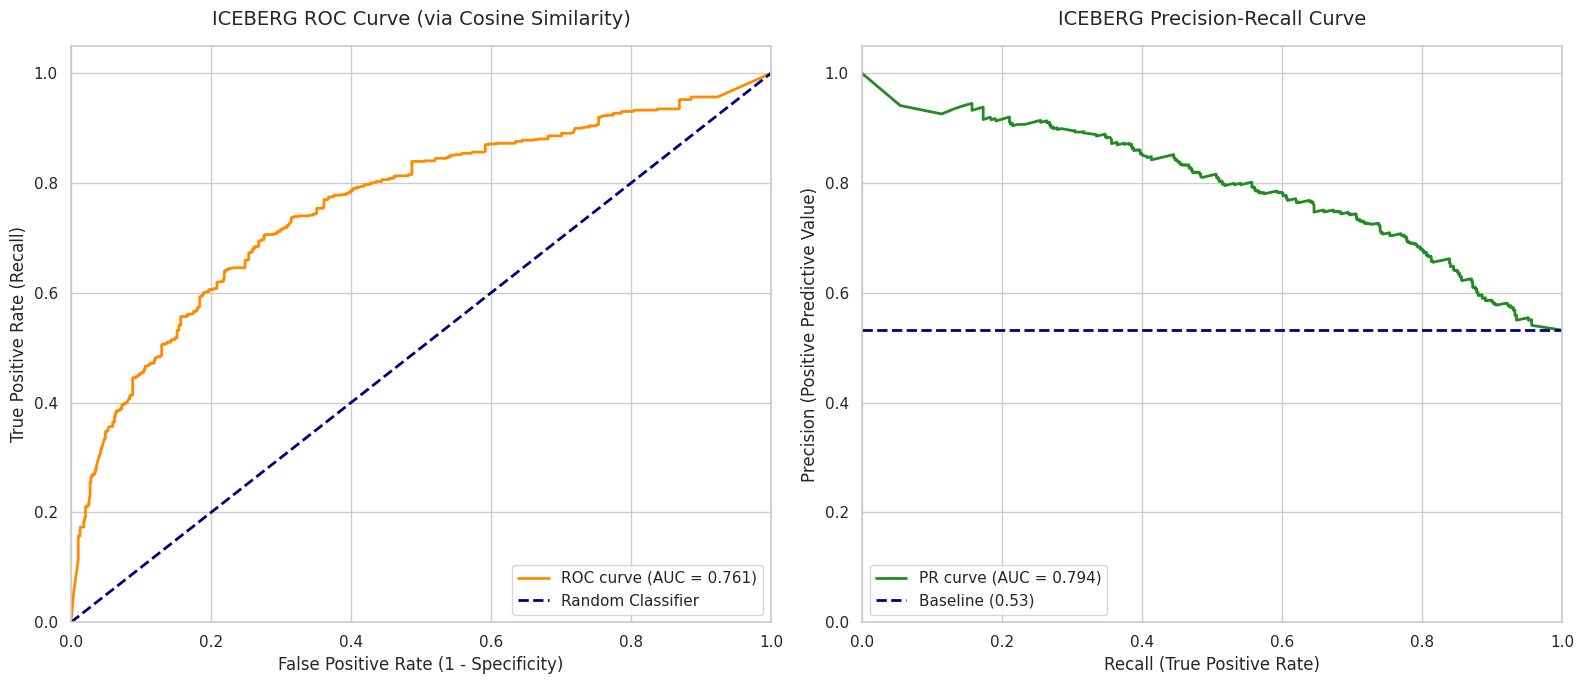

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# --- UPDATE THIS PATH TO YOUR ACTUAL ICEBERG CSV FILE ---
csv_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv" 

# Load the data
print(f"[*] Loading ICEBERG predictions from: {csv_path}")
df = pd.read_csv(csv_path)

# IMPORTANT: Using 'cosine_similarity' as the continuous score for the curves
y_true = df['true_label']
y_score = df['cosine_similarity'] 

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ==========================================
# 1. Receiver Operating Characteristic (ROC)
# ==========================================
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ICEBERG ROC Curve (via Cosine Similarity)', fontsize=14, pad=15)
axes[0].legend(loc="lower right", fontsize=11)

# ==========================================
# 2. Precision-Recall (PR) Curve
# ==========================================
precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

# Calculate baseline (ratio of positive samples in the dataset)
baseline = len(y_true[y_true == 1.0]) / len(y_true)

axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].set_title('ICEBERG Precision-Recall Curve', fontsize=14, pad=15)
axes[1].legend(loc="lower left", fontsize=11)

# Render the plots inline
plt.tight_layout()
plt.show()